In [1]:
# ============================================================
# CELL 1 — EXPERIMENT 6: SETUP
# RNN vs LSTM vs GRU
# ============================================================

import os
import gc
import time
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Google Colab paths
# ------------------------------------------------------------

BASE_DIR = Path("/content/experiment6")

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"
CACHE_DIR = BASE_DIR / "cache"

for directory in [
    BASE_DIR,
    DATA_DIR,
    OUTPUT_DIR,
    MODEL_DIR,
    CACHE_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold"
})

# ------------------------------------------------------------
# GPU check
# ------------------------------------------------------------

print("=" * 60)
print("EXPERIMENT 6 — SETUP")
print("=" * 60)

print("\nTensorFlow version:")
print(tf.__version__)

print("\nGPU devices:")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        print(" ", gpu)
    print("\nGPU is available.")
else:
    print(" No GPU detected.")
    print("The notebook can still run, but training will be slower.")

print("\nDirectories:")
print("BASE_DIR   :", BASE_DIR)
print("DATA_DIR   :", DATA_DIR)
print("OUTPUT_DIR :", OUTPUT_DIR)
print("MODEL_DIR  :", MODEL_DIR)
print("CACHE_DIR  :", CACHE_DIR)

print("\nSetup completed successfully.")

EXPERIMENT 6 — SETUP

TensorFlow version:
2.20.0

GPU devices:
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU is available.

Directories:
BASE_DIR   : /content/experiment6
DATA_DIR   : /content/experiment6/data
OUTPUT_DIR : /content/experiment6/outputs
MODEL_DIR  : /content/experiment6/models
CACHE_DIR  : /content/experiment6/cache

Setup completed successfully.


In [2]:
# ============================================================
# CELL 2 — DOWNLOAD UCI HAR DATASET
# ============================================================

import requests
from pathlib import Path

# Official UCI Dataset 240
UCI_URL = (
    "https://archive.ics.uci.edu/static/public/240/"
    "human+activity+recognition+using+smartphones.zip"
)

UCI_ZIP = DATA_DIR / "uci_har.zip"

print("=" * 60)
print("DOWNLOADING UCI HAR DATASET")
print("=" * 60)

print("\nDownload URL:")
print(UCI_URL)

# ------------------------------------------------------------
# Download
# ------------------------------------------------------------

response = requests.get(
    UCI_URL,
    stream=True,
    timeout=120
)

response.raise_for_status()

total_size = int(
    response.headers.get("content-length", 0)
)

print("\nExpected download size:",
      f"{total_size / (1024**2):.2f} MB")

downloaded = 0

with open(UCI_ZIP, "wb") as f:

    for chunk in response.iter_content(
        chunk_size=1024 * 1024
    ):

        if chunk:

            f.write(chunk)
            downloaded += len(chunk)

            if total_size:
                percent = (
                    downloaded / total_size
                ) * 100

                print(
                    f"\rDownloaded: "
                    f"{downloaded / (1024**2):.2f} MB "
                    f"({percent:.1f}%)",
                    end=""
                )

print("\n")

# ------------------------------------------------------------
# Verify downloaded file
# ------------------------------------------------------------

if not UCI_ZIP.exists():
    raise RuntimeError(
        "Dataset download failed: ZIP file not found."
    )

file_size_mb = (
    UCI_ZIP.stat().st_size / (1024**2)
)

print("Downloaded file:")
print(UCI_ZIP)

print(
    f"\nActual file size: {file_size_mb:.2f} MB"
)

# ------------------------------------------------------------
# Basic size sanity check
# ------------------------------------------------------------

if file_size_mb < 10:
    raise RuntimeError(
        "Downloaded file is unexpectedly small. "
        "The UCI dataset was probably not downloaded correctly."
    )

print("\nDownload completed successfully.")

DOWNLOADING UCI HAR DATASET

Download URL:
https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip

Expected download size: 0.00 MB


Downloaded file:
/content/experiment6/data/uci_har.zip

Actual file size: 58.18 MB

Download completed successfully.


In [3]:
# ============================================================
# CELL 4 — EXTRACT OUTER ZIP AND INSPECT INNER ZIP
# ============================================================

import zipfile
import shutil
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

OUTER_EXTRACT = DATA_DIR / "outer_extracted"
INNER_ZIP = OUTER_EXTRACT / "UCI HAR Dataset.zip"

# Start clean
if OUTER_EXTRACT.exists():
    shutil.rmtree(OUTER_EXTRACT)

OUTER_EXTRACT.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 60)
print("EXTRACTING OUTER ZIP")
print("=" * 60)

# ------------------------------------------------------------
# Extract outer ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(UCI_ZIP, "r") as z:
    z.extractall(OUTER_EXTRACT)

print("\nOuter ZIP extracted to:")
print(OUTER_EXTRACT)

# ------------------------------------------------------------
# Check extracted files
# ------------------------------------------------------------

print("\nFiles extracted from outer ZIP:")

for item in OUTER_EXTRACT.iterdir():
    print(" ", item)

# ------------------------------------------------------------
# Verify inner ZIP
# ------------------------------------------------------------

if not INNER_ZIP.exists():
    raise RuntimeError(
        "Could not find the inner 'UCI HAR Dataset.zip'."
    )

print("\nInner ZIP found:")
print(INNER_ZIP)

print(
    f"Inner ZIP size: "
    f"{INNER_ZIP.stat().st_size / (1024**2):.2f} MB"
)

# ------------------------------------------------------------
# Verify inner ZIP
# ------------------------------------------------------------

if not zipfile.is_zipfile(INNER_ZIP):
    raise RuntimeError(
        "The inner UCI HAR Dataset.zip is not a valid ZIP."
    )

print("\nInner ZIP verification: PASSED")

# ------------------------------------------------------------
# Inspect inner ZIP contents
# ------------------------------------------------------------

with zipfile.ZipFile(INNER_ZIP, "r") as z:

    inner_files = z.namelist()

    print(
        "\nNumber of entries in inner ZIP:",
        len(inner_files)
    )

    print("\nFirst 30 entries of INNER ZIP:")

    for f in inner_files[:30]:
        print(" ", f)

# ------------------------------------------------------------
# Search for raw signal file
# ------------------------------------------------------------

matches = [
    f for f in inner_files
    if f.endswith("body_acc_x_train.txt")
]

print("\n" + "-" * 60)
print("SEARCHING FOR RAW INERTIAL SIGNAL FILE")
print("-" * 60)

if matches:

    print("\nSUCCESS! Found:")
    for f in matches:
        print(" ", f)

else:

    print(
        "\nbody_acc_x_train.txt was NOT found "
        "inside the inner ZIP."
    )

    print("\nEntries containing 'Inertial Signals':")

    for f in inner_files:
        if "Inertial Signals" in f:
            print(" ", f)

    raise RuntimeError(
        "Raw inertial signal files are missing "
        "from the inner ZIP."
    )

print("\n" + "=" * 60)
print("INNER ZIP INSPECTION SUCCESSFUL")
print("=" * 60)

EXTRACTING OUTER ZIP

Outer ZIP extracted to:
/content/experiment6/data/outer_extracted

Files extracted from outer ZIP:
  /content/experiment6/data/outer_extracted/UCI HAR Dataset.names
  /content/experiment6/data/outer_extracted/UCI HAR Dataset.zip

Inner ZIP found:
/content/experiment6/data/outer_extracted/UCI HAR Dataset.zip
Inner ZIP size: 58.17 MB

Inner ZIP verification: PASSED

Number of entries in inner ZIP: 74

First 30 entries of INNER ZIP:
  UCI HAR Dataset/
  UCI HAR Dataset/.DS_Store
  __MACOSX/
  __MACOSX/UCI HAR Dataset/
  __MACOSX/UCI HAR Dataset/._.DS_Store
  UCI HAR Dataset/activity_labels.txt
  __MACOSX/UCI HAR Dataset/._activity_labels.txt
  UCI HAR Dataset/features.txt
  __MACOSX/UCI HAR Dataset/._features.txt
  UCI HAR Dataset/features_info.txt
  __MACOSX/UCI HAR Dataset/._features_info.txt
  UCI HAR Dataset/README.txt
  __MACOSX/UCI HAR Dataset/._README.txt
  UCI HAR Dataset/test/
  UCI HAR Dataset/test/Inertial Signals/
  UCI HAR Dataset/test/Inertial Signals/b

In [4]:
# ============================================================
# CELL 5 — EXTRACT ACTUAL UCI HAR DATASET
# ============================================================

import zipfile
import shutil
from pathlib import Path

# ------------------------------------------------------------
# Clean previous final extraction
# ------------------------------------------------------------

UCI_EXTRACT = DATA_DIR / "uci_har"

if UCI_EXTRACT.exists():
    shutil.rmtree(UCI_EXTRACT)

UCI_EXTRACT.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 60)
print("EXTRACTING ACTUAL UCI HAR DATASET")
print("=" * 60)

# ------------------------------------------------------------
# Extract INNER ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(INNER_ZIP, "r") as z:
    z.extractall(UCI_EXTRACT)

print("\nExtraction completed.")

# ------------------------------------------------------------
# Locate dataset root
# ------------------------------------------------------------

possible_root = UCI_EXTRACT / "UCI HAR Dataset"

if not possible_root.exists():
    raise RuntimeError(
        "Could not locate 'UCI HAR Dataset' after extraction."
    )

UCI_ROOT = possible_root

print("\nDataset root:")
print(UCI_ROOT)

# ------------------------------------------------------------
# Verify train/test directories
# ------------------------------------------------------------

train_dir = UCI_ROOT / "train"
test_dir = UCI_ROOT / "test"

if not train_dir.exists():
    raise RuntimeError("Training directory not found.")

if not test_dir.exists():
    raise RuntimeError("Testing directory not found.")

print("\nTrain directory:")
print(train_dir)

print("\nTest directory:")
print(test_dir)

# ------------------------------------------------------------
# Verify Inertial Signals directories
# ------------------------------------------------------------

train_signal_dir = (
    train_dir / "Inertial Signals"
)

test_signal_dir = (
    test_dir / "Inertial Signals"
)

if not train_signal_dir.exists():
    raise RuntimeError(
        "Training Inertial Signals directory not found."
    )

if not test_signal_dir.exists():
    raise RuntimeError(
        "Testing Inertial Signals directory not found."
    )

print("\nTraining Inertial Signals:")
print(train_signal_dir)

print("\nTesting Inertial Signals:")
print(test_signal_dir)

# ------------------------------------------------------------
# Verify all 9 channels
# ------------------------------------------------------------

SIGNALS = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z",
]

print("\n" + "-" * 60)
print("VERIFYING 9 RAW SENSOR CHANNELS")
print("-" * 60)

missing = []

for signal in SIGNALS:

    train_file = (
        train_signal_dir /
        f"{signal}_train.txt"
    )

    test_file = (
        test_signal_dir /
        f"{signal}_test.txt"
    )

    train_ok = train_file.exists()
    test_ok = test_file.exists()

    print(
        f"{signal:15s} | "
        f"Train: {'OK' if train_ok else 'MISSING':7s} | "
        f"Test: {'OK' if test_ok else 'MISSING'}"
    )

    if not train_ok or not test_ok:
        missing.append(signal)

if missing:
    raise RuntimeError(
        "Missing sensor channels:\n"
        + "\n".join(missing)
    )

# ------------------------------------------------------------
# Final success message
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET EXTRACTION SUCCESSFUL")
print("=" * 60)

print("\nUCI_ROOT =", UCI_ROOT)

print("\nAll 9 raw inertial signal channels are available.")
print("Ready to load N × 128 × 9 data.")

EXTRACTING ACTUAL UCI HAR DATASET

Extraction completed.

Dataset root:
/content/experiment6/data/uci_har/UCI HAR Dataset

Train directory:
/content/experiment6/data/uci_har/UCI HAR Dataset/train

Test directory:
/content/experiment6/data/uci_har/UCI HAR Dataset/test

Training Inertial Signals:
/content/experiment6/data/uci_har/UCI HAR Dataset/train/Inertial Signals

Testing Inertial Signals:
/content/experiment6/data/uci_har/UCI HAR Dataset/test/Inertial Signals

------------------------------------------------------------
VERIFYING 9 RAW SENSOR CHANNELS
------------------------------------------------------------
body_acc_x      | Train: OK      | Test: OK
body_acc_y      | Train: OK      | Test: OK
body_acc_z      | Train: OK      | Test: OK
body_gyro_x     | Train: OK      | Test: OK
body_gyro_y     | Train: OK      | Test: OK
body_gyro_z     | Train: OK      | Test: OK
total_acc_x     | Train: OK      | Test: OK
total_acc_y     | Train: OK      | Test: OK
total_acc_z     | Train: 

In [5]:
# ============================================================
# CELL 6 — LOAD RAW UCI HAR INERTIAL SIGNALS
# ============================================================

import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Sensor channels required by the experiment
# ------------------------------------------------------------

SIGNALS = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z",
]

# ------------------------------------------------------------
# Function to load one split
# ------------------------------------------------------------

def load_raw_split(split):

    signal_dir = (
        UCI_ROOT
        / split
        / "Inertial Signals"
    )

    signal_data = []

    print(f"\nLoading {split.upper()} signals...")
    print("-" * 60)

    for signal in SIGNALS:

        file_path = (
            signal_dir
            / f"{signal}_{split}.txt"
        )

        # Load N x 128
        data = np.loadtxt(file_path)

        print(
            f"{signal:15s} -> {data.shape}"
        )

        # Verify temporal dimension
        if data.shape[1] != 128:
            raise ValueError(
                f"{signal} has {data.shape[1]} "
                f"time steps instead of 128."
            )

        signal_data.append(data)

    # --------------------------------------------------------
    # Stack the 9 channels
    #
    # Before:
    # 9 arrays of shape (N, 128)
    #
    # After:
    # (N, 128, 9)
    # --------------------------------------------------------

    X = np.stack(
        signal_data,
        axis=-1
    ).astype(np.float32)

    # --------------------------------------------------------
    # Load labels
    # --------------------------------------------------------

    label_file = (
        UCI_ROOT
        / split
        / f"y_{split}.txt"
    )

    y = np.loadtxt(
        label_file,
        dtype=np.int64
    )

    # Original UCI labels:
    # 1, 2, 3, 4, 5, 6
    #
    # Convert to:
    # 0, 1, 2, 3, 4, 5

    y = y - 1

    return X, y


# ============================================================
# LOAD TRAIN DATA
# ============================================================

X_train_full, y_train_full = load_raw_split("train")


# ============================================================
# LOAD TEST DATA
# ============================================================

X_test_full, y_test_full = load_raw_split("test")


# ============================================================
# FINAL VERIFICATION
# ============================================================

print("\n" + "=" * 60)
print("RAW DATA VERIFICATION")
print("=" * 60)

print("\nTraining:")
print("X_train shape:", X_train_full.shape)
print("y_train shape:", y_train_full.shape)

print("\nTesting:")
print("X_test shape :", X_test_full.shape)
print("y_test shape :", y_test_full.shape)

# ------------------------------------------------------------
# Check expected dimensions
# ------------------------------------------------------------

if X_train_full.ndim != 3:
    raise ValueError(
        "Training data is not 3-dimensional."
    )

if X_test_full.ndim != 3:
    raise ValueError(
        "Testing data is not 3-dimensional."
    )

if X_train_full.shape[1:] != (128, 9):
    raise ValueError(
        f"Unexpected training shape: "
        f"{X_train_full.shape}"
    )

if X_test_full.shape[1:] != (128, 9):
    raise ValueError(
        f"Unexpected testing shape: "
        f"{X_test_full.shape}"
    )

# ------------------------------------------------------------
# Check labels
# ------------------------------------------------------------

print("\nUnique training labels:")
print(np.unique(y_train_full))

print("\nUnique testing labels:")
print(np.unique(y_test_full))

if not np.array_equal(
    np.unique(y_train_full),
    np.arange(6)
):
    raise ValueError(
        "Training labels are not 0–5."
    )

if not np.array_equal(
    np.unique(y_test_full),
    np.arange(6)
):
    raise ValueError(
        "Testing labels are not 0–5."
    )

# ------------------------------------------------------------
# Check for NaN / Inf
# ------------------------------------------------------------

print("\nNaN values in training:",
      np.isnan(X_train_full).sum())

print("Inf values in training:",
      np.isinf(X_train_full).sum())

print("NaN values in testing :",
      np.isnan(X_test_full).sum())

print("Inf values in testing :",
      np.isinf(X_test_full).sum())

# ------------------------------------------------------------
# Final success
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SUCCESS — RAW DATA LOADED")
print("=" * 60)

print(
    f"\nTraining input  : {X_train_full.shape}"
)

print(
    f"Testing input   : {X_test_full.shape}"
)

print(
    "\nEach sample = 128 time steps × 9 sensor channels."
)


Loading TRAIN signals...
------------------------------------------------------------
body_acc_x      -> (7352, 128)
body_acc_y      -> (7352, 128)
body_acc_z      -> (7352, 128)
body_gyro_x     -> (7352, 128)
body_gyro_y     -> (7352, 128)
body_gyro_z     -> (7352, 128)
total_acc_x     -> (7352, 128)
total_acc_y     -> (7352, 128)
total_acc_z     -> (7352, 128)

Loading TEST signals...
------------------------------------------------------------
body_acc_x      -> (2947, 128)
body_acc_y      -> (2947, 128)
body_acc_z      -> (2947, 128)
body_gyro_x     -> (2947, 128)
body_gyro_y     -> (2947, 128)
body_gyro_z     -> (2947, 128)
total_acc_x     -> (2947, 128)
total_acc_y     -> (2947, 128)
total_acc_z     -> (2947, 128)

RAW DATA VERIFICATION

Training:
X_train shape: (7352, 128, 9)
y_train shape: (7352,)

Testing:
X_test shape : (2947, 128, 9)
y_test shape : (2947,)

Unique training labels:
[0 1 2 3 4 5]

Unique testing labels:
[0 1 2 3 4 5]

NaN values in training: 0
Inf values in t

In [6]:
# ============================================================
# CELL 7 — BALANCED SUBSET + TRAIN/VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

N_CLASSES = 6
SAMPLES_PER_CLASS = 300

SUBSET_SIZE = N_CLASSES * SAMPLES_PER_CLASS

print("=" * 60)
print("CREATING BALANCED EXPERIMENTAL SUBSET")
print("=" * 60)

print(
    f"\nSamples per class : {SAMPLES_PER_CLASS}"
)

print(
    f"Total samples     : {SUBSET_SIZE}"
)

# ------------------------------------------------------------
# Select balanced samples from ORIGINAL training set
# ------------------------------------------------------------

selected_indices = []

for class_id in range(N_CLASSES):

    class_indices = np.where(
        y_train_full == class_id
    )[0]

    if len(class_indices) < SAMPLES_PER_CLASS:
        raise ValueError(
            f"Class {class_id} has only "
            f"{len(class_indices)} samples."
        )

    # Reproducible random selection
    rng = np.random.default_rng(
        SEED + class_id
    )

    chosen = rng.choice(
        class_indices,
        size=SAMPLES_PER_CLASS,
        replace=False
    )

    selected_indices.extend(chosen)

selected_indices = np.array(
    selected_indices
)

# Shuffle selected samples
rng = np.random.default_rng(SEED)

rng.shuffle(
    selected_indices
)

X_subset = X_train_full[selected_indices]
y_subset = y_train_full[selected_indices]

# ------------------------------------------------------------
# Verify balanced subset
# ------------------------------------------------------------

print("\nSubset shape:")
print("X_subset:", X_subset.shape)
print("y_subset:", y_subset.shape)

print("\nClass distribution:")

for class_id in range(N_CLASSES):

    count = np.sum(
        y_subset == class_id
    )

    print(
        f"Class {class_id}: {count}"
    )

# ------------------------------------------------------------
# 70% TRAIN + 30% TEMP
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X_subset,
    y_subset,
    test_size=0.30,
    random_state=SEED,
    stratify=y_subset
)

# ------------------------------------------------------------
# Split remaining 30% equally:
# 15% validation + 15% internal test
#
# NOTE:
# The internal test is NOT used for final reporting.
# The untouched official UCI test set will be used later.
# ------------------------------------------------------------

X_val, X_internal_test, y_val, y_internal_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# ------------------------------------------------------------
# Display shapes
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("EXPERIMENTAL SPLIT")
print("=" * 60)

print("\nTraining:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nInternal test:")
print("X_internal_test:", X_internal_test.shape)
print("y_internal_test:", y_internal_test.shape)

print("\nOfficial untouched UCI test:")
print("X_test_full:", X_test_full.shape)
print("y_test_full:", y_test_full.shape)

# ------------------------------------------------------------
# Verify class balance in each split
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

for name, labels in [
    ("Train", y_train),
    ("Validation", y_val),
    ("Internal Test", y_internal_test)
]:

    print(f"\n{name}:")

    for class_id in range(N_CLASSES):

        count = np.sum(
            labels == class_id
        )

        print(
            f"  Class {class_id}: {count}"
        )

# ------------------------------------------------------------
# Save split to cache
# ------------------------------------------------------------

np.savez_compressed(
    CACHE_DIR / "experimental_split.npz",

    X_train=X_train,
    y_train=y_train,

    X_val=X_val,
    y_val=y_val,

    X_internal_test=X_internal_test,
    y_internal_test=y_internal_test
)

print("\nSaved split to:")
print(
    CACHE_DIR / "experimental_split.npz"
)

print("\n" + "=" * 60)
print("SPLIT CREATED SUCCESSFULLY")
print("=" * 60)

CREATING BALANCED EXPERIMENTAL SUBSET

Samples per class : 300
Total samples     : 1800

Subset shape:
X_subset: (1800, 128, 9)
y_subset: (1800,)

Class distribution:
Class 0: 300
Class 1: 300
Class 2: 300
Class 3: 300
Class 4: 300
Class 5: 300

EXPERIMENTAL SPLIT

Training:
X_train: (1260, 128, 9)
y_train: (1260,)

Validation:
X_val: (270, 128, 9)
y_val: (270,)

Internal test:
X_internal_test: (270, 128, 9)
y_internal_test: (270,)

Official untouched UCI test:
X_test_full: (2947, 128, 9)
y_test_full: (2947,)

CLASS DISTRIBUTION

Train:
  Class 0: 210
  Class 1: 210
  Class 2: 210
  Class 3: 210
  Class 4: 210
  Class 5: 210

Validation:
  Class 0: 45
  Class 1: 45
  Class 2: 45
  Class 3: 45
  Class 4: 45
  Class 5: 45

Internal Test:
  Class 0: 45
  Class 1: 45
  Class 2: 45
  Class 3: 45
  Class 4: 45
  Class 5: 45

Saved split to:
/content/experiment6/cache/experimental_split.npz

SPLIT CREATED SUCCESSFULLY


In [7]:
# ============================================================
# CELL 8 — TRAINING-ONLY SENSOR NORMALIZATION
# ============================================================

print("=" * 60)
print("NORMALIZING SENSOR DATA")
print("=" * 60)

# ------------------------------------------------------------
# Calculate statistics ONLY from training data
# ------------------------------------------------------------

# Shape:
# X_train = (1260, 128, 9)

channel_mean = X_train.mean(
    axis=(0, 1),
    keepdims=True
)

channel_std = X_train.std(
    axis=(0, 1),
    keepdims=True
)

# Prevent division by zero
channel_std = np.where(
    channel_std < 1e-8,
    1.0,
    channel_std
)

# ------------------------------------------------------------
# Normalization function
# ------------------------------------------------------------

def normalize_data(X):
    return (
        (X - channel_mean)
        / channel_std
    ).astype(np.float32)


# ------------------------------------------------------------
# Apply normalization
# ------------------------------------------------------------

X_train = normalize_data(X_train)

X_val = normalize_data(X_val)

X_internal_test = normalize_data(
    X_internal_test
)

X_test_full = normalize_data(
    X_test_full
)

# ------------------------------------------------------------
# Display statistics
# ------------------------------------------------------------

print("\nChannel statistics calculated from TRAINING data:")

for i, signal in enumerate(SIGNALS):

    print(
        f"{signal:15s} | "
        f"mean = {channel_mean[0, 0, i]: .6f} | "
        f"std = {channel_std[0, 0, i]: .6f}"
    )

# ------------------------------------------------------------
# Verify normalized training data
# ------------------------------------------------------------

print("\n" + "-" * 60)
print("NORMALIZATION CHECK")
print("-" * 60)

print(
    "\nTraining overall mean:",
    X_train.mean()
)

print(
    "Training overall std :",
    X_train.std()
)

print(
    "\nTraining NaN count:",
    np.isnan(X_train).sum()
)

print(
    "Training Inf count:",
    np.isinf(X_train).sum()
)

# ------------------------------------------------------------
# Check validation/test shapes
# ------------------------------------------------------------

print("\nShapes after normalization:")

print("X_train        :", X_train.shape)
print("X_val          :", X_val.shape)
print("X_internal_test:", X_internal_test.shape)
print("X_test_full    :", X_test_full.shape)

# ------------------------------------------------------------
# Save normalization statistics
# ------------------------------------------------------------

np.savez(
    CACHE_DIR / "normalization_stats.npz",
    channel_mean=channel_mean,
    channel_std=channel_std
)

print("\nNormalization statistics saved to:")
print(
    CACHE_DIR / "normalization_stats.npz"
)

print("\n" + "=" * 60)
print("NORMALIZATION COMPLETED")
print("=" * 60)

NORMALIZING SENSOR DATA

Channel statistics calculated from TRAINING data:
body_acc_x      | mean = -0.000962 | std =  0.210847
body_acc_y      | mean = -0.000853 | std =  0.130208
body_acc_z      | mean =  0.000072 | std =  0.112404
body_gyro_x     | mean =  0.000453 | std =  0.447042
body_gyro_y     | mean = -0.001835 | std =  0.405167
body_gyro_z     | mean = -0.001004 | std =  0.273428
total_acc_x     | mean =  0.823806 | std =  0.406285
total_acc_y     | mean =  0.003062 | std =  0.379829
total_acc_z     | mean =  0.062245 | std =  0.353869

------------------------------------------------------------
NORMALIZATION CHECK
------------------------------------------------------------

Training overall mean: -8.293508e-07
Training overall std : 1.000069

Training NaN count: 0
Training Inf count: 0

Shapes after normalization:
X_train        : (1260, 128, 9)
X_val          : (270, 128, 9)
X_internal_test: (270, 128, 9)
X_test_full    : (2947, 128, 9)

Normalization statistics saved to:

ACTIVITY CLASSES
0: WALKING
1: WALKING_UPSTAIRS
2: WALKING_DOWNSTAIRS
3: SITTING
4: STANDING
5: LAYING

TRAINING CLASS DISTRIBUTION
 Class           Activity  Count
     0            WALKING    210
     1   WALKING_UPSTAIRS    210
     2 WALKING_DOWNSTAIRS    210
     3            SITTING    210
     4           STANDING    210
     5             LAYING    210


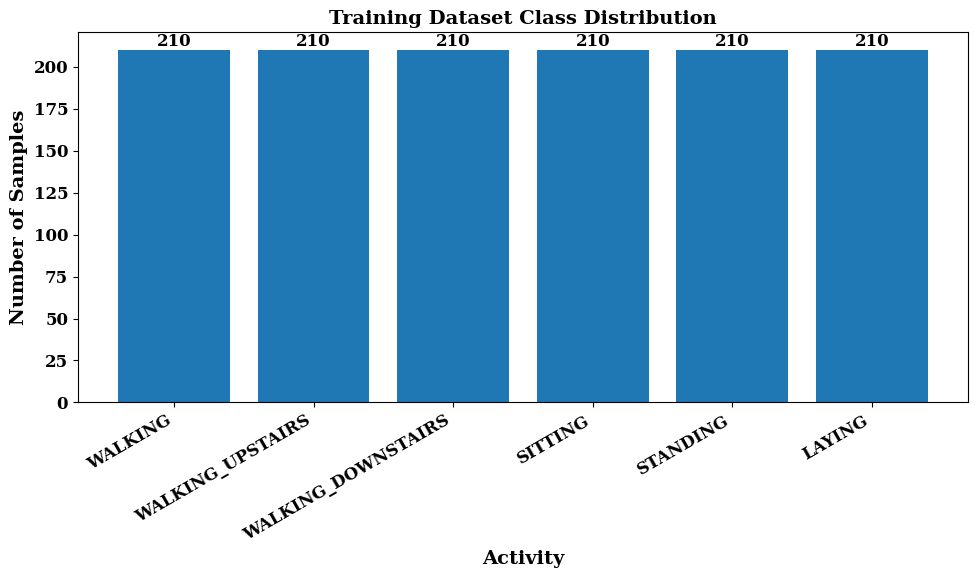


Figure saved to:
/content/experiment6/outputs/01_class_distribution.eps

Class distribution plot completed.


In [8]:
# ============================================================
# CELL 9 — ACTIVITY NAMES + CLASS DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load official activity names
# ------------------------------------------------------------

activity_file = UCI_ROOT / "activity_labels.txt"

activity_table = pd.read_csv(
    activity_file,
    sep=r"\s+",
    header=None,
    names=["id", "activity"]
)

activity_names = (
    activity_table
    .sort_values("id")["activity"]
    .tolist()
)

print("=" * 60)
print("ACTIVITY CLASSES")
print("=" * 60)

for i, name in enumerate(activity_names):
    print(f"{i}: {name}")

# ------------------------------------------------------------
# Count training samples
# ------------------------------------------------------------

class_counts = np.bincount(
    y_train,
    minlength=6
)

distribution_df = pd.DataFrame({
    "Class": np.arange(6),
    "Activity": activity_names,
    "Count": class_counts
})

print("\n" + "=" * 60)
print("TRAINING CLASS DISTRIBUTION")
print("=" * 60)

print(
    distribution_df[
        ["Class", "Activity", "Count"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    activity_names,
    class_counts
)

ax.set_title(
    "Training Dataset Class Distribution",
    fontweight="bold"
)

ax.set_xlabel(
    "Activity",
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Samples",
    fontweight="bold"
)

ax.tick_params(
    axis="both",
    labelsize=12
)

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
    fontweight="bold"
)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# Add counts above bars
for bar, count in zip(
    bars,
    class_counts
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=12
    )

fig.tight_layout()

# ------------------------------------------------------------
# Save EPS at 600 DPI
# ------------------------------------------------------------

class_plot_path = (
    OUTPUT_DIR /
    "01_class_distribution.eps"
)

fig.savefig(
    class_plot_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nFigure saved to:")
print(class_plot_path)

print("\nClass distribution plot completed.")

TEMPORAL SENSOR VISUALIZATION

Activities:
  0: WALKING
  3: SITTING
  5: LAYING

Channels:
  0: body_acc_x
  3: body_gyro_x
  6: total_acc_x


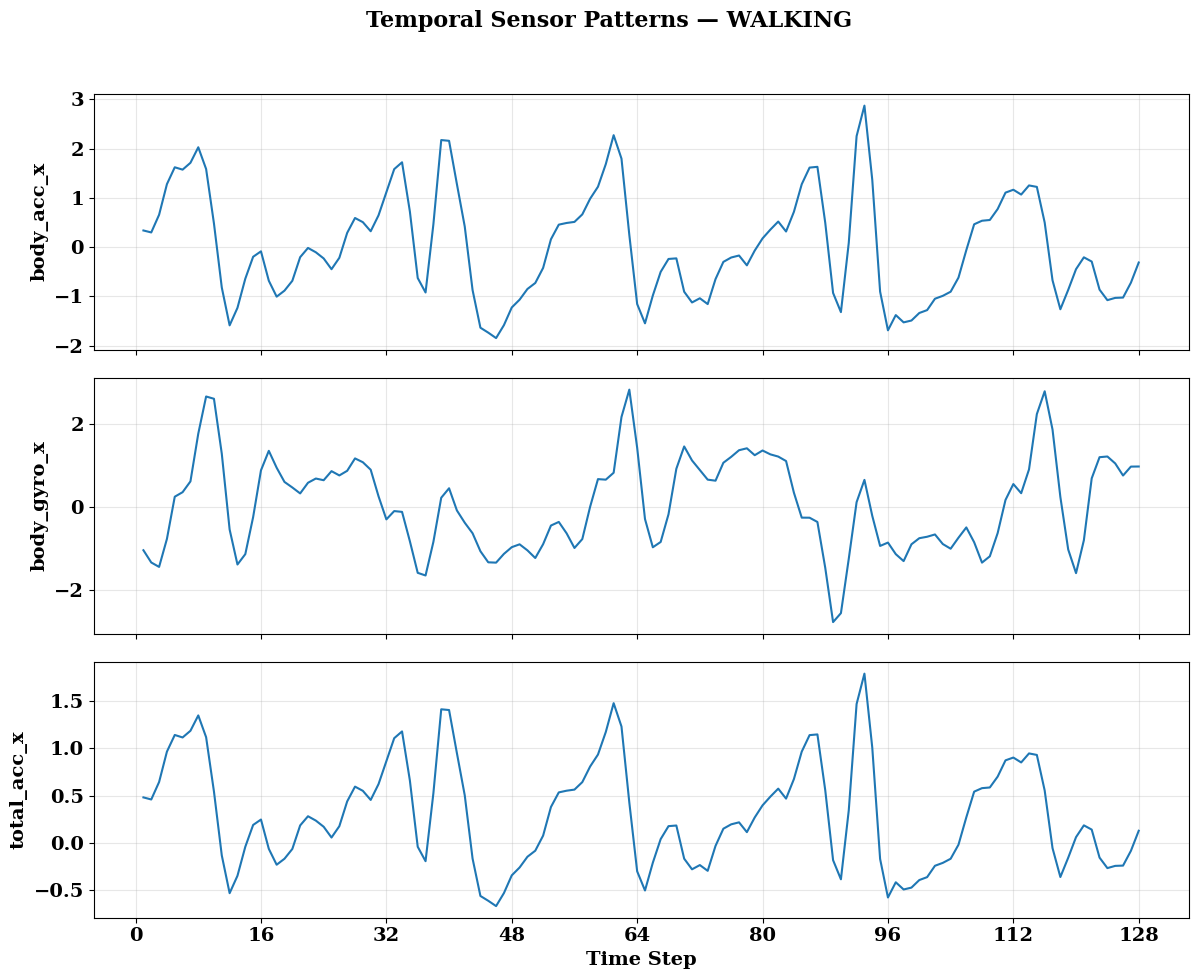


Saved: /content/experiment6/outputs/02_temporal_walking.eps


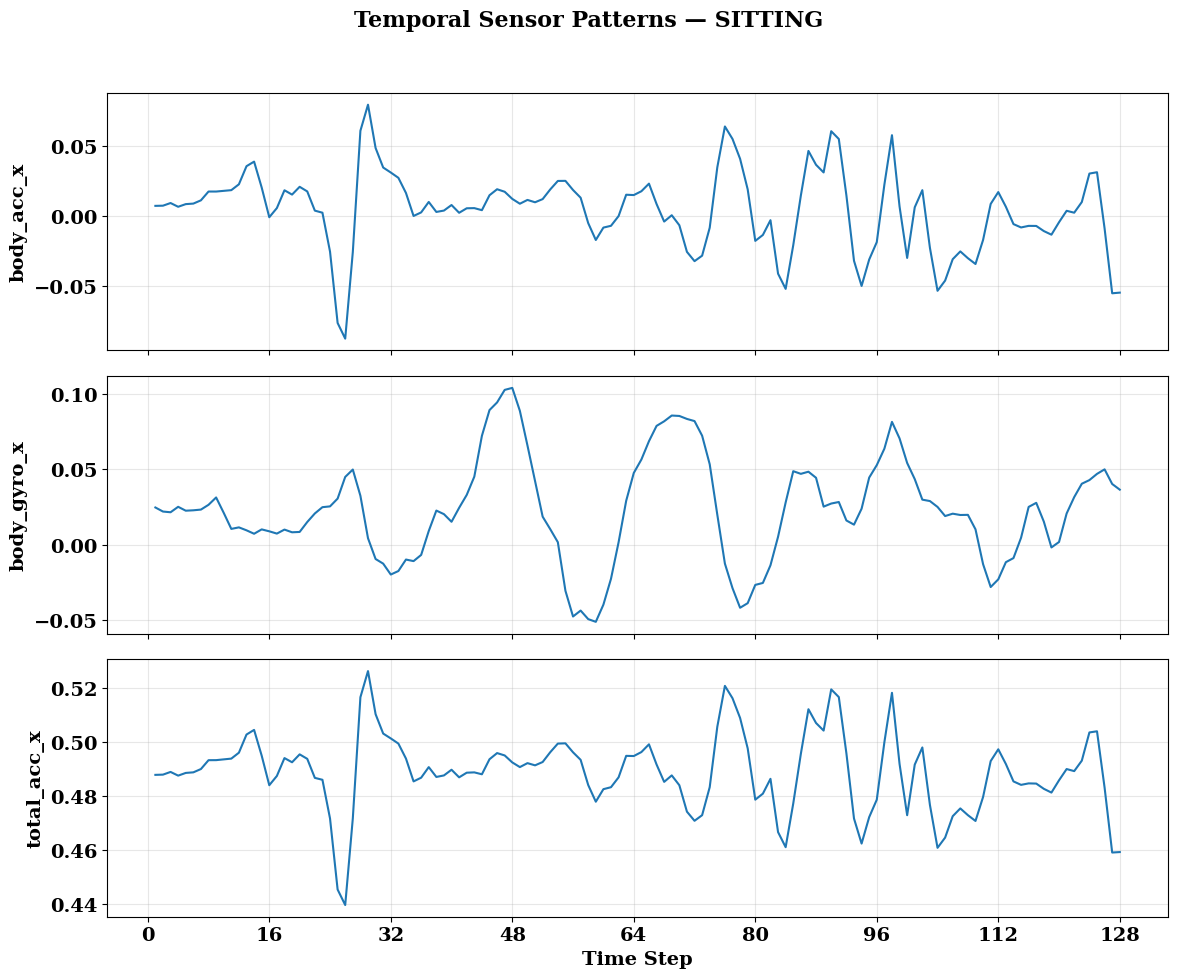


Saved: /content/experiment6/outputs/02_temporal_sitting.eps


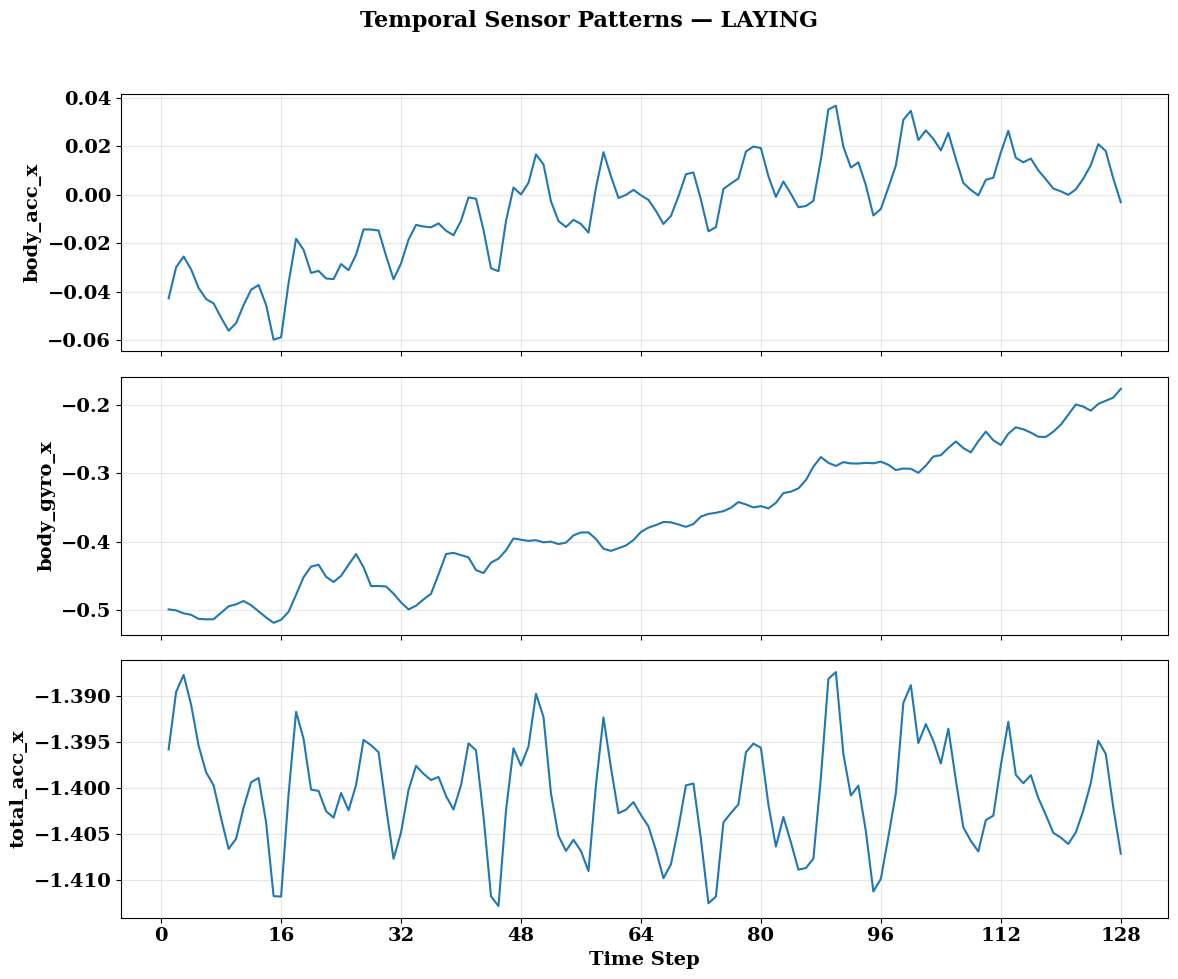


Saved: /content/experiment6/outputs/02_temporal_laying.eps

TEMPORAL VISUALIZATION COMPLETED


In [9]:
# ============================================================
# CELL 10 — TEMPORAL SENSOR VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

selected_classes = [
    0,  # WALKING
    3,  # SITTING
    5   # LAYING
]

selected_channels = [
    0,  # body_acc_x
    3,  # body_gyro_x
    6   # total_acc_x
]

time_steps = np.arange(1, 129)

print("=" * 60)
print("TEMPORAL SENSOR VISUALIZATION")
print("=" * 60)

print("\nActivities:")

for class_id in selected_classes:
    print(
        f"  {class_id}: "
        f"{activity_names[class_id]}"
    )

print("\nChannels:")

for channel_id in selected_channels:
    print(
        f"  {channel_id}: "
        f"{SIGNALS[channel_id]}"
    )

# ------------------------------------------------------------
# Create one figure per activity
# ------------------------------------------------------------

for class_id in selected_classes:

    # Find samples belonging to this activity
    class_indices = np.where(
        y_train == class_id
    )[0]

    # Select first sample for visualization
    sample_index = class_indices[0]

    sample = X_train[sample_index]

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(12, 10),
        sharex=True
    )

    fig.suptitle(
        f"Temporal Sensor Patterns — "
        f"{activity_names[class_id]}",
        fontsize=16,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Plot each sensor channel
    # --------------------------------------------------------

    for ax, channel_id in zip(
        axes,
        selected_channels
    ):

        ax.plot(
            time_steps,
            sample[:, channel_id],
            linewidth=1.5
        )

        ax.set_ylabel(
            SIGNALS[channel_id],
            fontweight="bold"
        )

        ax.grid(
            True,
            alpha=0.3
        )

        # Bold tick labels
        for label in ax.get_xticklabels():
            label.set_fontweight("bold")

        for label in ax.get_yticklabels():
            label.set_fontweight("bold")

    # --------------------------------------------------------
    # X-axis
    # --------------------------------------------------------

    axes[-1].set_xlabel(
        "Time Step",
        fontweight="bold"
    )

    axes[-1].set_xticks(
        np.arange(0, 129, 16)
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    filename = (
        f"02_temporal_"
        f"{activity_names[class_id].lower()}.eps"
    )

    save_path = OUTPUT_DIR / filename

    fig.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    fig.savefig(
        save_path,
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        f"\nSaved: {save_path}"
    )

print("\n" + "=" * 60)
print("TEMPORAL VISUALIZATION COMPLETED")
print("=" * 60)

In [10]:
# ============================================================
# CELL 11 — VANILLA RNN NUMERICAL EXERCISE
# ============================================================

import numpy as np

print("=" * 60)
print("VANILLA RNN NUMERICAL EXERCISE")
print("=" * 60)

# Given values
x1 = 0.5
x2 = 0.7
x3 = 0.2

h0 = 0.0

Wx = 0.5
Wh = 0.8
b = 0.1

# RNN equation:
# h_t = tanh(Wx*x_t + Wh*h_(t-1) + b)

# ------------------------------------------------------------
# Step 1: Calculate h1
# ------------------------------------------------------------

z1 = Wx * x1 + Wh * h0 + b
h1 = np.tanh(z1)

# ------------------------------------------------------------
# Step 2: Calculate h2
# ------------------------------------------------------------

z2 = Wx * x2 + Wh * h1 + b
h2 = np.tanh(z2)

# ------------------------------------------------------------
# Step 3: Calculate h3
# ------------------------------------------------------------

z3 = Wx * x3 + Wh * h2 + b
h3 = np.tanh(z3)

# ------------------------------------------------------------
# Display calculations
# ------------------------------------------------------------

print("\nGiven:")
print(f"x1 = {x1}")
print(f"x2 = {x2}")
print(f"x3 = {x3}")
print(f"h0 = {h0}")
print(f"Wx = {Wx}")
print(f"Wh = {Wh}")
print(f"b  = {b}")

print("\n" + "-" * 60)

print("\nStep 1:")
print(
    f"h1 = tanh(({Wx})({x1}) + "
    f"({Wh})({h0}) + {b})"
)
print(f"h1 = tanh({z1:.6f})")
print(f"h1 = {h1:.6f}")

print("\nStep 2:")
print(
    f"h2 = tanh(({Wx})({x2}) + "
    f"({Wh})({h1:.6f}) + {b})"
)
print(f"h2 = tanh({z2:.6f})")
print(f"h2 = {h2:.6f}")

print("\nStep 3:")
print(
    f"h3 = tanh(({Wx})({x3}) + "
    f"({Wh})({h2:.6f}) + {b})"
)
print(f"h3 = tanh({z3:.6f})")
print(f"h3 = {h3:.6f}")

# ------------------------------------------------------------
# Final results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(f"h1 = {h1:.6f}")
print(f"h2 = {h2:.6f}")
print(f"h3 = {h3:.6f}")


VANILLA RNN NUMERICAL EXERCISE

Given:
x1 = 0.5
x2 = 0.7
x3 = 0.2
h0 = 0.0
Wx = 0.5
Wh = 0.8
b  = 0.1

------------------------------------------------------------

Step 1:
h1 = tanh((0.5)(0.5) + (0.8)(0.0) + 0.1)
h1 = tanh(0.350000)
h1 = 0.336376

Step 2:
h2 = tanh((0.5)(0.7) + (0.8)(0.336376) + 0.1)
h2 = tanh(0.719100)
h2 = 0.616352

Step 3:
h3 = tanh((0.5)(0.2) + (0.8)(0.616352) + 0.1)
h3 = tanh(0.693081)
h3 = 0.599958

FINAL RESULTS
h1 = 0.336376
h2 = 0.616352
h3 = 0.599958


In [11]:
# ============================================================
# CELL 12 — VANILLA RNN MODEL
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 60)
print("BUILDING VANILLA RNN")
print("=" * 60)

# ------------------------------------------------------------
# Clear any previous TensorFlow models from memory
# ------------------------------------------------------------

tf.keras.backend.clear_session()
gc.collect()

# ------------------------------------------------------------
# Model parameters
# ------------------------------------------------------------

INPUT_SHAPE = (128, 9)
N_CLASSES = 6

RNN_UNITS = 32
DENSE_UNITS = 16
DROPOUT_RATE = 0.20

LEARNING_RATE = 1e-3

BATCH_SIZE = 32
EPOCHS = 30

# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------

rnn_model = keras.Sequential([

    layers.Input(
        shape=INPUT_SHAPE,
        name="input"
    ),

    layers.SimpleRNN(
        RNN_UNITS,
        activation="tanh",
        name="simple_rnn"
    ),

    layers.Dropout(
        DROPOUT_RATE,
        name="dropout"
    ),

    layers.Dense(
        DENSE_UNITS,
        activation="relu",
        name="dense_16"
    ),

    layers.Dense(
        N_CLASSES,
        activation="softmax",
        name="output"
    )
])

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

optimizer = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

rnn_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Display architecture
# ------------------------------------------------------------

rnn_model.summary()

print("\n" + "=" * 60)
print("RNN MODEL COMPILED SUCCESSFULLY")
print("=" * 60)

BUILDING VANILLA RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)


RNN MODEL COMPILED SUCCESSFULLY


In [12]:
# ============================================================
# CELL 13 — TRAIN VANILLA RNN
# ============================================================

import time
import gc
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping
)

print("=" * 60)
print("TRAINING VANILLA RNN")
print("=" * 60)

# ------------------------------------------------------------
# Clear old memory
# ------------------------------------------------------------

gc.collect()

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

RNN_CHECKPOINT = (
    MODEL_DIR / "best_rnn.keras"
)

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

checkpoint = ModelCheckpoint(
    filepath=str(RNN_CHECKPOINT),
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=7,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Start timer
# ------------------------------------------------------------

rnn_start_time = time.perf_counter()

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

rnn_history = rnn_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    callbacks=[
        checkpoint,
        early_stopping
    ],

    verbose=1
)

# ------------------------------------------------------------
# Stop timer
# ------------------------------------------------------------

rnn_training_time = (
    time.perf_counter()
    - rnn_start_time
)

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

rnn_model = keras.models.load_model(
    RNN_CHECKPOINT
)

# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------

best_epoch = (
    np.argmin(
        rnn_history.history["val_loss"]
    ) + 1
)

best_val_loss = min(
    rnn_history.history["val_loss"]
)

best_val_accuracy = max(
    rnn_history.history["val_accuracy"]
)

print("\n" + "=" * 60)
print("RNN TRAINING COMPLETED")
print("=" * 60)

print(
    f"\nEpochs actually completed: "
    f"{len(rnn_history.history['loss'])}"
)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.4f}"
)

print(
    f"\nTraining time: "
    f"{rnn_training_time:.2f} seconds"
)

print(
    f"\nBest model saved at:\n"
    f"{RNN_CHECKPOINT}"
)

TRAINING VANILLA RNN
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2340 - loss: 1.8857
Epoch 1: val_loss improved from None to 1.52043, saving model to /content/experiment6/models/best_rnn.keras

Epoch 1: finished saving model to /content/experiment6/models/best_rnn.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.3325 - loss: 1.7230 - val_accuracy: 0.4037 - val_loss: 1.5204
Epoch 2/30
36/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4506 - loss: 1.5067
Epoch 2: val_loss improved from 1.52043 to 1.37489, saving model to /content/experiment6/models/best_rnn.keras

Epoch 2: finished saving model to /content/experiment6/models/best_rnn.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4492 - loss: 1.4827 - val_accuracy: 0.4370 - val_loss: 1.3749
Epoch 3/30
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4594 - loss: 1.3333
Epoch 3: val_loss improved from 1.37489 to 1.18494, saving model to /content/experiment6/models/best_rnn.keras

Epoch

RNN TRAINING CURVES


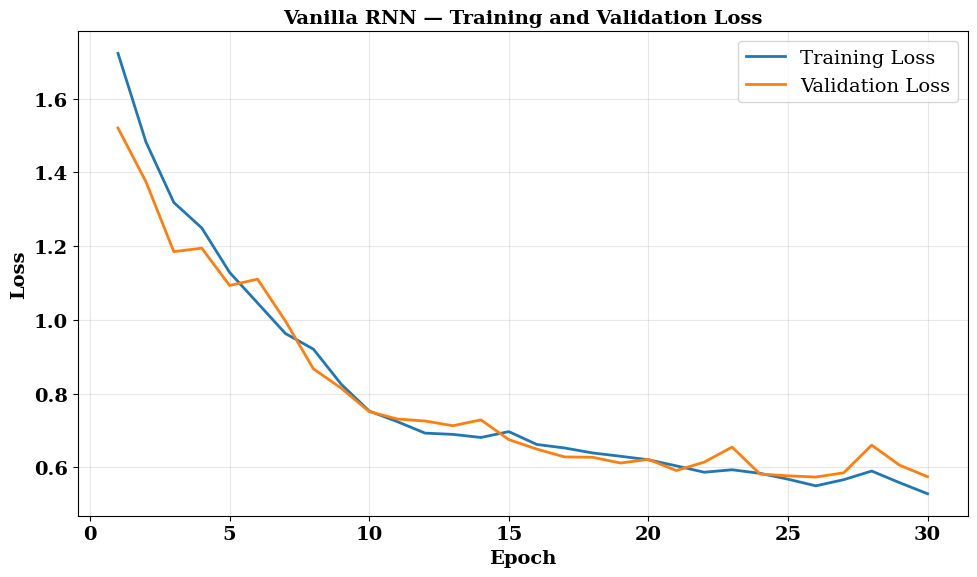


Saved:
/content/experiment6/outputs/03_rnn_training_validation_loss.eps


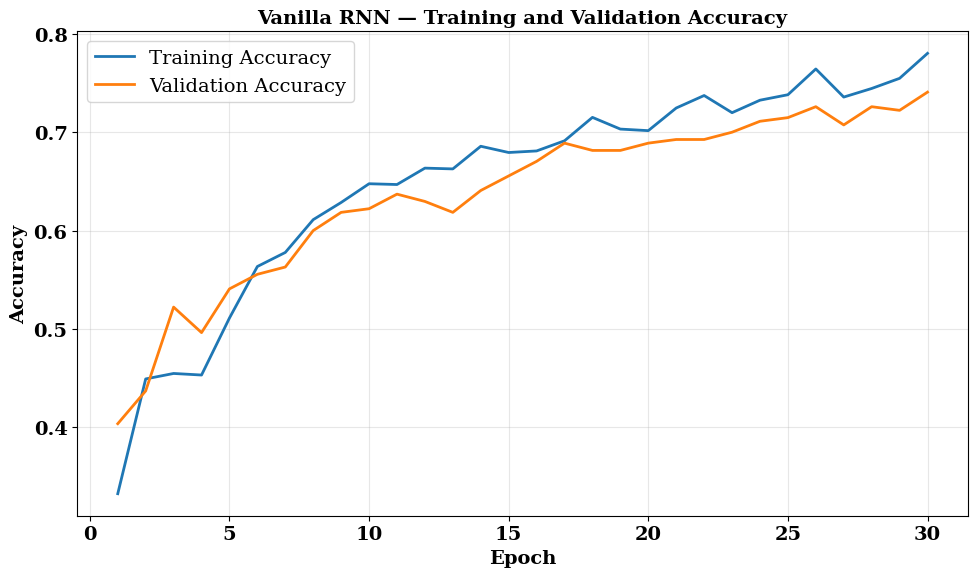


Saved:
/content/experiment6/outputs/04_rnn_training_validation_accuracy.eps

RNN TRAINING PLOTS COMPLETED


In [13]:
# ============================================================
# CELL 14 — RNN TRAINING CURVES
# ============================================================

print("=" * 60)
print("RNN TRAINING CURVES")
print("=" * 60)

history = rnn_history.history

epochs = np.arange(
    1,
    len(history["loss"]) + 1
)

# ============================================================
# 1. LOSS CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    epochs,
    history["loss"],
    linewidth=2,
    label="Training Loss"
)

ax.plot(
    epochs,
    history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

ax.set_title(
    "Vanilla RNN — Training and Validation Loss",
    fontweight="bold"
)

ax.set_xlabel(
    "Epoch",
    fontweight="bold"
)

ax.set_ylabel(
    "Loss",
    fontweight="bold"
)

ax.legend()

ax.grid(
    True,
    alpha=0.3
)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

fig.tight_layout()

loss_path = (
    OUTPUT_DIR /
    "03_rnn_training_validation_loss.eps"
)

fig.savefig(
    loss_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nSaved:")
print(loss_path)


# ============================================================
# 2. ACCURACY CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    epochs,
    history["accuracy"],
    linewidth=2,
    label="Training Accuracy"
)

ax.plot(
    epochs,
    history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)

ax.set_title(
    "Vanilla RNN — Training and Validation Accuracy",
    fontweight="bold"
)

ax.set_xlabel(
    "Epoch",
    fontweight="bold"
)

ax.set_ylabel(
    "Accuracy",
    fontweight="bold"
)

ax.legend()

ax.grid(
    True,
    alpha=0.3
)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

fig.tight_layout()

accuracy_path = (
    OUTPUT_DIR /
    "04_rnn_training_validation_accuracy.eps"
)

fig.savefig(
    accuracy_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nSaved:")
print(accuracy_path)

print("\n" + "=" * 60)
print("RNN TRAINING PLOTS COMPLETED")
print("=" * 60)

VANILLA RNN — FINAL TEST EVALUATION
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

RNN TEST METRICS

Accuracy        : 0.7011 (70.11%)
Macro Precision : 0.6947
Macro Recall    : 0.6890
Macro F1        : 0.6864

Trainable Params: 1,974
Training Time   : 21.72 seconds

PER-CLASS CLASSIFICATION REPORT
                    precision    recall  f1-score   support

           WALKING     0.4871    0.4173    0.4495       496
  WALKING_UPSTAIRS     0.5502    0.6051    0.5763       471
WALKING_DOWNSTAIRS     0.5437    0.5333    0.5385       420
           SITTING     0.8696    0.6517    0.7451       491
          STANDING     0.7176    0.9267    0.8089       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.7011      2947
         macro avg     0.6947    0.6890    0.6864      2947
      weighted avg     0.7040    0.7011    0.6969      2947


CONFUSION MATRIX
                    WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  \
WALKING 

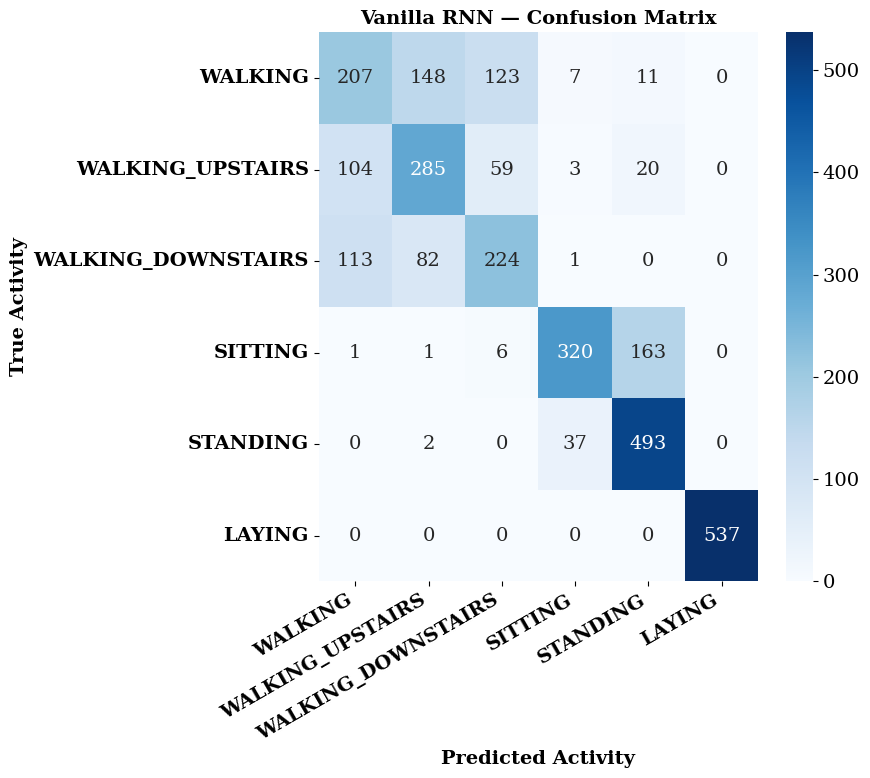


Confusion matrix saved to:
/content/experiment6/outputs/05_rnn_confusion_matrix.eps

RNN EVALUATION COMPLETED


In [14]:
# ============================================================
# CELL 15 — RNN FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("VANILLA RNN — FINAL TEST EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# Predict on OFFICIAL untouched UCI test set
# ------------------------------------------------------------

rnn_probabilities = rnn_model.predict(
    X_test_full,
    batch_size=BATCH_SIZE,
    verbose=1
)

rnn_predictions = np.argmax(
    rnn_probabilities,
    axis=1
)

# ------------------------------------------------------------
# Calculate required metrics
# ------------------------------------------------------------

rnn_test_accuracy = accuracy_score(
    y_test_full,
    rnn_predictions
)

rnn_test_precision = precision_score(
    y_test_full,
    rnn_predictions,
    average="macro",
    zero_division=0
)

rnn_test_recall = recall_score(
    y_test_full,
    rnn_predictions,
    average="macro",
    zero_division=0
)

rnn_test_f1 = f1_score(
    y_test_full,
    rnn_predictions,
    average="macro",
    zero_division=0
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

rnn_cm = confusion_matrix(
    y_test_full,
    rnn_predictions
)

# ------------------------------------------------------------
# Print metrics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RNN TEST METRICS")
print("=" * 60)

print(
    f"\nAccuracy        : "
    f"{rnn_test_accuracy:.4f} "
    f"({rnn_test_accuracy * 100:.2f}%)"
)

print(
    f"Macro Precision : "
    f"{rnn_test_precision:.4f}"
)

print(
    f"Macro Recall    : "
    f"{rnn_test_recall:.4f}"
)

print(
    f"Macro F1        : "
    f"{rnn_test_f1:.4f}"
)

print(
    f"\nTrainable Params: "
    f"{rnn_model.count_params():,}"
)

print(
    f"Training Time   : "
    f"{rnn_training_time:.2f} seconds"
)

# ------------------------------------------------------------
# Per-class classification report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test_full,
        rnn_predictions,
        target_names=activity_names,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Print confusion matrix numerically
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm_df = pd.DataFrame(
    rnn_cm,
    index=activity_names,
    columns=activity_names
)

print(cm_df)

# ------------------------------------------------------------
# Save metrics
# ------------------------------------------------------------

rnn_results = {
    "model": "Vanilla RNN",
    "parameters": int(
        rnn_model.count_params()
    ),
    "training_time_seconds": float(
        rnn_training_time
    ),
    "test_accuracy": float(
        rnn_test_accuracy
    ),
    "macro_precision": float(
        rnn_test_precision
    ),
    "macro_recall": float(
        rnn_test_recall
    ),
    "macro_f1": float(
        rnn_test_f1
    )
}

with open(
    OUTPUT_DIR / "rnn_results.json",
    "w"
) as f:
    json.dump(
        rnn_results,
        f,
        indent=4
    )

np.save(
    OUTPUT_DIR / "rnn_confusion_matrix.npy",
    rnn_cm
)

print("\nResults saved.")

# ------------------------------------------------------------
# Confusion matrix plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 8)
)

sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_names,
    yticklabels=activity_names,
    ax=ax
)

ax.set_title(
    "Vanilla RNN — Confusion Matrix",
    fontweight="bold"
)

ax.set_xlabel(
    "Predicted Activity",
    fontweight="bold"
)

ax.set_ylabel(
    "True Activity",
    fontweight="bold"
)

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
    fontweight="bold"
)

plt.setp(
    ax.get_yticklabels(),
    rotation=0,
    fontweight="bold"
)

fig.tight_layout()

cm_path = (
    OUTPUT_DIR /
    "05_rnn_confusion_matrix.eps"
)

fig.savefig(
    cm_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nConfusion matrix saved to:")
print(cm_path)

print("\n" + "=" * 60)
print("RNN EVALUATION COMPLETED")
print("=" * 60)

In [15]:
# ============================================================
# CELL 16 — LSTM MODEL
# ============================================================

tf.keras.backend.clear_session()
gc.collect()

print("=" * 60)
print("BUILDING LSTM MODEL")
print("=" * 60)

lstm_model = keras.Sequential([
    layers.Input(
        shape=INPUT_SHAPE,
        name="input"
    ),

    # ONLY CHANGE FROM RNN:
    # SimpleRNN(32) -> LSTM(32)
    layers.LSTM(
        RNN_UNITS,
        activation="tanh",
        name="lstm_32"
    ),

    # Same classifier as RNN
    layers.Dropout(
        DROPOUT_RATE,
        name="dropout"
    ),

    layers.Dense(
        DENSE_UNITS,
        activation="relu",
        name="dense_16"
    ),

    layers.Dense(
        N_CLASSES,
        activation="softmax",
        name="output"
    )
])

# Same compilation settings as RNN
lstm_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

print("\nTrainable parameters:",
      f"{lstm_model.count_params():,}")

BUILDING LSTM MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters: 6,006


In [16]:
# ============================================================
# CELL 17 — LSTM TRAINING
# ============================================================

print("=" * 60)
print("TRAINING LSTM")
print("=" * 60)

# Clear previous LSTM checkpoint if it exists
lstm_checkpoint_path = MODEL_DIR / "best_lstm.keras"

if lstm_checkpoint_path.exists():
    lstm_checkpoint_path.unlink()

# Checkpoint: save best validation-loss model
lstm_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=str(lstm_checkpoint_path),
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# Early stopping — same as RNN
lstm_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

# Train
lstm_start_time = time.time()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        lstm_checkpoint,
        lstm_early_stopping
    ],
    verbose=1
)

lstm_training_time = time.time() - lstm_start_time

print("\n" + "=" * 60)
print("LSTM TRAINING COMPLETED")
print("=" * 60)

print(
    f"\nTraining time: "
    f"{lstm_training_time:.2f} seconds"
)

print(
    f"Epochs completed: "
    f"{len(lstm_history.history['loss'])}"
)

best_epoch = (
    np.argmin(lstm_history.history["val_loss"]) + 1
)

best_val_loss = min(
    lstm_history.history["val_loss"]
)

best_val_accuracy = max(
    lstm_history.history["val_accuracy"]
)

print(
    f"Best epoch: "
    f"{best_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.4f} "
    f"({best_val_accuracy * 100:.2f}%)"
)

print(
    f"\nCheckpoint saved at:\n"
    f"{lstm_checkpoint_path}"
)

TRAINING LSTM
Epoch 1/30
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2578 - loss: 1.7411
Epoch 1: val_loss improved from None to 1.52260, saving model to /content/experiment6/models/best_lstm.keras

Epoch 1: finished saving model to /content/experiment6/models/best_lstm.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.3381 - loss: 1.6611 - val_accuracy: 0.4296 - val_loss: 1.5226
Epoch 2/30
34/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4672 - loss: 1.4211
Epoch 2: val_loss improved from 1.52260 to 1.24037, saving model to /content/experiment6/models/best_lstm.keras

Epoch 2: finished saving model to /content/experiment6/models/best_lstm.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4627 - loss: 1.3797 - val_accuracy: 0.4407 - val_loss: 1.2404
Epoch 3/30
35/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5280 - loss: 1.1237
Epoch 3: val_loss improved from 1.24037 to 0.95929, saving model to /content/experiment6/models/best_lstm.keras

Epoch 3: f

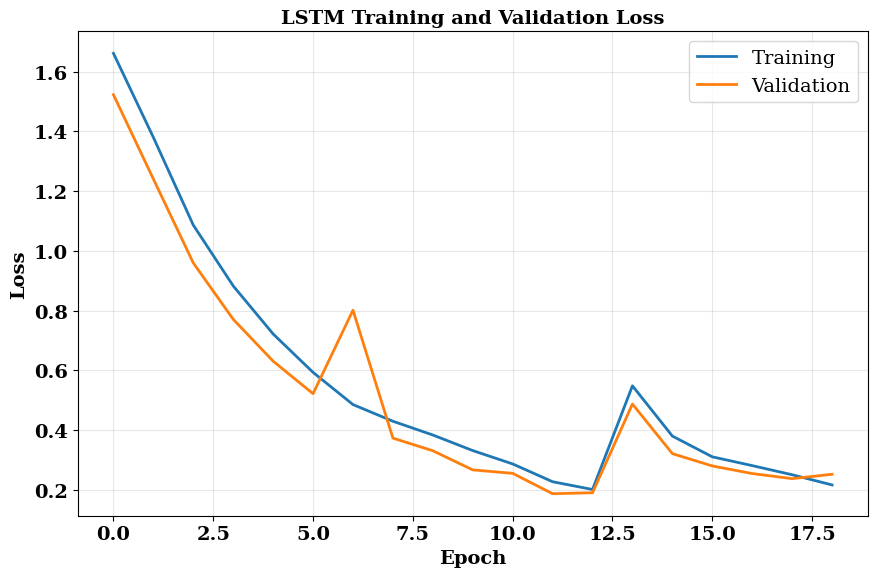

Saved: /content/experiment6/outputs/06_lstm_training_validation_loss.eps


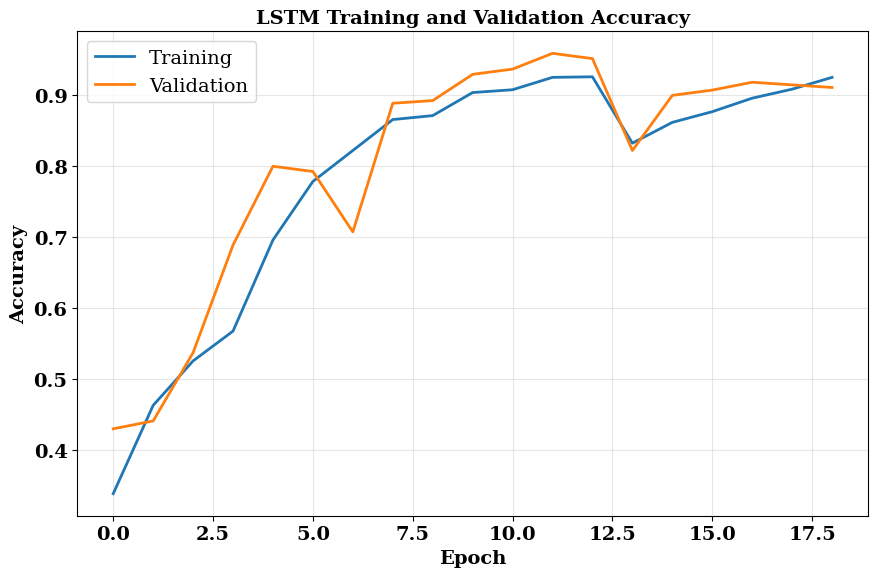

Saved: /content/experiment6/outputs/07_lstm_training_validation_accuracy.eps


In [17]:
# ============================================================
# CELL 18 — LSTM TRAINING & VALIDATION CURVES
# ============================================================

def save_training_curve(
    history,
    metric,
    title,
    ylabel,
    filename
):
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(
        history.history[metric],
        linewidth=2,
        label="Training"
    )

    ax.plot(
        history.history[f"val_{metric}"],
        linewidth=2,
        label="Validation"
    )

    ax.set_xlabel(
        "Epoch",
        fontweight="bold"
    )

    ax.set_ylabel(
        ylabel,
        fontweight="bold"
    )

    ax.set_title(
        title,
        fontweight="bold"
    )

    ax.legend(
        frameon=True
    )

    # Bold tick labels
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.grid(
        True,
        alpha=0.3
    )

    fig.tight_layout()

    save_path = OUTPUT_DIR / filename

    fig.savefig(
        save_path,
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"Saved: {save_path}")


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

save_training_curve(
    lstm_history,
    metric="loss",
    title="LSTM Training and Validation Loss",
    ylabel="Loss",
    filename="06_lstm_training_validation_loss.eps"
)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

save_training_curve(
    lstm_history,
    metric="accuracy",
    title="LSTM Training and Validation Accuracy",
    ylabel="Accuracy",
    filename="07_lstm_training_validation_accuracy.eps"
)

LSTM — FINAL TEST EVALUATION
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

LSTM TEST METRICS

Accuracy        : 0.8826 (88.26%)
Macro Precision : 0.8837
Macro Recall    : 0.8817
Macro F1        : 0.8798

Trainable Params: 6,006
Training Time   : 14.44 seconds

PER-CLASS CLASSIFICATION REPORT
                    precision    recall  f1-score   support

           WALKING     0.9226    0.8891    0.9055       496
  WALKING_UPSTAIRS     0.8583    0.8875    0.8727       471
WALKING_DOWNSTAIRS     0.8387    0.9286    0.8814       420
           SITTING     0.8854    0.6925    0.7771       491
          STANDING     0.7970    0.8929    0.8422       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.8826      2947
         macro avg     0.8837    0.8817    0.8798      2947
      weighted avg     0.8856    0.8826    0.8812      2947


CONFUSION MATRIX
                    WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  \
WALKING       

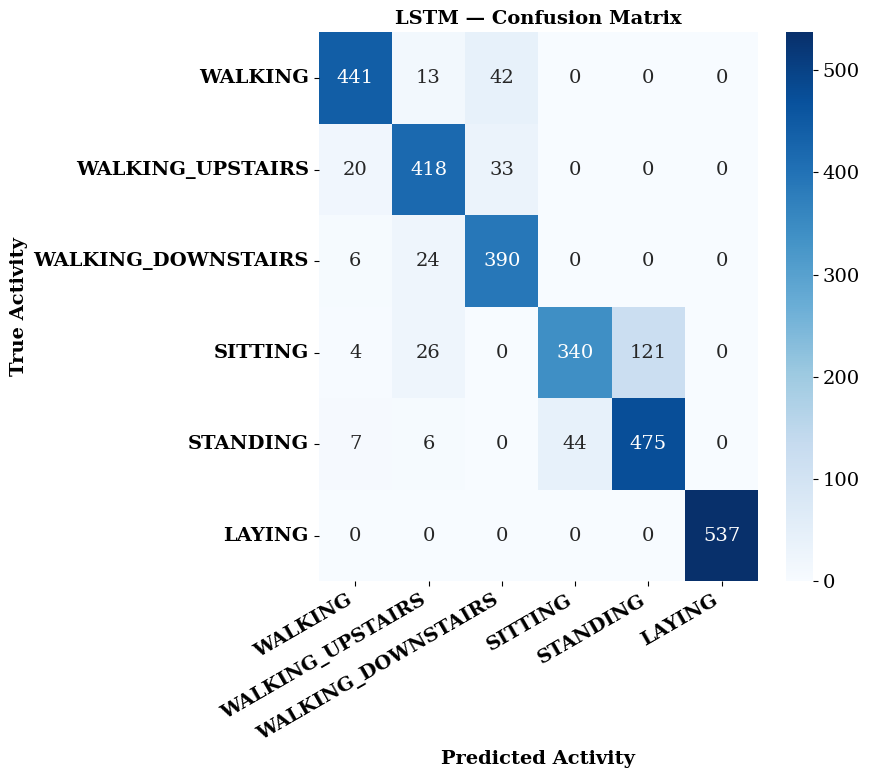


Confusion matrix saved to:
/content/experiment6/outputs/08_lstm_confusion_matrix.eps

LSTM EVALUATION COMPLETED


In [18]:
# ============================================================
# CELL 19 — LSTM FINAL TEST EVALUATION
# ============================================================

print("=" * 60)
print("LSTM — FINAL TEST EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# Predict on official untouched UCI test set
# ------------------------------------------------------------

lstm_probabilities = lstm_model.predict(
    X_test_full,
    batch_size=BATCH_SIZE,
    verbose=1
)

lstm_predictions = np.argmax(
    lstm_probabilities,
    axis=1
)

# ------------------------------------------------------------
# Calculate required metrics
# ------------------------------------------------------------

lstm_test_accuracy = accuracy_score(
    y_test_full,
    lstm_predictions
)

lstm_test_precision = precision_score(
    y_test_full,
    lstm_predictions,
    average="macro",
    zero_division=0
)

lstm_test_recall = recall_score(
    y_test_full,
    lstm_predictions,
    average="macro",
    zero_division=0
)

lstm_test_f1 = f1_score(
    y_test_full,
    lstm_predictions,
    average="macro",
    zero_division=0
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

lstm_cm = confusion_matrix(
    y_test_full,
    lstm_predictions
)

# ------------------------------------------------------------
# Print metrics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LSTM TEST METRICS")
print("=" * 60)

print(
    f"\nAccuracy        : "
    f"{lstm_test_accuracy:.4f} "
    f"({lstm_test_accuracy * 100:.2f}%)"
)

print(
    f"Macro Precision : "
    f"{lstm_test_precision:.4f}"
)

print(
    f"Macro Recall    : "
    f"{lstm_test_recall:.4f}"
)

print(
    f"Macro F1        : "
    f"{lstm_test_f1:.4f}"
)

print(
    f"\nTrainable Params: "
    f"{lstm_model.count_params():,}"
)

print(
    f"Training Time   : "
    f"{lstm_training_time:.2f} seconds"
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test_full,
        lstm_predictions,
        target_names=activity_names,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

lstm_cm_df = pd.DataFrame(
    lstm_cm,
    index=activity_names,
    columns=activity_names
)

print(lstm_cm_df)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

lstm_results = {
    "model": "LSTM",
    "parameters": int(
        lstm_model.count_params()
    ),
    "training_time_seconds": float(
        lstm_training_time
    ),
    "test_accuracy": float(
        lstm_test_accuracy
    ),
    "macro_precision": float(
        lstm_test_precision
    ),
    "macro_recall": float(
        lstm_test_recall
    ),
    "macro_f1": float(
        lstm_test_f1
    )
}

with open(
    OUTPUT_DIR / "lstm_results.json",
    "w"
) as f:
    json.dump(
        lstm_results,
        f,
        indent=4
    )

np.save(
    OUTPUT_DIR / "lstm_confusion_matrix.npy",
    lstm_cm
)

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 8)
)

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_names,
    yticklabels=activity_names,
    ax=ax
)

ax.set_title(
    "LSTM — Confusion Matrix",
    fontweight="bold"
)

ax.set_xlabel(
    "Predicted Activity",
    fontweight="bold"
)

ax.set_ylabel(
    "True Activity",
    fontweight="bold"
)

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
    fontweight="bold"
)

plt.setp(
    ax.get_yticklabels(),
    rotation=0,
    fontweight="bold"
)

fig.tight_layout()

lstm_cm_path = (
    OUTPUT_DIR /
    "08_lstm_confusion_matrix.eps"
)

fig.savefig(
    lstm_cm_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nConfusion matrix saved to:")
print(lstm_cm_path)

print("\n" + "=" * 60)
print("LSTM EVALUATION COMPLETED")
print("=" * 60)

In [19]:
# ============================================================
# CELL 20 — GRU MODEL
# ============================================================

tf.keras.backend.clear_session()
gc.collect()

print("=" * 60)
print("BUILDING GRU MODEL")
print("=" * 60)

gru_model = keras.Sequential([
    layers.Input(
        shape=INPUT_SHAPE,
        name="input"
    ),

    # Only recurrent layer changes
    layers.GRU(
        RNN_UNITS,
        activation="tanh",
        name="gru_32"
    ),

    # Same classifier as RNN and LSTM
    layers.Dropout(
        DROPOUT_RATE,
        name="dropout"
    ),

    layers.Dense(
        DENSE_UNITS,
        activation="relu",
        name="dense_16"
    ),

    layers.Dense(
        N_CLASSES,
        activation="softmax",
        name="output"
    )
])

# Same training configuration
gru_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

print(
    "\nTrainable parameters:",
    f"{gru_model.count_params():,}"
)

BUILDING GRU MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_32 (GRU)                    │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters: 4,758


In [20]:
# ============================================================
# CELL 21 — GRU TRAINING
# ============================================================

print("=" * 60)
print("TRAINING GRU")
print("=" * 60)

# ------------------------------------------------------------
# Checkpoint path
# ------------------------------------------------------------

gru_checkpoint_path = MODEL_DIR / "best_gru.keras"

if gru_checkpoint_path.exists():
    gru_checkpoint_path.unlink()

# ------------------------------------------------------------
# Model checkpoint
# ------------------------------------------------------------

gru_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=str(gru_checkpoint_path),
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# ------------------------------------------------------------
# Early stopping — same as RNN/LSTM
# ------------------------------------------------------------

gru_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Train GRU
# ------------------------------------------------------------

gru_start_time = time.time()

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        gru_checkpoint,
        gru_early_stopping
    ],
    verbose=1
)

gru_training_time = time.time() - gru_start_time

# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GRU TRAINING COMPLETED")
print("=" * 60)

print(
    f"\nTraining time: "
    f"{gru_training_time:.2f} seconds"
)

print(
    f"Epochs completed: "
    f"{len(gru_history.history['loss'])}"
)

best_epoch = (
    np.argmin(gru_history.history["val_loss"]) + 1
)

best_val_loss = min(
    gru_history.history["val_loss"]
)

best_val_accuracy = max(
    gru_history.history["val_accuracy"]
)

print(
    f"Best epoch: "
    f"{best_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.4f} "
    f"({best_val_accuracy * 100:.2f}%)"
)

print(
    f"\nCheckpoint saved at:\n"
    f"{gru_checkpoint_path}"
)

TRAINING GRU
Epoch 1/30
36/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1728 - loss: 1.8252 
Epoch 1: val_loss improved from None to 1.60545, saving model to /content/experiment6/models/best_gru.keras

Epoch 1: finished saving model to /content/experiment6/models/best_gru.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2357 - loss: 1.7452 - val_accuracy: 0.3852 - val_loss: 1.6054
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3866 - loss: 1.5428
Epoch 2: val_loss improved from 1.60545 to 1.38244, saving model to /content/experiment6/models/best_gru.keras

Epoch 2: finished saving model to /content/experiment6/models/best_gru.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3794 - loss: 1.5000 - val_accuracy: 0.4741 - val_loss: 1.3824
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4724 - loss: 1.3262
Epoch 3: val_loss improved from 1.38244 to 1.19030, saving model to /content/experiment6/models/best_gru.keras

Epoch 3: finis

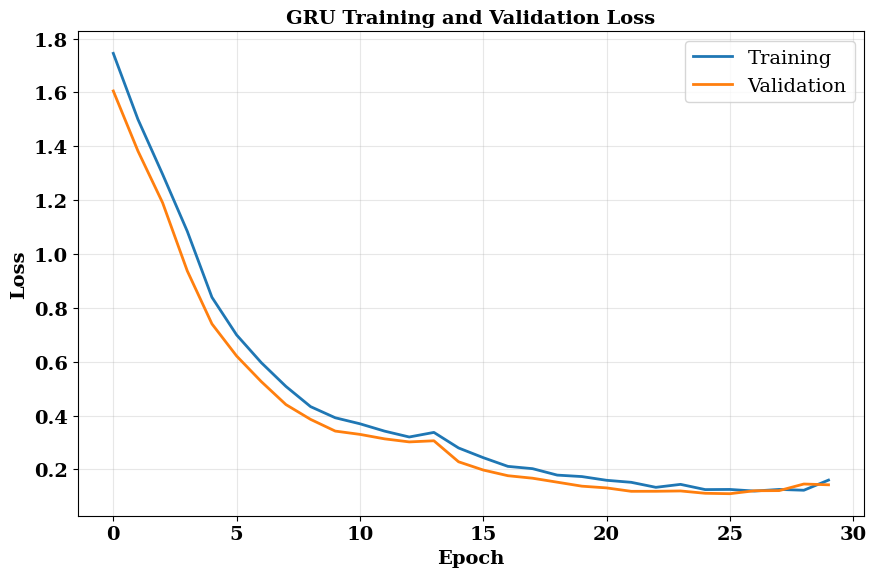

Saved: /content/experiment6/outputs/09_gru_training_validation_loss.eps


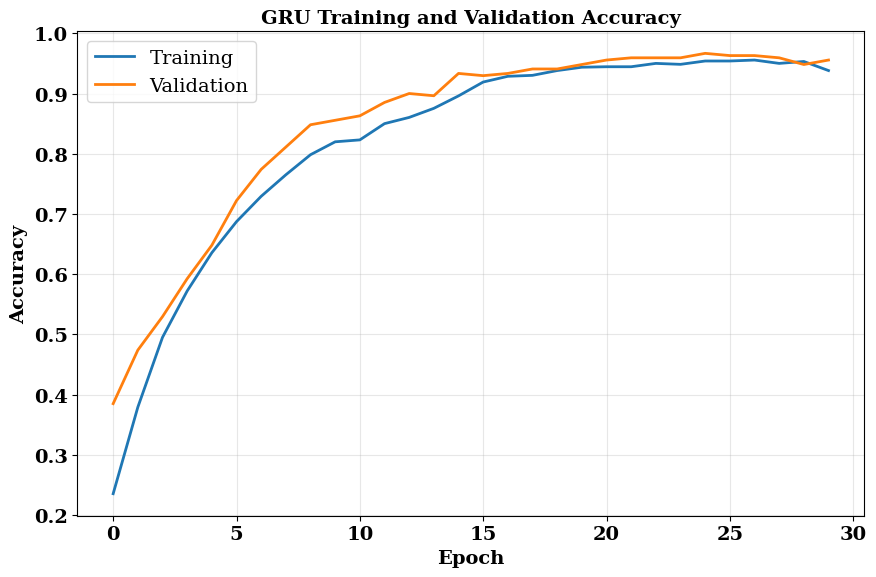

Saved: /content/experiment6/outputs/10_gru_training_validation_accuracy.eps


In [21]:
# ============================================================
# CELL 22 — GRU TRAINING & VALIDATION CURVES
# ============================================================

save_training_curve(
    gru_history,
    metric="loss",
    title="GRU Training and Validation Loss",
    ylabel="Loss",
    filename="09_gru_training_validation_loss.eps"
)

save_training_curve(
    gru_history,
    metric="accuracy",
    title="GRU Training and Validation Accuracy",
    ylabel="Accuracy",
    filename="10_gru_training_validation_accuracy.eps"
)

GRU — FINAL TEST EVALUATION
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

GRU TEST METRICS

Accuracy        : 0.8826 (88.26%)
Macro Precision : 0.8859
Macro Recall    : 0.8825
Macro F1        : 0.8824

Trainable Params: 4,758
Training Time   : 17.75 seconds

PER-CLASS CLASSIFICATION REPORT
                    precision    recall  f1-score   support

           WALKING     0.8298    0.9435    0.8830       496
  WALKING_UPSTAIRS     0.8787    0.8769    0.8778       471
WALKING_DOWNSTAIRS     0.9257    0.9190    0.9223       420
           SITTING     0.8723    0.7373    0.7991       491
          STANDING     0.8091    0.8684    0.8377       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.8826      2947
         macro avg     0.8859    0.8825    0.8824      2947
      weighted avg     0.8856    0.8826    0.8822      2947


CONFUSION MATRIX
                    WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  \
WALKING         

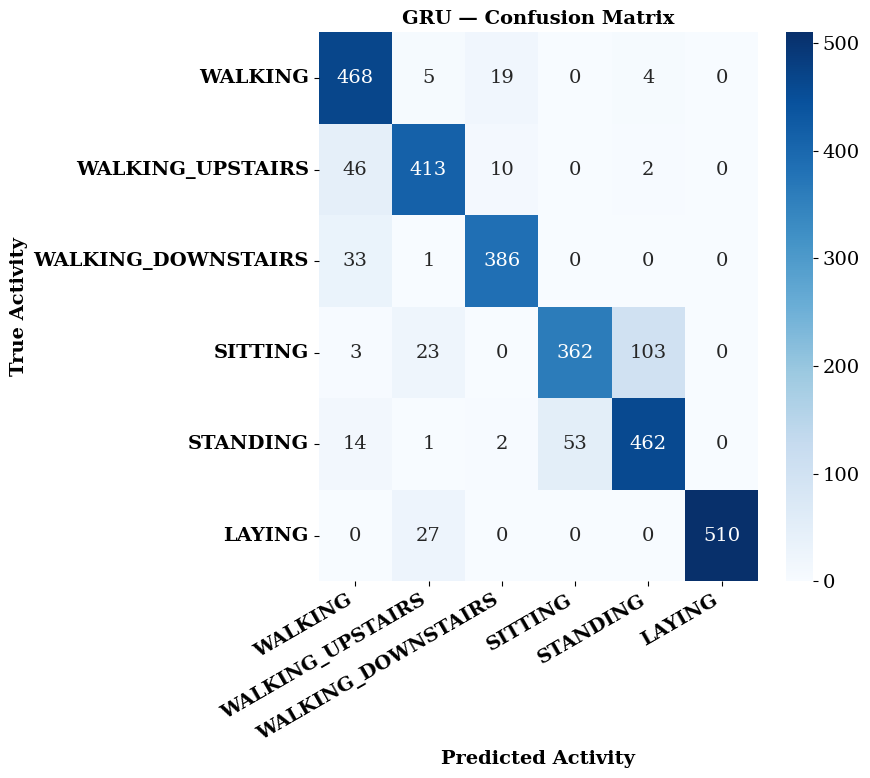


Confusion matrix saved to:
/content/experiment6/outputs/11_gru_confusion_matrix.eps

GRU EVALUATION COMPLETED


In [22]:
# ============================================================
# CELL 23 — GRU FINAL TEST EVALUATION
# ============================================================

print("=" * 60)
print("GRU — FINAL TEST EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# Predict on official untouched UCI test set
# ------------------------------------------------------------

gru_probabilities = gru_model.predict(
    X_test_full,
    batch_size=BATCH_SIZE,
    verbose=1
)

gru_predictions = np.argmax(
    gru_probabilities,
    axis=1
)

# ------------------------------------------------------------
# Calculate required metrics
# ------------------------------------------------------------

gru_test_accuracy = accuracy_score(
    y_test_full,
    gru_predictions
)

gru_test_precision = precision_score(
    y_test_full,
    gru_predictions,
    average="macro",
    zero_division=0
)

gru_test_recall = recall_score(
    y_test_full,
    gru_predictions,
    average="macro",
    zero_division=0
)

gru_test_f1 = f1_score(
    y_test_full,
    gru_predictions,
    average="macro",
    zero_division=0
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

gru_cm = confusion_matrix(
    y_test_full,
    gru_predictions
)

# ------------------------------------------------------------
# Print metrics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GRU TEST METRICS")
print("=" * 60)

print(
    f"\nAccuracy        : "
    f"{gru_test_accuracy:.4f} "
    f"({gru_test_accuracy * 100:.2f}%)"
)

print(
    f"Macro Precision : "
    f"{gru_test_precision:.4f}"
)

print(
    f"Macro Recall    : "
    f"{gru_test_recall:.4f}"
)

print(
    f"Macro F1        : "
    f"{gru_test_f1:.4f}"
)

print(
    f"\nTrainable Params: "
    f"{gru_model.count_params():,}"
)

print(
    f"Training Time   : "
    f"{gru_training_time:.2f} seconds"
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test_full,
        gru_predictions,
        target_names=activity_names,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

gru_cm_df = pd.DataFrame(
    gru_cm,
    index=activity_names,
    columns=activity_names
)

print(gru_cm_df)

# ------------------------------------------------------------
# Save GRU results
# ------------------------------------------------------------

gru_results = {
    "model": "GRU",
    "parameters": int(
        gru_model.count_params()
    ),
    "training_time_seconds": float(
        gru_training_time
    ),
    "test_accuracy": float(
        gru_test_accuracy
    ),
    "macro_precision": float(
        gru_test_precision
    ),
    "macro_recall": float(
        gru_test_recall
    ),
    "macro_f1": float(
        gru_test_f1
    )
}

with open(
    OUTPUT_DIR / "gru_results.json",
    "w"
) as f:
    json.dump(
        gru_results,
        f,
        indent=4
    )

np.save(
    OUTPUT_DIR / "gru_confusion_matrix.npy",
    gru_cm
)

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 8)
)

sns.heatmap(
    gru_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_names,
    yticklabels=activity_names,
    ax=ax
)

ax.set_title(
    "GRU — Confusion Matrix",
    fontweight="bold"
)

ax.set_xlabel(
    "Predicted Activity",
    fontweight="bold"
)

ax.set_ylabel(
    "True Activity",
    fontweight="bold"
)

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
    fontweight="bold"
)

plt.setp(
    ax.get_yticklabels(),
    rotation=0,
    fontweight="bold"
)

fig.tight_layout()

gru_cm_path = (
    OUTPUT_DIR /
    "11_gru_confusion_matrix.eps"
)

fig.savefig(
    gru_cm_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("\nConfusion matrix saved to:")
print(gru_cm_path)

print("\n" + "=" * 60)
print("GRU EVALUATION COMPLETED")
print("=" * 60)

In [23]:
# ============================================================
# CELL 24 — RNN / LSTM / GRU COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame({
    "Model": [
        "Vanilla RNN",
        "LSTM",
        "GRU"
    ],

    "Trainable Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ],

    "Training Time (s)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ],

    "Test Accuracy": [
        rnn_test_accuracy,
        lstm_test_accuracy,
        gru_test_accuracy
    ],

    "Macro Precision": [
        rnn_test_precision,
        lstm_test_precision,
        gru_test_precision
    ],

    "Macro Recall": [
        rnn_test_recall,
        lstm_test_recall,
        gru_test_recall
    ],

    "Macro F1": [
        rnn_test_f1,
        lstm_test_f1,
        gru_test_f1
    ]
})

# ------------------------------------------------------------
# Display report-friendly table
# ------------------------------------------------------------

comparison_display = comparison_df.copy()

for col in [
    "Test Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]:
    comparison_display[col] = (
        comparison_display[col] * 100
    )

print("=" * 100)
print("RNN / LSTM / GRU COMPARISON")
print("=" * 100)

display(
    comparison_display.round(2)
)

# ------------------------------------------------------------
# Save exact values
# ------------------------------------------------------------

comparison_df.to_csv(
    OUTPUT_DIR / "rnn_lstm_gru_comparison.csv",
    index=False
)

comparison_df.to_json(
    OUTPUT_DIR / "rnn_lstm_gru_comparison.json",
    orient="records",
    indent=4
)

print("\nExact comparison results saved.")

RNN / LSTM / GRU COMPARISON


,Model,Trainable Parameters,Training Time (s),Test Accuracy,Macro Precision,Macro Recall,Macro F1
0,Vanilla RNN,1974,21.72,70.11,69.47,68.90,68.64
1,LSTM,6006,14.44,88.26,88.37,88.17,87.98
2,GRU,4758,17.75,88.26,88.59,88.25,88.24



Exact comparison results saved.


GENERATING MODEL COMPARISON PLOTS


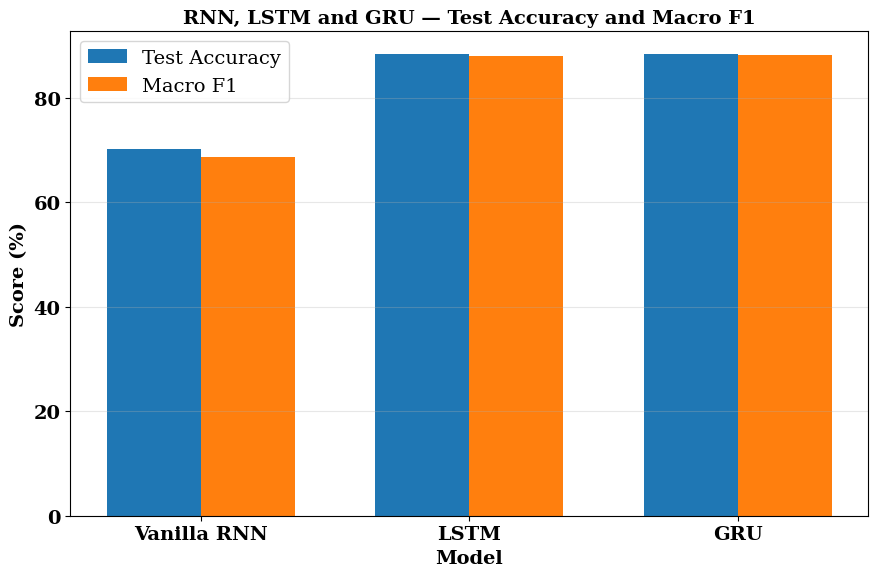

Saved: /content/experiment6/outputs/12_model_accuracy_f1_comparison.eps


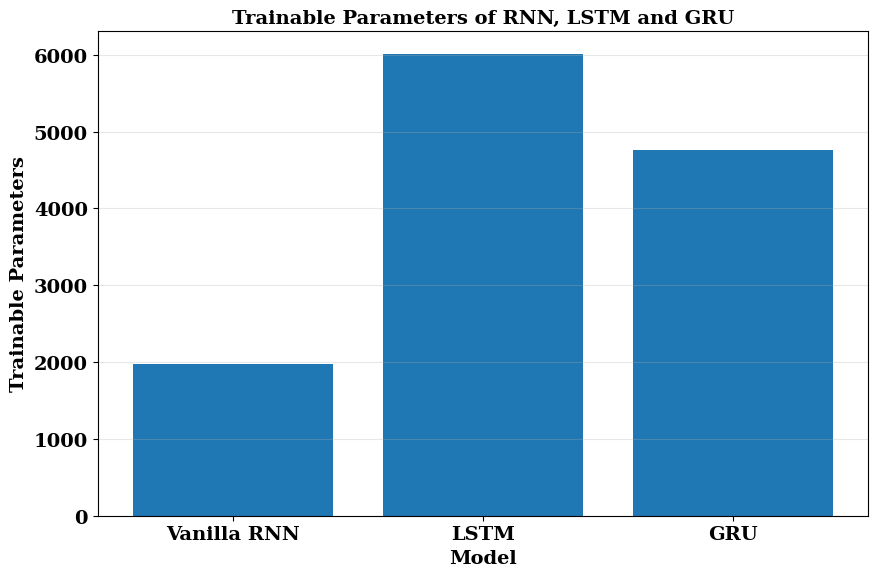

Saved: /content/experiment6/outputs/13_model_parameters_comparison.eps


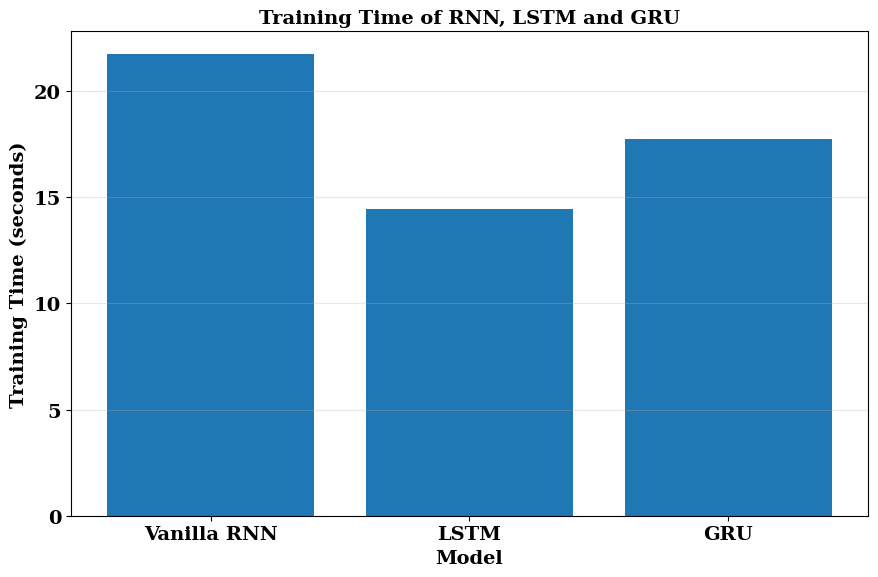

Saved: /content/experiment6/outputs/14_model_training_time_comparison.eps

ALL MODEL COMPARISON PLOTS GENERATED


In [24]:
# ============================================================
# CELL 25 — MODEL COMPARISON PLOTS
# ============================================================

print("=" * 60)
print("GENERATING MODEL COMPARISON PLOTS")
print("=" * 60)

models = comparison_df["Model"].tolist()

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def format_comparison_axis(ax):
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.grid(
        axis="y",
        alpha=0.3
    )


# ============================================================
# 1. TEST ACCURACY AND MACRO F1
# ============================================================

x = np.arange(len(models))
width = 0.35

accuracy_values = (
    comparison_df["Test Accuracy"].values * 100
)

f1_values = (
    comparison_df["Macro F1"].values * 100
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.bar(
    x - width / 2,
    accuracy_values,
    width,
    label="Test Accuracy"
)

ax.bar(
    x + width / 2,
    f1_values,
    width,
    label="Macro F1"
)

ax.set_xlabel(
    "Model",
    fontweight="bold"
)

ax.set_ylabel(
    "Score (%)",
    fontweight="bold"
)

ax.set_title(
    "RNN, LSTM and GRU — Test Accuracy and Macro F1",
    fontweight="bold"
)

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.legend()

format_comparison_axis(ax)

fig.tight_layout()

path = (
    OUTPUT_DIR /
    "12_model_accuracy_f1_comparison.eps"
)

fig.savefig(
    path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"Saved: {path}")


# ============================================================
# 2. TRAINABLE PARAMETERS
# ============================================================

parameter_values = (
    comparison_df["Trainable Parameters"].values
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.bar(
    models,
    parameter_values
)

ax.set_xlabel(
    "Model",
    fontweight="bold"
)

ax.set_ylabel(
    "Trainable Parameters",
    fontweight="bold"
)

ax.set_title(
    "Trainable Parameters of RNN, LSTM and GRU",
    fontweight="bold"
)

format_comparison_axis(ax)

fig.tight_layout()

path = (
    OUTPUT_DIR /
    "13_model_parameters_comparison.eps"
)

fig.savefig(
    path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"Saved: {path}")


# ============================================================
# 3. TRAINING TIME
# ============================================================

training_time_values = (
    comparison_df["Training Time (s)"].values
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.bar(
    models,
    training_time_values
)

ax.set_xlabel(
    "Model",
    fontweight="bold"
)

ax.set_ylabel(
    "Training Time (seconds)",
    fontweight="bold"
)

ax.set_title(
    "Training Time of RNN, LSTM and GRU",
    fontweight="bold"
)

format_comparison_axis(ax)

fig.tight_layout()

path = (
    OUTPUT_DIR /
    "14_model_training_time_comparison.eps"
)

fig.savefig(
    path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"Saved: {path}")


# ============================================================
# COMPLETION
# ============================================================

print("\n" + "=" * 60)
print("ALL MODEL COMPARISON PLOTS GENERATED")
print("=" * 60)

In [25]:
# ============================================================
# CELL 26 — PREPARE SEQUENCE-LENGTH DATASETS
# ============================================================

SEQUENCE_LENGTHS = [32, 64, 128]

sequence_data = {}

print("=" * 60)
print("PREPARING SEQUENCE-LENGTH DATASETS")
print("=" * 60)

for T in SEQUENCE_LENGTHS:

    sequence_data[T] = {
        "X_train": X_train[:, :T, :],
        "X_val": X_val[:, :T, :],
        "X_test": X_test_full[:, :T, :]
    }

    print(f"\nSequence Length T = {T}")
    print("-" * 40)

    print(
        "Training   :",
        sequence_data[T]["X_train"].shape
    )

    print(
        "Validation :",
        sequence_data[T]["X_val"].shape
    )

    print(
        "Test       :",
        sequence_data[T]["X_test"].shape
    )

print("\n" + "=" * 60)
print("ALL SEQUENCE-LENGTH DATASETS READY")
print("=" * 60)

PREPARING SEQUENCE-LENGTH DATASETS

Sequence Length T = 32
----------------------------------------
Training   : (1260, 32, 9)
Validation : (270, 32, 9)
Test       : (2947, 32, 9)

Sequence Length T = 64
----------------------------------------
Training   : (1260, 64, 9)
Validation : (270, 64, 9)
Test       : (2947, 64, 9)

Sequence Length T = 128
----------------------------------------
Training   : (1260, 128, 9)
Validation : (270, 128, 9)
Test       : (2947, 128, 9)

ALL SEQUENCE-LENGTH DATASETS READY


In [26]:
# ============================================================
# CELL 27 — CORRECTED SEQUENCE-LENGTH EXPERIMENT FUNCTION
# ============================================================

def build_sequence_model(model_type, sequence_length):

    model = keras.Sequential([
        layers.Input(
            shape=(sequence_length, 9),
            name="input"
        )
    ])

    if model_type == "RNN":
        model.add(
            layers.SimpleRNN(
                RNN_UNITS,
                activation="tanh",
                name="simple_rnn"
            )
        )

    elif model_type == "LSTM":
        model.add(
            layers.LSTM(
                RNN_UNITS,
                activation="tanh",
                name="lstm_32"
            )
        )

    elif model_type == "GRU":
        model.add(
            layers.GRU(
                RNN_UNITS,
                activation="tanh",
                name="gru_32"
            )
        )

    else:
        raise ValueError(
            "model_type must be RNN, LSTM or GRU"
        )

    model.add(
        layers.Dropout(
            DROPOUT_RATE,
            name="dropout"
        )
    )

    model.add(
        layers.Dense(
            DENSE_UNITS,
            activation="relu",
            name="dense_16"
        )
    )

    model.add(
        layers.Dense(
            N_CLASSES,
            activation="softmax",
            name="output"
        )
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def run_sequence_experiment(model_type, sequence_length):

    print("\n" + "=" * 70)
    print(
        f"{model_type} — SEQUENCE LENGTH T = {sequence_length}"
    )
    print("=" * 70)

    tf.keras.backend.clear_session()
    gc.collect()

    Xtr = sequence_data[sequence_length]["X_train"]
    Xv = sequence_data[sequence_length]["X_val"]
    Xt = sequence_data[sequence_length]["X_test"]

    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    model = build_sequence_model(
        model_type,
        sequence_length
    )

    parameter_count = int(
        model.count_params()
    )

    print(
        f"Trainable parameters: "
        f"{parameter_count:,}"
    )

    # --------------------------------------------------------
    # Checkpoint
    # --------------------------------------------------------

    checkpoint_path = (
        MODEL_DIR /
        f"sequence_{model_type.lower()}_T{sequence_length}.keras"
    )

    if checkpoint_path.exists():
        checkpoint_path.unlink()

    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=0
    )

    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        mode="min",
        restore_best_weights=True,
        verbose=0
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        Xtr,
        y_train,
        validation_data=(Xv, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            checkpoint,
            early_stopping
        ],
        verbose=0
    )

    training_time = float(
        time.time() - start_time
    )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    probabilities = model.predict(
        Xt,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    test_f1 = float(
        f1_score(
            y_test_full,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    test_accuracy = float(
        accuracy_score(
            y_test_full,
            predictions
        )
    )

    test_precision = float(
        precision_score(
            y_test_full,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    test_recall = float(
        recall_score(
            y_test_full,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    best_epoch = int(
        np.argmin(
            history.history["val_loss"]
        ) + 1
    )

    best_val_loss = float(
        min(history.history["val_loss"])
    )

    best_val_accuracy = float(
        max(history.history["val_accuracy"])
    )

    epochs_completed = int(
        len(history.history["loss"])
    )

    result = {
        "Model": model_type,
        "Sequence Length": int(sequence_length),
        "Test Accuracy": test_accuracy,
        "Macro Precision": test_precision,
        "Macro Recall": test_recall,
        "Macro F1": test_f1,
        "Trainable Parameters": parameter_count,
        "Training Time (s)": training_time,
        "Epochs": epochs_completed,
        "Best Epoch": best_epoch,
        "Best Val Loss": best_val_loss,
        "Best Val Accuracy": best_val_accuracy
    }

    # --------------------------------------------------------
    # Display results
    # --------------------------------------------------------

    print(
        f"\nTest Accuracy : "
        f"{test_accuracy * 100:.2f}%"
    )

    print(
        f"Macro F1      : "
        f"{test_f1:.4f}"
    )

    print(
        f"Training Time : "
        f"{training_time:.2f} s"
    )

    print(
        f"Best Epoch    : "
        f"{best_epoch}"
    )

    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    result_path = (
        OUTPUT_DIR /
        f"sequence_{model_type.lower()}_T{sequence_length}.json"
    )

    with open(result_path, "w") as f:
        json.dump(
            result,
            f,
            indent=4
        )

    print(
        f"\nResult saved: {result_path}"
    )

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model
    del probabilities
    del predictions

    tf.keras.backend.clear_session()
    gc.collect()

    return result

In [27]:
# ============================================================
# CELL 28A — RNN, T = 32
# ============================================================

rnn_t32_result = run_sequence_experiment(
    model_type="RNN",
    sequence_length=32
)

print("\nRNN T=32 completed.")


RNN — SEQUENCE LENGTH T = 32
Trainable parameters: 1,974

Test Accuracy : 68.85%
Macro F1      : 0.6822
Training Time : 16.23 s
Best Epoch    : 30

Result saved: /content/experiment6/outputs/sequence_rnn_T32.json

RNN T=32 completed.


In [28]:
# ============================================================
# CELL 28B — RNN, T = 64
# ============================================================

rnn_t64_result = run_sequence_experiment(
    model_type="RNN",
    sequence_length=64
)

print("\nRNN T=64 completed.")


RNN — SEQUENCE LENGTH T = 64
Trainable parameters: 1,974

Test Accuracy : 69.46%
Macro F1      : 0.6847
Training Time : 18.59 s
Best Epoch    : 29

Result saved: /content/experiment6/outputs/sequence_rnn_T64.json

RNN T=64 completed.


In [29]:
# ============================================================
# CELL 28C — LSTM, T = 32
# ============================================================

lstm_t32_result = run_sequence_experiment(
    model_type="LSTM",
    sequence_length=32
)

print("\nLSTM T=32 completed.")


LSTM — SEQUENCE LENGTH T = 32
Trainable parameters: 6,006

Test Accuracy : 85.34%
Macro F1      : 0.8525
Training Time : 13.45 s
Best Epoch    : 22

Result saved: /content/experiment6/outputs/sequence_lstm_T32.json

LSTM T=32 completed.


In [30]:
# ============================================================
# CELL 28D — LSTM, T = 64
# ============================================================

lstm_t64_result = run_sequence_experiment(
    model_type="LSTM",
    sequence_length=64
)

print("\nLSTM T=64 completed.")


LSTM — SEQUENCE LENGTH T = 64
Trainable parameters: 6,006

Test Accuracy : 87.31%
Macro F1      : 0.8725
Training Time : 12.35 s
Best Epoch    : 16

Result saved: /content/experiment6/outputs/sequence_lstm_T64.json

LSTM T=64 completed.


In [31]:
# ============================================================
# CELL 28E — GRU, T = 32
# ============================================================

gru_t32_result = run_sequence_experiment(
    model_type="GRU",
    sequence_length=32
)

print("\nGRU T=32 completed.")


GRU — SEQUENCE LENGTH T = 32
Trainable parameters: 4,758

Test Accuracy : 85.04%
Macro F1      : 0.8469
Training Time : 13.91 s
Best Epoch    : 28

Result saved: /content/experiment6/outputs/sequence_gru_T32.json

GRU T=32 completed.


In [32]:
# ============================================================
# CELL 28F — GRU, T = 64
# ============================================================

gru_t64_result = run_sequence_experiment(
    model_type="GRU",
    sequence_length=64
)

print("\nGRU T=64 completed.")


GRU — SEQUENCE LENGTH T = 64
Trainable parameters: 4,758

Test Accuracy : 89.24%
Macro F1      : 0.8908
Training Time : 15.57 s
Best Epoch    : 29

Result saved: /content/experiment6/outputs/sequence_gru_T64.json

GRU T=64 completed.


SEQUENCE LENGTH vs TEST MACRO F1


,Sequence Length,RNN F1,LSTM F1,GRU F1
0,32,0.6822,0.8525,0.8469
1,64,0.6847,0.8725,0.8908
2,128,0.6864,0.8798,0.8824



Results saved to:
/content/experiment6/outputs/sequence_length_f1_results.csv


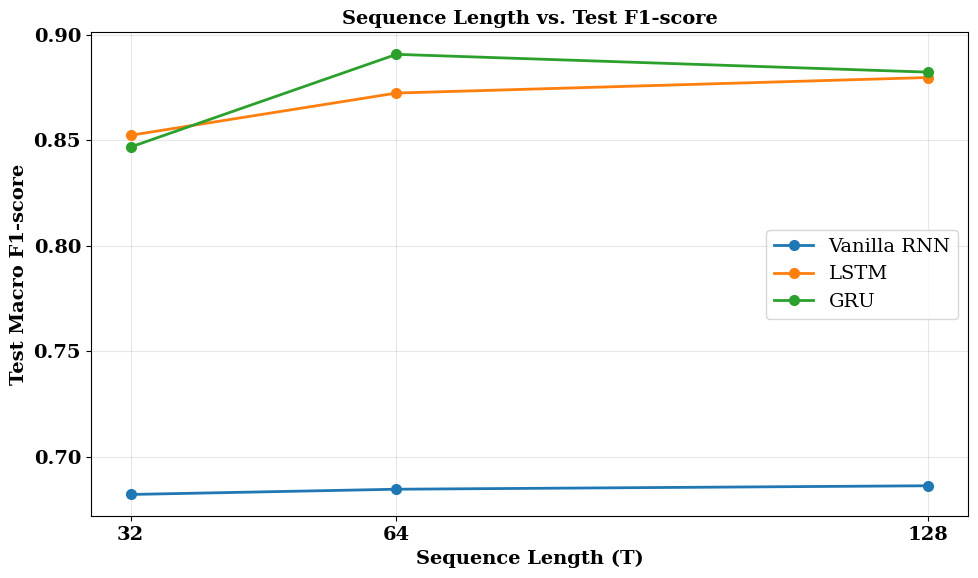


Plot 6 saved to:
/content/experiment6/outputs/15_sequence_length_vs_test_f1.eps

SEQUENCE-LENGTH EXPERIMENT COMPLETED


In [33]:
# ============================================================
# CELL 29 — SEQUENCE LENGTH RESULTS + PLOT
# ============================================================

print("=" * 70)
print("SEQUENCE LENGTH vs TEST MACRO F1")
print("=" * 70)

# ------------------------------------------------------------
# Build results table from actual completed experiments
# ------------------------------------------------------------

sequence_results = pd.DataFrame([
    {
        "Sequence Length": 32,
        "RNN F1": rnn_t32_result["Macro F1"],
        "LSTM F1": lstm_t32_result["Macro F1"],
        "GRU F1": gru_t32_result["Macro F1"]
    },
    {
        "Sequence Length": 64,
        "RNN F1": rnn_t64_result["Macro F1"],
        "LSTM F1": lstm_t64_result["Macro F1"],
        "GRU F1": gru_t64_result["Macro F1"]
    },
    {
        "Sequence Length": 128,
        "RNN F1": rnn_test_f1,
        "LSTM F1": lstm_test_f1,
        "GRU F1": gru_test_f1
    }
])

# ------------------------------------------------------------
# Display table
# ------------------------------------------------------------

display(
    sequence_results.round(4)
)

# ------------------------------------------------------------
# Save exact table
# ------------------------------------------------------------

sequence_results.to_csv(
    OUTPUT_DIR / "sequence_length_f1_results.csv",
    index=False
)

sequence_results.to_json(
    OUTPUT_DIR / "sequence_length_f1_results.json",
    orient="records",
    indent=4
)

print(
    "\nResults saved to:"
)
print(
    OUTPUT_DIR /
    "sequence_length_f1_results.csv"
)


# ============================================================
# PLOT 6 — SEQUENCE LENGTH vs TEST F1-SCORE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    sequence_results["Sequence Length"],
    sequence_results["RNN F1"],
    marker="o",
    linewidth=2,
    markersize=7,
    label="Vanilla RNN"
)

ax.plot(
    sequence_results["Sequence Length"],
    sequence_results["LSTM F1"],
    marker="o",
    linewidth=2,
    markersize=7,
    label="LSTM"
)

ax.plot(
    sequence_results["Sequence Length"],
    sequence_results["GRU F1"],
    marker="o",
    linewidth=2,
    markersize=7,
    label="GRU"
)

ax.set_xlabel(
    "Sequence Length (T)",
    fontweight="bold"
)

ax.set_ylabel(
    "Test Macro F1-score",
    fontweight="bold"
)

ax.set_title(
    "Sequence Length vs. Test F1-score",
    fontweight="bold"
)

ax.set_xticks(
    [32, 64, 128]
)

ax.legend()

# Bold tick labels
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.grid(
    True,
    alpha=0.3
)

fig.tight_layout()

plot6_path = (
    OUTPUT_DIR /
    "15_sequence_length_vs_test_f1.eps"
)

fig.savefig(
    plot6_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    f"\nPlot 6 saved to:\n{plot6_path}"
)

print("\n" + "=" * 70)
print("SEQUENCE-LENGTH EXPERIMENT COMPLETED")
print("=" * 70)

In [34]:
# ============================================================
# CELL 30 — VIDEO EXPERIMENT SETUP
# ============================================================

import os
import gc
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("VIDEO UNDERSTANDING EXPERIMENT — ENVIRONMENT CHECK")
print("=" * 70)

print("TensorFlow version :", tf.__version__)
print("OpenCV version     :", cv2.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU available      :", gpus)
    print("GPU count          :", len(gpus))
else:
    print("GPU available      : NO")

# Video directories
VIDEO_DIR = BASE_DIR / "video_data"
VIDEO_OUTPUT_DIR = OUTPUT_DIR / "video"

VIDEO_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\nVideo data directory:")
print(VIDEO_DIR)

print("\nVideo output directory:")
print(VIDEO_OUTPUT_DIR)

print("\nSetup completed successfully.")

VIDEO UNDERSTANDING EXPERIMENT — ENVIRONMENT CHECK
TensorFlow version : 2.20.0
OpenCV version     : 5.0.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU count          : 1

Video data directory:
/content/experiment6/video_data

Video output directory:
/content/experiment6/outputs/video

Setup completed successfully.


In [35]:
# ============================================================
# CELL 31 — CHECK FOR EXISTING UCF101 DATA
# ============================================================

from pathlib import Path

print("=" * 70)
print("CHECKING FOR EXISTING UCF101 DATASET")
print("=" * 70)

# Common locations where UCF101 may already exist
possible_roots = [
    Path("/content/UCF101"),
    Path("/content/ucf101"),
    Path("/content/UCF-101"),
    Path("/content/experiment6/video_data/UCF101"),
    Path("/content/experiment6/video_data/ucf101"),
    Path("/content/drive/MyDrive/UCF101"),
    Path("/root/.keras/datasets"),
    Path("/content/.keras/datasets"),
]

found = []

for root in possible_roots:
    if root.exists():
        found.append(root)
        print(f"\nFOUND: {root}")

        # Show a few entries only
        entries = list(root.iterdir())[:10]

        for entry in entries:
            print("   ", entry.name)

if not found:
    print("\nNo existing UCF101 dataset was found in the common locations.")

print("\n" + "=" * 70)
print("CHECK COMPLETED")
print("=" * 70)

CHECKING FOR EXISTING UCF101 DATASET

No existing UCF101 dataset was found in the common locations.

CHECK COMPLETED


In [36]:
# ============================================================
# CELL 32B — CORRECTLY EXTRACT UCF101 SUBSET
# ============================================================

import os
import shutil
import tarfile
import zipfile
from pathlib import Path

from huggingface_hub import snapshot_download

print("=" * 70)
print("IDENTIFYING AND EXTRACTING UCF101 SUBSET")
print("=" * 70)

# ------------------------------------------------------------
# 1. Download / locate the Hugging Face dataset repository
# ------------------------------------------------------------

REPO_ID = "sayakpaul/ucf101-subset"

print("\nHugging Face repository:")
print(REPO_ID)

repo_dir = Path(
    snapshot_download(
        repo_id=REPO_ID,
        repo_type="dataset"
    )
)

print("\nDataset repository located at:")
print(repo_dir)

# ------------------------------------------------------------
# 2. Find the archive automatically
# ------------------------------------------------------------

archives = list(repo_dir.rglob("UCF101_subset.tar.gz"))

if not archives:
    # Try finding any tar/zip archive
    archives = (
        list(repo_dir.rglob("*.tar.gz")) +
        list(repo_dir.rglob("*.tgz")) +
        list(repo_dir.rglob("*.tar")) +
        list(repo_dir.rglob("*.zip"))
    )

if not archives:
    print("\nFiles available in repository:")

    for p in repo_dir.rglob("*"):
        if p.is_file():
            print("  ", p)

    raise FileNotFoundError(
        "Could not find the UCF101 subset archive "
        "inside the Hugging Face repository."
    )

archive_path = archives[0]

print("\nArchive found:")
print(archive_path)

print(
    "\nFile size:",
    round(archive_path.stat().st_size / (1024**2), 2),
    "MB"
)

# ------------------------------------------------------------
# 3. Inspect first few bytes
# ------------------------------------------------------------

with open(archive_path, "rb") as f:
    header = f.read(16)

print("\nFile header:", header)

# ------------------------------------------------------------
# 4. Destination directory
# ------------------------------------------------------------

UCF_EXTRACT_DIR = VIDEO_DIR / "UCF101_subset"

UCF_EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\nExtraction directory:")
print(UCF_EXTRACT_DIR)

# ------------------------------------------------------------
# 5. Determine archive format
# ------------------------------------------------------------

if header.startswith(b"\x1f\x8b"):

    print("\nDetected: GZIP/TAR archive")

    with tarfile.open(
        archive_path,
        mode="r:gz"
    ) as tar:

        tar.extractall(
            path=UCF_EXTRACT_DIR
        )

elif header.startswith(b"PK"):

    print("\nDetected: ZIP archive")

    with zipfile.ZipFile(
        archive_path,
        "r"
    ) as z:

        z.extractall(
            path=UCF_EXTRACT_DIR
        )

else:

    print("\nTrying as an uncompressed TAR archive...")

    try:

        with tarfile.open(
            archive_path,
            mode="r:"
        ) as tar:

            tar.extractall(
                path=UCF_EXTRACT_DIR
            )

        print("Successfully extracted as TAR.")

    except Exception as e:

        raise ValueError(
            f"Unknown archive format. "
            f"Header = {header}. "
            f"Extraction error = {repr(e)}"
        )

# ------------------------------------------------------------
# 6. Inspect extracted files
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EXTRACTION RESULT")
print("=" * 70)

items = list(UCF_EXTRACT_DIR.iterdir())

print(
    "Number of top-level items:",
    len(items)
)

for item in items[:20]:
    print("  ", item)

print("\nExtraction completed successfully.")

IDENTIFYING AND EXTRACTING UCF101 SUBSET

Hugging Face repository:
sayakpaul/ucf101-subset


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]


Dataset repository located at:
/root/.cache/huggingface/hub/datasets--sayakpaul--ucf101-subset/snapshots/b9984b8d2a95e4a1879e1b071e9433858d0bc24a

Archive found:
/root/.cache/huggingface/hub/datasets--sayakpaul--ucf101-subset/snapshots/b9984b8d2a95e4a1879e1b071e9433858d0bc24a/UCF101_subset.tar.gz

File size: 163.45 MB

File header: b'UCF101_subset/\x00\x00'

Extraction directory:
/content/experiment6/video_data/UCF101_subset

Trying as an uncompressed TAR archive...
Successfully extracted as TAR.

EXTRACTION RESULT
Number of top-level items: 1
   /content/experiment6/video_data/UCF101_subset/UCF101_subset

Extraction completed successfully.


In [37]:
# ============================================================
# CELL 33 — INSPECT UCF101 SUBSET
# ============================================================

from pathlib import Path
from collections import Counter

print("=" * 70)
print("UCF101 SUBSET — CLASS AND VIDEO INSPECTION")
print("=" * 70)

# Correct extracted root
UCF_ROOT = (
    VIDEO_DIR /
    "UCF101_subset" /
    "UCF101_subset"
)

print("Dataset root:")
print(UCF_ROOT)

if not UCF_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root not found: {UCF_ROOT}"
    )

# ------------------------------------------------------------
# Inspect splits
# ------------------------------------------------------------

splits = ["train", "val", "test"]

for split in splits:

    split_dir = UCF_ROOT / split

    print("\n" + "-" * 70)
    print(f"{split.upper()} SET")
    print("-" * 70)

    if not split_dir.exists():
        print("Split not found.")
        continue

    class_dirs = sorted(
        [
            d for d in split_dir.iterdir()
            if d.is_dir()
        ]
    )

    print("Number of classes:", len(class_dirs))

    total_videos = 0

    for class_dir in class_dirs:

        video_files = [
            f for f in class_dir.iterdir()
            if f.is_file()
            and f.suffix.lower() in [".avi", ".mp4", ".mov", ".mkv"]
        ]

        count = len(video_files)
        total_videos += count

        print(
            f"{class_dir.name:<30} : {count:>4} videos"
        )

    print("Total videos:", total_videos)

print("\n" + "=" * 70)
print("INSPECTION COMPLETED")
print("=" * 70)

UCF101 SUBSET — CLASS AND VIDEO INSPECTION
Dataset root:
/content/experiment6/video_data/UCF101_subset/UCF101_subset

----------------------------------------------------------------------
TRAIN SET
----------------------------------------------------------------------
Number of classes: 10
ApplyEyeMakeup                 :   30 videos
ApplyLipstick                  :   30 videos
Archery                        :   30 videos
BabyCrawling                   :   30 videos
BalanceBeam                    :   30 videos
BandMarching                   :   30 videos
BaseballPitch                  :   30 videos
Basketball                     :   30 videos
BasketballDunk                 :   30 videos
BenchPress                     :   30 videos
Total videos: 300

----------------------------------------------------------------------
VAL SET
----------------------------------------------------------------------
Number of classes: 10
ApplyEyeMakeup                 :    3 videos
ApplyLipstick         

In [38]:
# ============================================================
# CELL 34 — SELECT VIDEO CLASSES
# ============================================================

VIDEO_CLASSES = [
    "Archery",
    "Basketball",
    "BaseballPitch"
]

CLASS_TO_ID = {
    class_name: idx
    for idx, class_name in enumerate(VIDEO_CLASSES)
}

ID_TO_CLASS = {
    idx: class_name
    for class_name, idx in CLASS_TO_ID.items()
}

print("=" * 70)
print("SELECTED VIDEO CLASSES")
print("=" * 70)

for idx, class_name in ID_TO_CLASS.items():
    print(f"{idx} -> {class_name}")

print("\nClass mapping:")
print(CLASS_TO_ID)

# ------------------------------------------------------------
# Verify availability in every split
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("VIDEO COUNTS")
print("-" * 70)

video_extensions = {
    ".avi",
    ".mp4",
    ".mov",
    ".mkv"
}

video_records = []

for split in ["train", "val", "test"]:

    for class_name in VIDEO_CLASSES:

        class_dir = UCF_ROOT / split / class_name

        if not class_dir.exists():
            raise FileNotFoundError(
                f"Missing class directory: {class_dir}"
            )

        files = sorted([
            f for f in class_dir.iterdir()
            if f.is_file()
            and f.suffix.lower() in video_extensions
        ])

        print(
            f"{split:<6} | "
            f"{class_name:<20} | "
            f"{len(files):>3} videos"
        )

        for video_path in files:

            video_records.append({
                "split": split,
                "class_name": class_name,
                "label": CLASS_TO_ID[class_name],
                "path": str(video_path)
            })

video_df = pd.DataFrame(video_records)

print("\nTotal selected videos:",
      len(video_df))

print("\nVideos by split:")
print(
    video_df.groupby(
        ["split", "class_name"]
    ).size()
)

# ------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------

video_metadata_path = (
    VIDEO_OUTPUT_DIR /
    "selected_video_metadata.csv"
)

video_df.to_csv(
    video_metadata_path,
    index=False
)

print(
    f"\nMetadata saved to:\n"
    f"{video_metadata_path}"
)

print("\n" + "=" * 70)
print("VIDEO CLASS SELECTION COMPLETED")
print("=" * 70)

SELECTED VIDEO CLASSES
0 -> Archery
1 -> Basketball
2 -> BaseballPitch

Class mapping:
{'Archery': 0, 'Basketball': 1, 'BaseballPitch': 2}

----------------------------------------------------------------------
VIDEO COUNTS
----------------------------------------------------------------------
train  | Archery              |  30 videos
train  | Basketball           |  30 videos
train  | BaseballPitch        |  30 videos
val    | Archery              |   3 videos
val    | Basketball           |   3 videos
val    | BaseballPitch        |   3 videos
test   | Archery              |   7 videos
test   | Basketball           |  11 videos
test   | BaseballPitch        |  10 videos

Total selected videos: 127

Videos by split:
split  class_name   
test   Archery           7
       BaseballPitch    10
       Basketball       11
train  Archery          30
       BaseballPitch    30
       Basketball       30
val    Archery           3
       BaseballPitch     3
       Basketball        3
dtype: i

In [39]:
# ============================================================
# CELL 35 — VERIFY VIDEO READABILITY
# ============================================================

import cv2
import pandas as pd
import numpy as np

print("=" * 70)
print("VERIFYING VIDEO FILES")
print("=" * 70)

video_check_results = []

for _, row in video_df.iterrows():

    video_path = row["path"]

    cap = cv2.VideoCapture(video_path)

    opened = cap.isOpened()

    if opened:
        frame_count = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        fps = float(
            cap.get(cv2.CAP_PROP_FPS)
        )

        width = int(
            cap.get(cv2.CAP_PROP_FRAME_WIDTH)
        )

        height = int(
            cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
        )

        duration = (
            frame_count / fps
            if fps > 0
            else 0
        )

        # Attempt to read the first frame
        ret, frame = cap.read()

    else:
        frame_count = 0
        fps = 0
        width = 0
        height = 0
        duration = 0
        ret = False

    cap.release()

    video_check_results.append({
        "split": row["split"],
        "class_name": row["class_name"],
        "path": video_path,
        "opened": opened,
        "first_frame_read": ret,
        "frame_count": frame_count,
        "fps": fps,
        "width": width,
        "height": height,
        "duration_seconds": duration
    })

video_check_df = pd.DataFrame(
    video_check_results
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

total_videos = len(video_check_df)

readable_videos = int(
    (
        video_check_df["opened"]
        & video_check_df["first_frame_read"]
    ).sum()
)

invalid_videos = (
    total_videos - readable_videos
)

print(
    f"\nTotal videos checked : {total_videos}"
)

print(
    f"Readable videos      : {readable_videos}"
)

print(
    f"Unreadable videos    : {invalid_videos}"
)

# ------------------------------------------------------------
# Frame statistics
# ------------------------------------------------------------

valid_frames = video_check_df.loc[
    video_check_df["first_frame_read"],
    "frame_count"
]

print("\nFrame-count statistics:")

print(
    valid_frames.describe()
)

print("\nFPS statistics:")

print(
    video_check_df.loc[
        video_check_df["first_frame_read"],
        "fps"
    ].describe()
)

# ------------------------------------------------------------
# Display problematic videos
# ------------------------------------------------------------

problematic = video_check_df[
    ~(
        video_check_df["opened"]
        & video_check_df["first_frame_read"]
    )
]

if len(problematic) > 0:

    print("\nProblematic videos:")

    display(problematic)

else:

    print(
        "\nAll selected videos are readable."
    )

# ------------------------------------------------------------
# Save verification results
# ------------------------------------------------------------

verification_path = (
    VIDEO_OUTPUT_DIR /
    "video_readability_check.csv"
)

video_check_df.to_csv(
    verification_path,
    index=False
)

print(
    f"\nVerification results saved to:\n"
    f"{verification_path}"
)

print("\n" + "=" * 70)
print("VIDEO VERIFICATION COMPLETED")
print("=" * 70)

VERIFYING VIDEO FILES

Total videos checked : 127
Readable videos      : 127
Unreadable videos    : 0

Frame-count statistics:
count    127.000000
mean     136.842520
std       75.630936
min       51.000000
25%       88.000000
50%      118.000000
75%      158.500000
max      518.000000
Name: frame_count, dtype: float64

FPS statistics:
count    127.000000
mean      28.404666
std        2.317723
min       25.000000
25%       25.000000
50%       29.970030
75%       29.970030
max       29.970030
Name: fps, dtype: float64

All selected videos are readable.

Verification results saved to:
/content/experiment6/outputs/video/video_readability_check.csv

VIDEO VERIFICATION COMPLETED


In [40]:
# ============================================================
# CELL 36 — FINAL ROBUST UNIFORM FRAME SAMPLING
# ============================================================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NUM_FRAMES = 10
FRAME_SIZE = (224, 224)

print("=" * 70)
print("FINAL ROBUST UNIFORM FRAME SAMPLING")
print("=" * 70)


def get_decodable_frame_count(video_path):
    """
    Count the frames that can actually be decoded by OpenCV.
    This avoids relying on potentially inaccurate AVI metadata.
    """

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(
            f"Could not open video: {video_path}"
        )

    count = 0

    while True:

        ret, _ = cap.read()

        if not ret:
            break

        count += 1

    cap.release()

    return count


def sample_video_frames(
    video_path,
    num_frames=10,
    frame_size=(224, 224)
):
    """
    Uniformly sample frames using the ACTUAL number of
    decodable frames.

    Returns:
        frames:
            (num_frames, height, width, 3)
    """

    video_path = str(video_path)

    # --------------------------------------------------------
    # PASS 1 — Count actual decodable frames
    # --------------------------------------------------------

    actual_frame_count = get_decodable_frame_count(
        video_path
    )

    if actual_frame_count < num_frames:
        raise ValueError(
            f"Video contains only "
            f"{actual_frame_count} decodable frames."
        )

    # --------------------------------------------------------
    # Determine 10 uniformly spaced positions
    # --------------------------------------------------------

    frame_indices = np.linspace(
        0,
        actual_frame_count - 1,
        num_frames,
        dtype=int
    )

    target_indices = set(
        int(i) for i in frame_indices
    )

    # --------------------------------------------------------
    # PASS 2 — Decode and retain target frames
    # --------------------------------------------------------

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(
            f"Could not reopen video: {video_path}"
        )

    frames_dict = {}

    current_index = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if current_index in target_indices:

            # BGR → RGB
            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            # Resize
            frame = cv2.resize(
                frame,
                frame_size,
                interpolation=cv2.INTER_AREA
            )

            frames_dict[current_index] = frame

        current_index += 1

    cap.release()

    # --------------------------------------------------------
    # Verify
    # --------------------------------------------------------

    missing_indices = [
        int(idx)
        for idx in frame_indices
        if int(idx) not in frames_dict
    ]

    if missing_indices:

        raise ValueError(
            f"Missing sampled frames "
            f"{missing_indices}\n"
            f"Video: {video_path}\n"
            f"Actual decoded frames: "
            f"{actual_frame_count}"
        )

    # Restore chronological order
    frames = np.stack(
        [
            frames_dict[int(idx)]
            for idx in frame_indices
        ],
        axis=0
    )

    return frames.astype(np.uint8)


# ============================================================
# TEST ONE VIDEO FROM EACH CLASS
# ============================================================

sampled_examples = {}

for class_name in VIDEO_CLASSES:

    example_row = video_df[
        (video_df["split"] == "train")
        &
        (video_df["class_name"] == class_name)
    ].iloc[0]

    video_path = example_row["path"]

    actual_count = get_decodable_frame_count(
        video_path
    )

    frames = sample_video_frames(
        video_path,
        num_frames=NUM_FRAMES,
        frame_size=FRAME_SIZE
    )

    sampled_examples[class_name] = {
        "path": video_path,
        "frames": frames,
        "actual_frame_count": actual_count
    }

    print(
        f"{class_name:<20} | "
        f"Actual frames: {actual_count:>4} | "
        f"Sampled shape: {frames.shape}"
    )


print("\nExpected sampled shape:")
print("(10, 224, 224, 3)")

print("\n" + "=" * 70)
print("FRAME SAMPLING TEST COMPLETED")
print("=" * 70)


FINAL ROBUST UNIFORM FRAME SAMPLING
Archery              | Actual frames:  125 | Sampled shape: (10, 224, 224, 3)
Basketball           | Actual frames:  141 | Sampled shape: (10, 224, 224, 3)
BaseballPitch        | Actual frames:   93 | Sampled shape: (10, 224, 224, 3)

Expected sampled shape:
(10, 224, 224, 3)

FRAME SAMPLING TEST COMPLETED


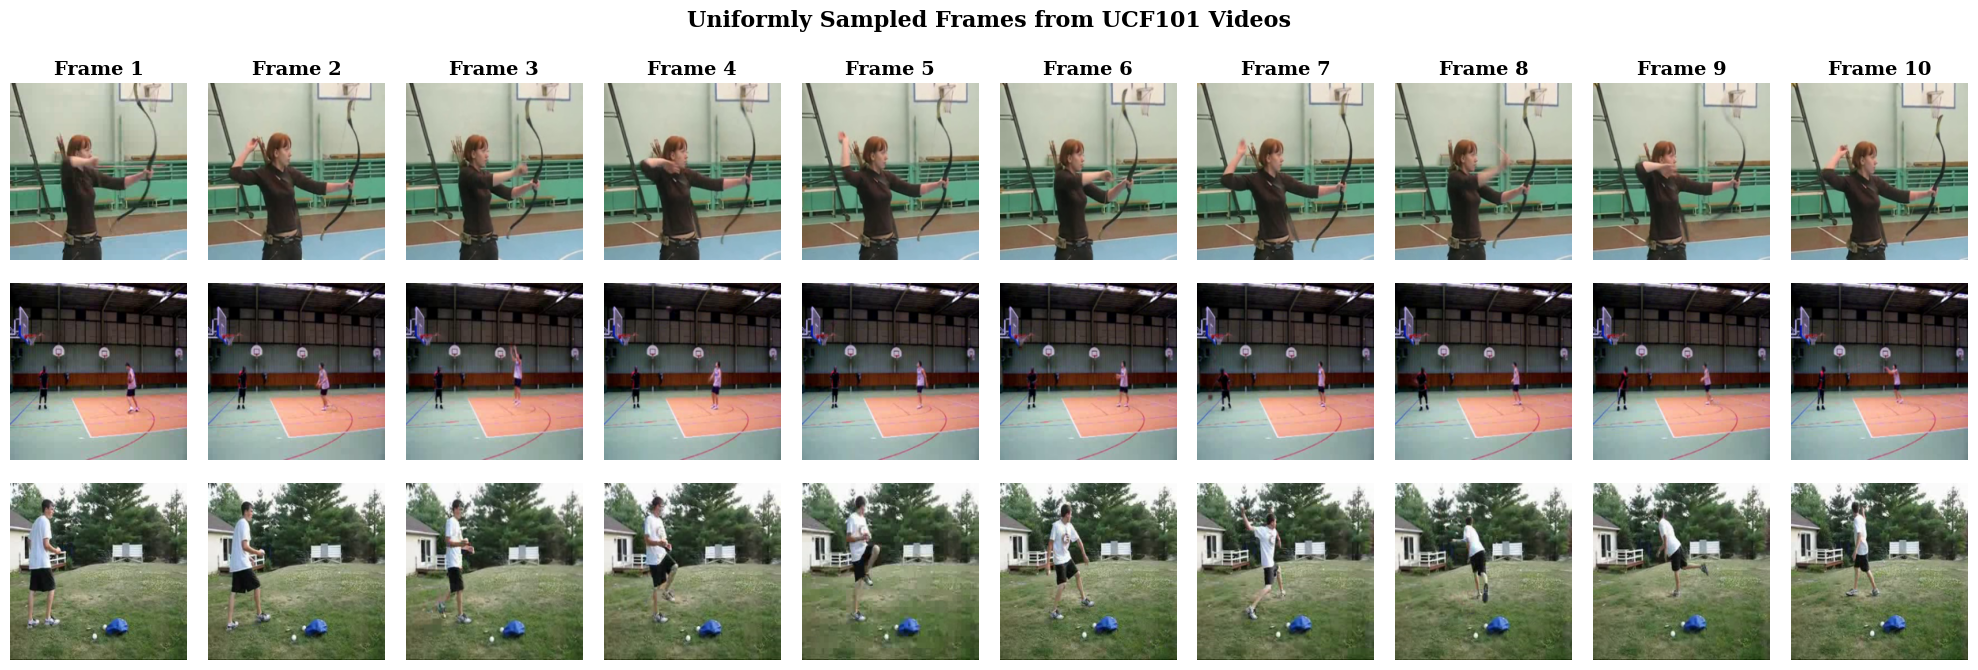

Sample-frame visualization saved to:
/content/experiment6/outputs/video/16_video_sample_frames.eps


In [41]:
# ============================================================
# CELL 37 — VIDEO SAMPLE FRAMES VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    nrows=len(VIDEO_CLASSES),
    ncols=NUM_FRAMES,
    figsize=(20, 7)
)

for row_idx, class_name in enumerate(VIDEO_CLASSES):

    frames = sampled_examples[class_name]["frames"]

    for frame_idx in range(NUM_FRAMES):

        ax = axes[row_idx, frame_idx]

        ax.imshow(frames[frame_idx])
        ax.axis("off")

        if row_idx == 0:
            ax.set_title(
                f"Frame {frame_idx + 1}",
                fontweight="bold"
            )

    axes[row_idx, 0].set_ylabel(
        class_name,
        fontsize=14,
        fontweight="bold"
    )

fig.suptitle(
    "Uniformly Sampled Frames from UCF101 Videos",
    fontsize=16,
    fontweight="bold"
)

fig.tight_layout()

sample_frames_path = (
    VIDEO_OUTPUT_DIR /
    "16_video_sample_frames.eps"
)

fig.savefig(
    sample_frames_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    f"Sample-frame visualization saved to:\n"
    f"{sample_frames_path}"
)

In [42]:
# ============================================================
# CELL 38 — FROZEN MOBILENETV2 FEATURE EXTRACTOR
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("=" * 70)
print("LOADING FROZEN MOBILENETV2")
print("=" * 70)

# ------------------------------------------------------------
# Load ImageNet-pretrained MobileNetV2
# ------------------------------------------------------------

cnn_feature_extractor = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

# Freeze all CNN layers
cnn_feature_extractor.trainable = False

FEATURE_DIM = cnn_feature_extractor.output_shape[-1]

print("Input shape       :", cnn_feature_extractor.input_shape)
print("Output shape      :", cnn_feature_extractor.output_shape)
print("Feature dimension :", FEATURE_DIM)
print(
    "Trainable params  :",
    cnn_feature_extractor.count_params()
)

print(
    "\nCNN trainable:",
    cnn_feature_extractor.trainable
)

print("\n" + "=" * 70)
print("MOBILENETV2 READY")
print("=" * 70)

LOADING FROZEN MOBILENETV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Input shape       : (None, 224, 224, 3)
Output shape      : (None, 1280)
Feature dimension : 1280
Trainable params  : 2257984

CNN trainable: False

MOBILENETV2 READY


In [43]:
# ============================================================
# CELL 39 — EXTRACT AND CACHE MOBILENETV2 FEATURES
# ============================================================

import gc
import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 70)
print("EXTRACTING MOBILENETV2 FEATURES")
print("=" * 70)

FEATURE_CACHE_DIR = (
    CACHE_DIR / "video_mobilenetv2_features"
)

FEATURE_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Feature cache:")
print(FEATURE_CACHE_DIR)

# ------------------------------------------------------------
# Feature extraction function
# ------------------------------------------------------------

def extract_video_features(
    video_path,
    feature_extractor,
    num_frames=10,
    frame_size=(224, 224)
):
    """
    Sample 10 frames and extract MobileNetV2 features.

    Returns:
        features:
            Shape = (10, 1280)
    """

    frames = sample_video_frames(
        video_path,
        num_frames=num_frames,
        frame_size=frame_size
    )

    # Convert uint8 -> float32
    frames_float = frames.astype(
        np.float32
    )

    # MobileNetV2 preprocessing
    frames_preprocessed = preprocess_input(
        frames_float
    )

    # Extract CNN features
    features = feature_extractor.predict(
        frames_preprocessed,
        batch_size=10,
        verbose=0
    )

    # Explicit shape check
    expected_shape = (
        num_frames,
        FEATURE_DIM
    )

    if features.shape != expected_shape:
        raise ValueError(
            f"Unexpected feature shape "
            f"{features.shape}; "
            f"expected {expected_shape}"
        )

    return features.astype(
        np.float32
    )


# ------------------------------------------------------------
# Extract features for every video
# ------------------------------------------------------------

feature_records = []

total_videos = len(video_df)

for index, row in video_df.iterrows():

    video_path = Path(row["path"])

    # Unique cache filename
    cache_name = (
        f"{row['split']}_"
        f"{row['class_name']}_"
        f"{video_path.stem}.npy"
    )

    feature_path = (
        FEATURE_CACHE_DIR / cache_name
    )

    # --------------------------------------------------------
    # Reuse cached feature if available
    # --------------------------------------------------------

    if feature_path.exists():

        features = np.load(
            feature_path
        )

    else:

        features = extract_video_features(
            video_path,
            cnn_feature_extractor,
            num_frames=NUM_FRAMES,
            frame_size=FRAME_SIZE
        )

        np.save(
            feature_path,
            features
        )

    # --------------------------------------------------------
    # Verify feature shape
    # --------------------------------------------------------

    if features.shape != (
        NUM_FRAMES,
        FEATURE_DIM
    ):
        raise ValueError(
            f"Invalid feature shape for "
            f"{video_path}: {features.shape}"
        )

    feature_records.append({
        "split": row["split"],
        "class_name": row["class_name"],
        "label": int(row["label"]),
        "video_path": str(video_path),
        "feature_path": str(feature_path)
    })

    # Progress
    if (
        (index + 1) % 10 == 0
        or index == total_videos - 1
    ):
        print(
            f"Processed "
            f"{index + 1:>3}/{total_videos} videos"
        )

    # Memory cleanup
    gc.collect()


# ------------------------------------------------------------
# Save feature metadata
# ------------------------------------------------------------

video_feature_df = pd.DataFrame(
    feature_records
)

feature_metadata_path = (
    VIDEO_OUTPUT_DIR /
    "video_feature_metadata.csv"
)

video_feature_df.to_csv(
    feature_metadata_path,
    index=False
)

print("\nFeature metadata saved to:")
print(feature_metadata_path)

# ------------------------------------------------------------
# Verify a cached feature
# ------------------------------------------------------------

example_feature = np.load(
    video_feature_df.iloc[0]["feature_path"]
)

print("\nExample feature shape:")
print(example_feature.shape)

print(
    "\nExpected:",
    (NUM_FRAMES, FEATURE_DIM)
)

print("\nFeature dtype:")
print(example_feature.dtype)

print("\n" + "=" * 70)
print("CNN FEATURE EXTRACTION COMPLETED")
print("=" * 70)

EXTRACTING MOBILENETV2 FEATURES
Feature cache:
/content/experiment6/cache/video_mobilenetv2_features
Processed  10/127 videos
Processed  20/127 videos
Processed  30/127 videos
Processed  40/127 videos
Processed  50/127 videos
Processed  60/127 videos
Processed  70/127 videos
Processed  80/127 videos
Processed  90/127 videos
Processed 100/127 videos
Processed 110/127 videos
Processed 120/127 videos
Processed 127/127 videos

Feature metadata saved to:
/content/experiment6/outputs/video/video_feature_metadata.csv

Example feature shape:
(10, 1280)

Expected: (10, 1280)

Feature dtype:
float32

CNN FEATURE EXTRACTION COMPLETED


In [44]:
# ============================================================
# CELL 40 — BUILD VIDEO SEQUENCE ARRAYS
# ============================================================

import gc
import numpy as np
import pandas as pd

print("=" * 70)
print("BUILDING VIDEO FEATURE SEQUENCES")
print("=" * 70)


def load_video_split(feature_df, split_name):
    """
    Load cached CNN features for one dataset split.
    """

    split_df = (
        feature_df[
            feature_df["split"] == split_name
        ]
        .reset_index(drop=True)
    )

    X = np.stack(
        [
            np.load(path)
            for path in split_df["feature_path"]
        ],
        axis=0
    ).astype(np.float32)

    y = split_df["label"].to_numpy(
        dtype=np.int64
    )

    return X, y, split_df


# ------------------------------------------------------------
# Load train / validation / test
# ------------------------------------------------------------

X_video_train, y_video_train, video_train_df = (
    load_video_split(
        video_feature_df,
        "train"
    )
)

X_video_val, y_video_val, video_val_df = (
    load_video_split(
        video_feature_df,
        "val"
    )
)

X_video_test, y_video_test, video_test_df = (
    load_video_split(
        video_feature_df,
        "test"
    )
)


# ------------------------------------------------------------
# Shape verification
# ------------------------------------------------------------

print("\nTraining:")
print("X:", X_video_train.shape)
print("y:", y_video_train.shape)

print("\nValidation:")
print("X:", X_video_val.shape)
print("y:", y_video_val.shape)

print("\nTest:")
print("X:", X_video_test.shape)
print("y:", y_video_test.shape)


# ------------------------------------------------------------
# Expected shapes
# ------------------------------------------------------------

expected_train = (
    90,
    NUM_FRAMES,
    FEATURE_DIM
)

expected_val = (
    9,
    NUM_FRAMES,
    FEATURE_DIM
)

expected_test = (
    28,
    NUM_FRAMES,
    FEATURE_DIM
)

if X_video_train.shape != expected_train:
    raise ValueError(
        f"Unexpected train shape: "
        f"{X_video_train.shape}; "
        f"expected {expected_train}"
    )

if X_video_val.shape != expected_val:
    raise ValueError(
        f"Unexpected validation shape: "
        f"{X_video_val.shape}; "
        f"expected {expected_val}"
    )

if X_video_test.shape != expected_test:
    raise ValueError(
        f"Unexpected test shape: "
        f"{X_video_test.shape}; "
        f"expected {expected_test}"
    )


# ------------------------------------------------------------
# Check labels
# ------------------------------------------------------------

print("\nTraining class distribution:")
print(
    pd.Series(y_video_train)
    .value_counts()
    .sort_index()
)

print("\nValidation class distribution:")
print(
    pd.Series(y_video_val)
    .value_counts()
    .sort_index()
)

print("\nTest class distribution:")
print(
    pd.Series(y_video_test)
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# Check for NaN / Inf
# ------------------------------------------------------------

print("\nNaN / Inf checks:")

print(
    "Train NaN:",
    np.isnan(X_video_train).sum(),
    "| Inf:",
    np.isinf(X_video_train).sum()
)

print(
    "Val NaN:",
    np.isnan(X_video_val).sum(),
    "| Inf:",
    np.isinf(X_video_val).sum()
)

print(
    "Test NaN:",
    np.isnan(X_video_test).sum(),
    "| Inf:",
    np.isinf(X_video_test).sum()
)


# ------------------------------------------------------------
# Save arrays for recovery
# ------------------------------------------------------------

video_sequence_cache = (
    CACHE_DIR /
    "video_sequence_data.npz"
)

np.savez_compressed(
    video_sequence_cache,
    X_train=X_video_train,
    y_train=y_video_train,
    X_val=X_video_val,
    y_val=y_video_val,
    X_test=X_video_test,
    y_test=y_video_test
)

print(
    "\nSequence data cached at:"
)

print(video_sequence_cache)

print("\n" + "=" * 70)
print("VIDEO SEQUENCE PREPARATION COMPLETED")
print("=" * 70)

BUILDING VIDEO FEATURE SEQUENCES

Training:
X: (90, 10, 1280)
y: (90,)

Validation:
X: (9, 10, 1280)
y: (9,)

Test:
X: (28, 10, 1280)
y: (28,)

Training class distribution:
0    30
1    30
2    30
Name: count, dtype: int64

Validation class distribution:
0    3
1    3
2    3
Name: count, dtype: int64

Test class distribution:
0     7
1    11
2    10
Name: count, dtype: int64

NaN / Inf checks:
Train NaN: 0 | Inf: 0
Val NaN: 0 | Inf: 0
Test NaN: 0 | Inf: 0

Sequence data cached at:
/content/experiment6/cache/video_sequence_data.npz

VIDEO SEQUENCE PREPARATION COMPLETED


In [45]:
# ============================================================
# CELL 41 — CNN + LSTM MODEL
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 70)
print("BUILDING CNN + LSTM MODEL")
print("=" * 70)

# ------------------------------------------------------------
# Clear previous model state
# ------------------------------------------------------------

tf.keras.backend.clear_session()
gc.collect()

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

video_lstm_model = keras.Sequential(
    [
        layers.Input(
            shape=(
                NUM_FRAMES,
                FEATURE_DIM
            )
        ),

        layers.LSTM(
            32,
            name="lstm_32"
        ),

        layers.Dropout(
            0.2,
            name="dropout"
        ),

        layers.Dense(
            16,
            activation="relu",
            name="dense_16"
        ),

        layers.Dense(
            len(VIDEO_CLASSES),
            activation="softmax",
            name="output"
        )
    ],
    name="CNN_LSTM_Video"
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

video_lstm_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

video_lstm_model.summary()

print("\nTrainable parameters:",
      video_lstm_model.count_params())

print("\n" + "=" * 70)
print("CNN + LSTM MODEL READY")
print("=" * 70)

BUILDING CNN + LSTM MODEL


Model: "CNN_LSTM_Video"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,643 (658.76 KB)

 Trainable params: 168,643 (658.76 KB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters: 168643

CNN + LSTM MODEL READY


In [46]:
# ============================================================
# CELL 42 — TRAIN CNN + LSTM
# ============================================================

import time
import gc

print("=" * 70)
print("TRAINING CNN + LSTM")
print("=" * 70)

VIDEO_MODEL_DIR = (
    MODEL_DIR / "video"
)

VIDEO_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

lstm_checkpoint = (
    VIDEO_MODEL_DIR /
    "best_cnn_lstm.keras"
)

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

lstm_callbacks = [

    keras.callbacks.ModelCheckpoint(
        filepath=str(lstm_checkpoint),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

video_lstm_start = time.perf_counter()

video_lstm_history = video_lstm_model.fit(
    X_video_train,
    y_video_train,

    validation_data=(
        X_video_val,
        y_video_val
    ),

    epochs=30,
    batch_size=8,

    callbacks=lstm_callbacks,

    verbose=1
)

video_lstm_training_time = (
    time.perf_counter()
    - video_lstm_start
)

# ------------------------------------------------------------
# Load best checkpoint explicitly
# ------------------------------------------------------------

video_lstm_model = keras.models.load_model(
    lstm_checkpoint
)

print("\n" + "=" * 70)
print("CNN + LSTM TRAINING COMPLETED")
print("=" * 70)

print(
    f"\nTraining time: "
    f"{video_lstm_training_time:.2f} seconds"
)

print(
    f"Epochs completed: "
    f"{len(video_lstm_history.history['loss'])}"
)

best_epoch = (
    int(
        np.argmin(
            video_lstm_history.history["val_loss"]
        )
    ) + 1
)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation loss: "
    f"{min(video_lstm_history.history['val_loss']):.4f}"
)

print(
    f"Best validation accuracy: "
    f"{max(video_lstm_history.history['val_accuracy']):.4f}"
)

print(
    f"\nBest checkpoint:\n"
    f"{lstm_checkpoint}"
)

TRAINING CNN + LSTM
Epoch 1/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3434 - loss: 1.0876
Epoch 1: val_loss improved from None to 0.94085, saving model to /content/experiment6/models/video/best_cnn_lstm.keras

Epoch 1: finished saving model to /content/experiment6/models/video/best_cnn_lstm.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4444 - loss: 1.0513 - val_accuracy: 0.7778 - val_loss: 0.9409 - learning_rate: 0.0010
Epoch 2/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7514 - loss: 0.8118 
Epoch 2: val_loss improved from 0.94085 to 0.63818, saving model to /content/experiment6/models/video/best_cnn_lstm.keras

Epoch 2: finished saving model to /content/experiment6/models/video/best_cnn_lstm.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8000 - loss: 0.7441 - val_accuracy: 1.0000 - val_loss: 0.6382 - learning_rate: 0.0010
Epoch 3/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9893 - loss: 0.5644 
Epoch 3: val_loss improved 

CNN-LSTM TRAINING CURVES


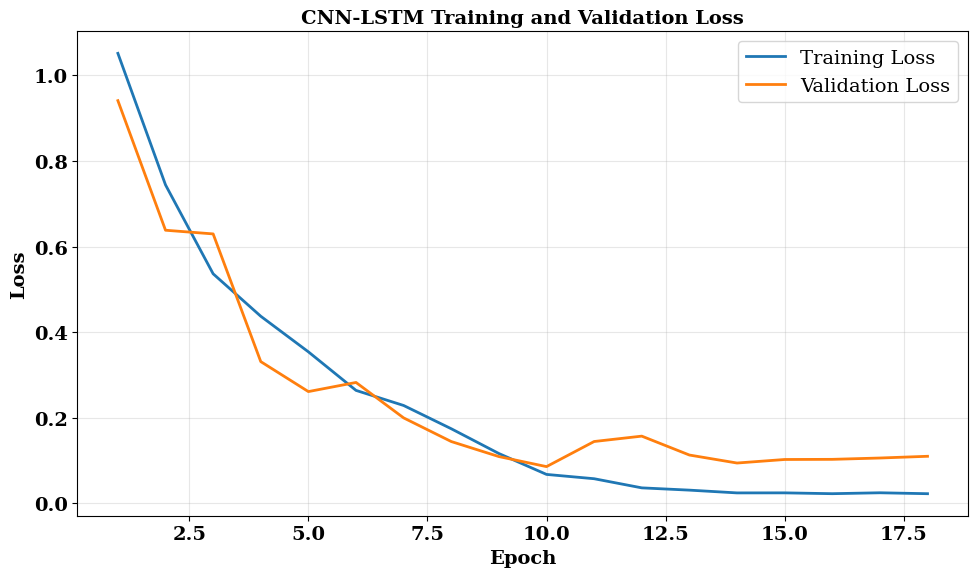

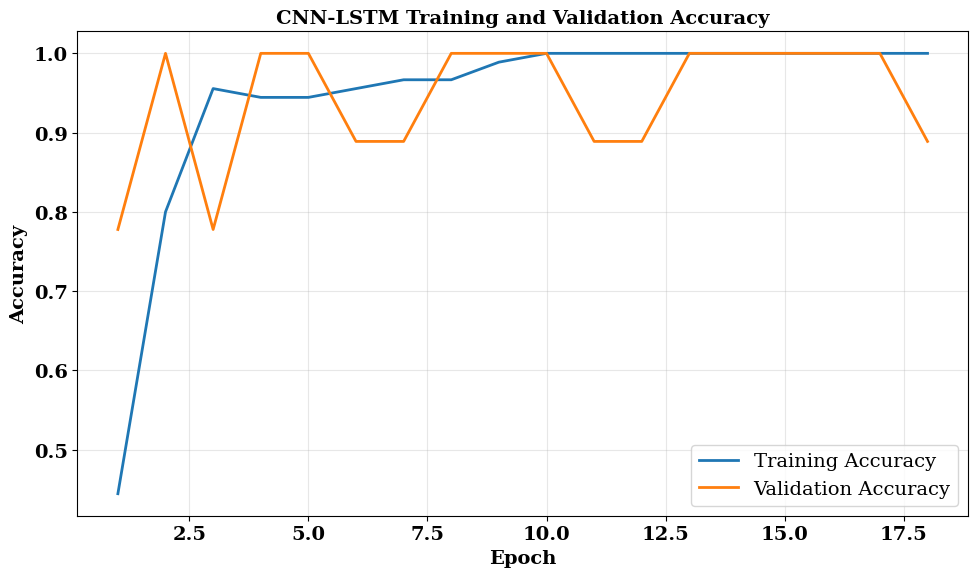


Saved:
/content/experiment6/outputs/video/17_cnn_lstm_training_validation_loss.eps
/content/experiment6/outputs/video/18_cnn_lstm_training_validation_accuracy.eps

CNN-LSTM CURVES COMPLETED


In [47]:
# ============================================================
# CELL 43 — CNN-LSTM TRAINING CURVES
# ============================================================

print("=" * 70)
print("CNN-LSTM TRAINING CURVES")
print("=" * 70)

epochs = range(
    1,
    len(video_lstm_history.history["loss"]) + 1
)

# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    epochs,
    video_lstm_history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

ax.plot(
    epochs,
    video_lstm_history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

ax.set_xlabel(
    "Epoch",
    fontweight="bold"
)

ax.set_ylabel(
    "Loss",
    fontweight="bold"
)

ax.set_title(
    "CNN-LSTM Training and Validation Loss",
    fontweight="bold"
)

ax.legend()

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.grid(
    True,
    alpha=0.3
)

fig.tight_layout()

lstm_loss_path = (
    VIDEO_OUTPUT_DIR /
    "17_cnn_lstm_training_validation_loss.eps"
)

fig.savefig(
    lstm_loss_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    epochs,
    video_lstm_history.history["accuracy"],
    linewidth=2,
    label="Training Accuracy"
)

ax.plot(
    epochs,
    video_lstm_history.history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)

ax.set_xlabel(
    "Epoch",
    fontweight="bold"
)

ax.set_ylabel(
    "Accuracy",
    fontweight="bold"
)

ax.set_title(
    "CNN-LSTM Training and Validation Accuracy",
    fontweight="bold"
)

ax.legend()

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.grid(
    True,
    alpha=0.3
)

fig.tight_layout()

lstm_accuracy_path = (
    VIDEO_OUTPUT_DIR /
    "18_cnn_lstm_training_validation_accuracy.eps"
)

fig.savefig(
    lstm_accuracy_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


print("\nSaved:")
print(lstm_loss_path)
print(lstm_accuracy_path)

print("\n" + "=" * 70)
print("CNN-LSTM CURVES COMPLETED")
print("=" * 70)

In [48]:
# ============================================================
# CELL 44 — CNN-LSTM TEST EVALUATION
# ============================================================

print("=" * 70)
print("CNN-LSTM TEST EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

lstm_test_prob = video_lstm_model.predict(
    X_video_test,
    batch_size=8,
    verbose=0
)

lstm_test_pred = np.argmax(
    lstm_test_prob,
    axis=1
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

video_lstm_accuracy = accuracy_score(
    y_video_test,
    lstm_test_pred
)

video_lstm_precision = precision_score(
    y_video_test,
    lstm_test_pred,
    average="macro",
    zero_division=0
)

video_lstm_recall = recall_score(
    y_video_test,
    lstm_test_pred,
    average="macro",
    zero_division=0
)

video_lstm_f1 = f1_score(
    y_video_test,
    lstm_test_pred,
    average="macro",
    zero_division=0
)

video_lstm_params = (
    video_lstm_model.count_params()
)

# ------------------------------------------------------------
# Print metrics
# ------------------------------------------------------------

print(
    f"Test Accuracy   : "
    f"{video_lstm_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision  : "
    f"{video_lstm_precision * 100:.2f}%"
)

print(
    f"Macro Recall     : "
    f"{video_lstm_recall * 100:.2f}%"
)

print(
    f"Macro F1         : "
    f"{video_lstm_f1 * 100:.2f}%"
)

print(
    f"Trainable Params : "
    f"{video_lstm_params:,}"
)

print(
    f"Training Time    : "
    f"{video_lstm_training_time:.2f} s"
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_video_test,
        lstm_test_pred,
        target_names=VIDEO_CLASSES,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

video_lstm_cm = confusion_matrix(
    y_video_test,
    lstm_test_pred
)

print("\nConfusion Matrix:")
print(video_lstm_cm)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

video_lstm_results = {
    "Model": "CNN-LSTM",
    "Test Accuracy": float(video_lstm_accuracy),
    "Macro Precision": float(video_lstm_precision),
    "Macro Recall": float(video_lstm_recall),
    "Macro F1": float(video_lstm_f1),
    "Trainable Parameters": int(video_lstm_params),
    "Training Time (s)": float(video_lstm_training_time),
    "Best Epoch": int(
        np.argmin(
            video_lstm_history.history["val_loss"]
        ) + 1
    )
}

video_lstm_results_path = (
    VIDEO_OUTPUT_DIR /
    "cnn_lstm_results.json"
)

with open(
    video_lstm_results_path,
    "w"
) as f:
    json.dump(
        video_lstm_results,
        f,
        indent=4
    )

np.save(
    VIDEO_OUTPUT_DIR /
    "cnn_lstm_confusion_matrix.npy",
    video_lstm_cm
)

print(
    "\nResults saved to:"
)

print(video_lstm_results_path)

print("\n" + "=" * 70)
print("CNN-LSTM TEST EVALUATION COMPLETED")
print("=" * 70)

CNN-LSTM TEST EVALUATION
Test Accuracy   : 96.43%
Macro Precision  : 95.83%
Macro Recall     : 96.97%
Macro F1         : 96.19%
Trainable Params : 168,643
Training Time    : 5.70 s

Classification Report:

               precision    recall  f1-score   support

      Archery     0.8750    1.0000    0.9333         7
   Basketball     1.0000    0.9091    0.9524        11
BaseballPitch     1.0000    1.0000    1.0000        10

     accuracy                         0.9643        28
    macro avg     0.9583    0.9697    0.9619        28
 weighted avg     0.9688    0.9643    0.9646        28


Confusion Matrix:
[[ 7  0  0]
 [ 1 10  0]
 [ 0  0 10]]

Results saved to:
/content/experiment6/outputs/video/cnn_lstm_results.json

CNN-LSTM TEST EVALUATION COMPLETED


CNN-LSTM CONFUSION MATRIX


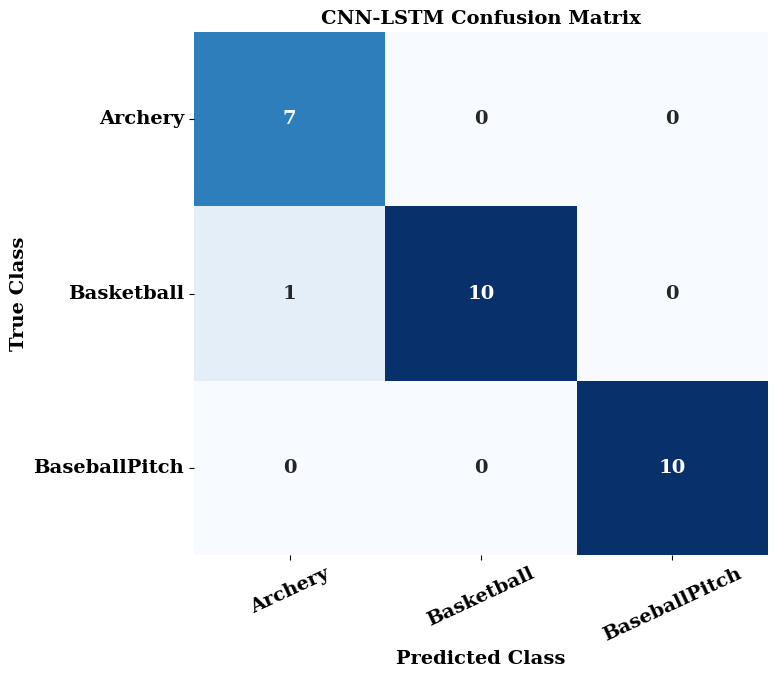

Confusion matrix saved to:
/content/experiment6/outputs/video/19_cnn_lstm_confusion_matrix.eps

CNN-LSTM CONFUSION MATRIX COMPLETED


In [49]:
# ============================================================
# CELL 45 — CNN-LSTM CONFUSION MATRIX
# ============================================================

print("=" * 70)
print("CNN-LSTM CONFUSION MATRIX")
print("=" * 70)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

sns.heatmap(
    video_lstm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=VIDEO_CLASSES,
    yticklabels=VIDEO_CLASSES,
    annot_kws={
        "fontsize": 14,
        "fontweight": "bold"
    },
    ax=ax
)

ax.set_xlabel(
    "Predicted Class",
    fontweight="bold"
)

ax.set_ylabel(
    "True Class",
    fontweight="bold"
)

ax.set_title(
    "CNN-LSTM Confusion Matrix",
    fontweight="bold"
)

# Bold tick labels
for label in ax.get_xticklabels():
    label.set_fontweight("bold")
    label.set_rotation(25)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_rotation(0)

fig.tight_layout()

video_lstm_cm_path = (
    VIDEO_OUTPUT_DIR /
    "19_cnn_lstm_confusion_matrix.eps"
)

fig.savefig(
    video_lstm_cm_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    f"Confusion matrix saved to:\n"
    f"{video_lstm_cm_path}"
)

print("\n" + "=" * 70)
print("CNN-LSTM CONFUSION MATRIX COMPLETED")
print("=" * 70)

In [50]:
# ============================================================
# CELL 46 — CNN + GRU MODEL
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 70)
print("BUILDING CNN + GRU MODEL")
print("=" * 70)

# ------------------------------------------------------------
# Clear previous model state
# ------------------------------------------------------------

tf.keras.backend.clear_session()
gc.collect()

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

video_gru_model = keras.Sequential(
    [
        layers.Input(
            shape=(
                NUM_FRAMES,
                FEATURE_DIM
            )
        ),

        layers.GRU(
            32,
            name="gru_32"
        ),

        layers.Dropout(
            0.2,
            name="dropout"
        ),

        layers.Dense(
            16,
            activation="relu",
            name="dense_16"
        ),

        layers.Dense(
            len(VIDEO_CLASSES),
            activation="softmax",
            name="output"
        )
    ],
    name="CNN_GRU_Video"
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

video_gru_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

video_gru_model.summary()

print(
    "\nTrainable parameters:",
    video_gru_model.count_params()
)

print("\n" + "=" * 70)
print("CNN + GRU MODEL READY")
print("=" * 70)

BUILDING CNN + GRU MODEL


Model: "CNN_GRU_Video"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_32 (GRU)                    │ (None, 32)             │       126,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,723 (495.01 KB)

 Trainable params: 126,723 (495.01 KB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters: 126723

CNN + GRU MODEL READY


In [51]:
# ============================================================
# CELL 47 — TRAIN CNN + GRU
# ============================================================

import time
import gc

print("=" * 70)
print("TRAINING CNN + GRU")
print("=" * 70)

gru_checkpoint = (
    VIDEO_MODEL_DIR /
    "best_cnn_gru.keras"
)

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

gru_callbacks = [

    keras.callbacks.ModelCheckpoint(
        filepath=str(gru_checkpoint),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

video_gru_start = time.perf_counter()

video_gru_history = video_gru_model.fit(
    X_video_train,
    y_video_train,

    validation_data=(
        X_video_val,
        y_video_val
    ),

    epochs=30,
    batch_size=8,

    callbacks=gru_callbacks,

    verbose=1
)

video_gru_training_time = (
    time.perf_counter()
    - video_gru_start
)

# ------------------------------------------------------------
# Load best checkpoint explicitly
# ------------------------------------------------------------

video_gru_model = keras.models.load_model(
    gru_checkpoint
)

print("\n" + "=" * 70)
print("CNN + GRU TRAINING COMPLETED")
print("=" * 70)

print(
    f"\nTraining time: "
    f"{video_gru_training_time:.2f} seconds"
)

print(
    f"Epochs completed: "
    f"{len(video_gru_history.history['loss'])}"
)

gru_best_epoch = (
    int(
        np.argmin(
            video_gru_history.history["val_loss"]
        )
    ) + 1
)

print(
    f"Best epoch: {gru_best_epoch}"
)

print(
    f"Best validation loss: "
    f"{min(video_gru_history.history['val_loss']):.4f}"
)

print(
    f"Best validation accuracy: "
    f"{max(video_gru_history.history['val_accuracy']):.4f}"
)

print(
    f"\nBest checkpoint:\n"
    f"{gru_checkpoint}"
)

TRAINING CNN + GRU
Epoch 1/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3311 - loss: 1.3704
Epoch 1: val_loss improved from None to 0.83636, saving model to /content/experiment6/models/video/best_cnn_gru.keras

Epoch 1: finished saving model to /content/experiment6/models/video/best_cnn_gru.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4556 - loss: 1.1305 - val_accuracy: 0.6667 - val_loss: 0.8364 - learning_rate: 0.0010
Epoch 2/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8380 - loss: 0.6320 
Epoch 2: val_loss improved from 0.83636 to 0.41471, saving model to /content/experiment6/models/video/best_cnn_gru.keras

Epoch 2: finished saving model to /content/experiment6/models/video/best_cnn_gru.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8111 - loss: 0.5996 - val_accuracy: 0.8889 - val_loss: 0.4147 - learning_rate: 0.0010
Epoch 3/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8996 - loss: 0.4540 
Epoch 3: val_loss improved from 

CNN-GRU TRAINING CURVES


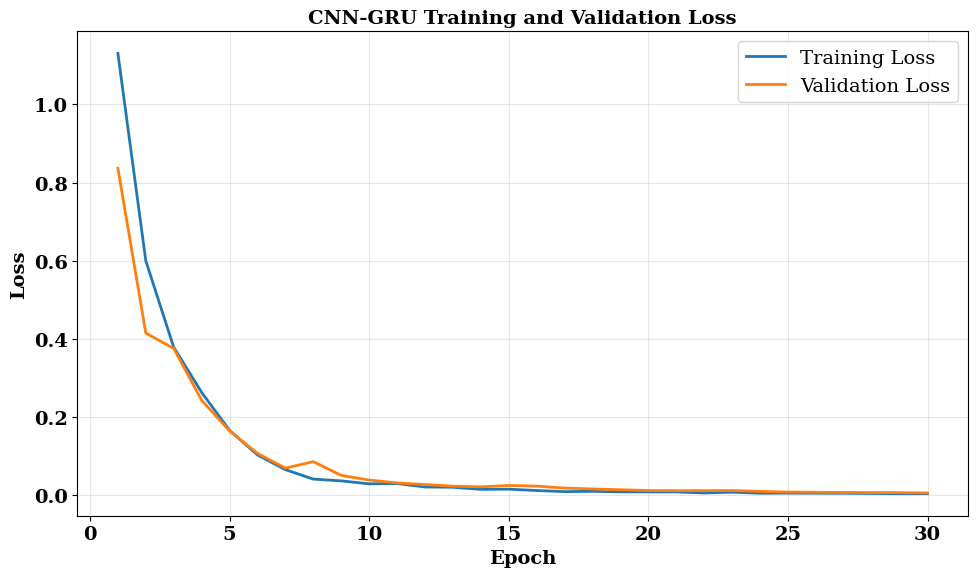

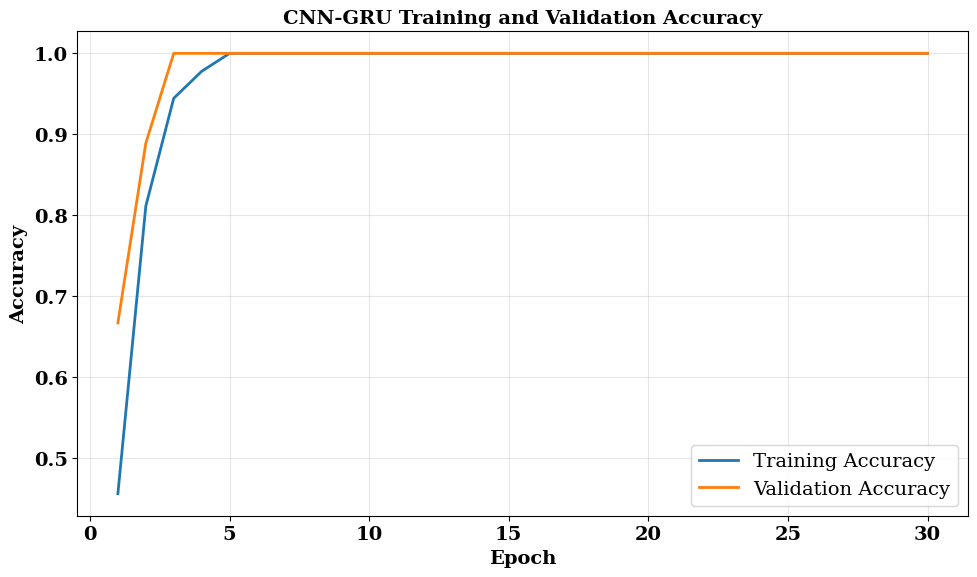


Saved:
/content/experiment6/outputs/video/20_cnn_gru_training_validation_loss.eps
/content/experiment6/outputs/video/21_cnn_gru_training_validation_accuracy.eps

CNN-GRU CURVES COMPLETED


In [52]:
# ============================================================
# CELL 48 — CNN-GRU TRAINING CURVES
# ============================================================

print("=" * 70)
print("CNN-GRU TRAINING CURVES")
print("=" * 70)

epochs = range(
    1,
    len(video_gru_history.history["loss"]) + 1
)

# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    epochs,
    video_gru_history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

ax.plot(
    epochs,
    video_gru_history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

ax.set_xlabel(
    "Epoch",
    fontweight="bold"
)

ax.set_ylabel(
    "Loss",
    fontweight="bold"
)

ax.set_title(
    "CNN-GRU Training and Validation Loss",
    fontweight="bold"
)

ax.legend()

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.grid(
    True,
    alpha=0.3
)

fig.tight_layout()

gru_loss_path = (
    VIDEO_OUTPUT_DIR /
    "20_cnn_gru_training_validation_loss.eps"
)

fig.savefig(
    gru_loss_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    epochs,
    video_gru_history.history["accuracy"],
    linewidth=2,
    label="Training Accuracy"
)

ax.plot(
    epochs,
    video_gru_history.history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)

ax.set_xlabel(
    "Epoch",
    fontweight="bold"
)

ax.set_ylabel(
    "Accuracy",
    fontweight="bold"
)

ax.set_title(
    "CNN-GRU Training and Validation Accuracy",
    fontweight="bold"
)

ax.legend()

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.grid(
    True,
    alpha=0.3
)

fig.tight_layout()

gru_accuracy_path = (
    VIDEO_OUTPUT_DIR /
    "21_cnn_gru_training_validation_accuracy.eps"
)

fig.savefig(
    gru_accuracy_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


print("\nSaved:")
print(gru_loss_path)
print(gru_accuracy_path)

print("\n" + "=" * 70)
print("CNN-GRU CURVES COMPLETED")
print("=" * 70)

In [53]:
# ============================================================
# CELL 49 — CNN-GRU TEST EVALUATION
# ============================================================

print("=" * 70)
print("CNN-GRU TEST EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

gru_test_prob = video_gru_model.predict(
    X_video_test,
    batch_size=8,
    verbose=0
)

gru_test_pred = np.argmax(
    gru_test_prob,
    axis=1
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

video_gru_accuracy = accuracy_score(
    y_video_test,
    gru_test_pred
)

video_gru_precision = precision_score(
    y_video_test,
    gru_test_pred,
    average="macro",
    zero_division=0
)

video_gru_recall = recall_score(
    y_video_test,
    gru_test_pred,
    average="macro",
    zero_division=0
)

video_gru_f1 = f1_score(
    y_video_test,
    gru_test_pred,
    average="macro",
    zero_division=0
)

video_gru_params = (
    video_gru_model.count_params()
)

# ------------------------------------------------------------
# Print metrics
# ------------------------------------------------------------

print(
    f"Test Accuracy   : "
    f"{video_gru_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision  : "
    f"{video_gru_precision * 100:.2f}%"
)

print(
    f"Macro Recall     : "
    f"{video_gru_recall * 100:.2f}%"
)

print(
    f"Macro F1         : "
    f"{video_gru_f1 * 100:.2f}%"
)

print(
    f"Trainable Params : "
    f"{video_gru_params:,}"
)

print(
    f"Training Time    : "
    f"{video_gru_training_time:.2f} s"
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_video_test,
        gru_test_pred,
        target_names=VIDEO_CLASSES,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

video_gru_cm = confusion_matrix(
    y_video_test,
    gru_test_pred
)

print("\nConfusion Matrix:")
print(video_gru_cm)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

video_gru_results = {
    "Model": "CNN-GRU",
    "Test Accuracy": float(video_gru_accuracy),
    "Macro Precision": float(video_gru_precision),
    "Macro Recall": float(video_gru_recall),
    "Macro F1": float(video_gru_f1),
    "Trainable Parameters": int(video_gru_params),
    "Training Time (s)": float(video_gru_training_time),
    "Best Epoch": int(
        np.argmin(
            video_gru_history.history["val_loss"]
        ) + 1
    )
}

video_gru_results_path = (
    VIDEO_OUTPUT_DIR /
    "cnn_gru_results.json"
)

with open(
    video_gru_results_path,
    "w"
) as f:
    json.dump(
        video_gru_results,
        f,
        indent=4
    )

np.save(
    VIDEO_OUTPUT_DIR /
    "cnn_gru_confusion_matrix.npy",
    video_gru_cm
)

print(
    "\nResults saved to:"
)

print(video_gru_results_path)

print("\n" + "=" * 70)
print("CNN-GRU TEST EVALUATION COMPLETED")
print("=" * 70)

CNN-GRU TEST EVALUATION


Test Accuracy   : 89.29%
Macro Precision  : 90.00%
Macro Recall     : 90.91%
Macro F1         : 88.85%
Trainable Params : 126,723
Training Time    : 7.61 s

Classification Report:

               precision    recall  f1-score   support

      Archery     0.7000    1.0000    0.8235         7
   Basketball     1.0000    0.7273    0.8421        11
BaseballPitch     1.0000    1.0000    1.0000        10

     accuracy                         0.8929        28
    macro avg     0.9000    0.9091    0.8885        28
 weighted avg     0.9250    0.8929    0.8939        28


Confusion Matrix:
[[ 7  0  0]
 [ 3  8  0]
 [ 0  0 10]]

Results saved to:
/content/experiment6/outputs/video/cnn_gru_results.json

CNN-GRU TEST EVALUATION COMPLETED


CNN-GRU CONFUSION MATRIX


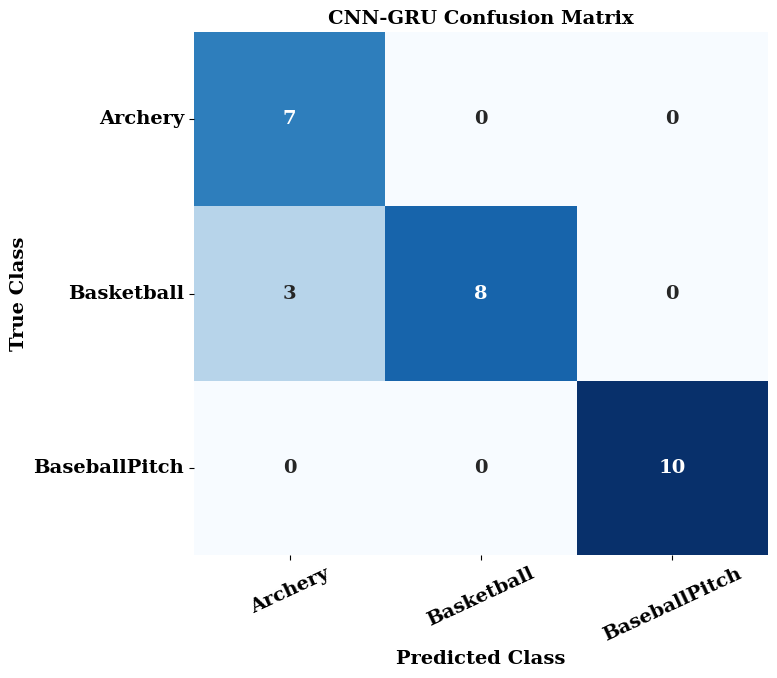

Confusion matrix saved to:
/content/experiment6/outputs/video/22_cnn_gru_confusion_matrix.eps

CNN-GRU CONFUSION MATRIX COMPLETED


In [54]:
# ============================================================
# CELL 50 — CNN-GRU CONFUSION MATRIX
# ============================================================

print("=" * 70)
print("CNN-GRU CONFUSION MATRIX")
print("=" * 70)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

sns.heatmap(
    video_gru_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=VIDEO_CLASSES,
    yticklabels=VIDEO_CLASSES,
    annot_kws={
        "fontsize": 14,
        "fontweight": "bold"
    },
    ax=ax
)

ax.set_xlabel(
    "Predicted Class",
    fontweight="bold"
)

ax.set_ylabel(
    "True Class",
    fontweight="bold"
)

ax.set_title(
    "CNN-GRU Confusion Matrix",
    fontweight="bold"
)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")
    label.set_rotation(25)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_rotation(0)

fig.tight_layout()

video_gru_cm_path = (
    VIDEO_OUTPUT_DIR /
    "22_cnn_gru_confusion_matrix.eps"
)

fig.savefig(
    video_gru_cm_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    f"Confusion matrix saved to:\n"
    f"{video_gru_cm_path}"
)

print("\n" + "=" * 70)
print("CNN-GRU CONFUSION MATRIX COMPLETED")
print("=" * 70)

In [55]:
# ============================================================
# CELL 51 — CNN-LSTM vs CNN-GRU COMPARISON
# ============================================================

print("=" * 70)
print("VIDEO MODEL COMPARISON")
print("=" * 70)

video_comparison_df = pd.DataFrame([
    {
        "Model": "CNN-LSTM",
        "Test Accuracy": video_lstm_accuracy,
        "Macro Precision": video_lstm_precision,
        "Macro Recall": video_lstm_recall,
        "Macro F1": video_lstm_f1,
        "Trainable Parameters": video_lstm_params,
        "Training Time (s)": video_lstm_training_time
    },
    {
        "Model": "CNN-GRU",
        "Test Accuracy": video_gru_accuracy,
        "Macro Precision": video_gru_precision,
        "Macro Recall": video_gru_recall,
        "Macro F1": video_gru_f1,
        "Trainable Parameters": video_gru_params,
        "Training Time (s)": video_gru_training_time
    }
])

display(
    video_comparison_df.round(4)
)

# ------------------------------------------------------------
# Save comparison
# ------------------------------------------------------------

video_comparison_csv = (
    VIDEO_OUTPUT_DIR /
    "cnn_lstm_gru_comparison.csv"
)

video_comparison_json = (
    VIDEO_OUTPUT_DIR /
    "cnn_lstm_gru_comparison.json"
)

video_comparison_df.to_csv(
    video_comparison_csv,
    index=False
)

video_comparison_df.to_json(
    video_comparison_json,
    orient="records",
    indent=4
)

print("\nSaved:")
print(video_comparison_csv)
print(video_comparison_json)

print("\n" + "=" * 70)
print("VIDEO MODEL COMPARISON COMPLETED")
print("=" * 70)

VIDEO MODEL COMPARISON


,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Trainable Parameters,Training Time (s)
0,CNN-LSTM,0.9643,0.9583,0.9697,0.9619,168643,5.6977
1,CNN-GRU,0.8929,0.9000,0.9091,0.8885,126723,7.6072



Saved:
/content/experiment6/outputs/video/cnn_lstm_gru_comparison.csv
/content/experiment6/outputs/video/cnn_lstm_gru_comparison.json

VIDEO MODEL COMPARISON COMPLETED


In [56]:
# ============================================================
# CELL 52 — SYNTHETIC SEQUENCE REVERSAL DATASET
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import gc

print("=" * 70)
print("GENERATING SYNTHETIC SEQUENCE REVERSAL DATASET")
print("=" * 70)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEQ2SEQ_SEED = 42

np.random.seed(SEQ2SEQ_SEED)
tf.random.set_seed(SEQ2SEQ_SEED)

# ------------------------------------------------------------
# Dataset configuration
# ------------------------------------------------------------

NUM_SEQUENCES = 5000
INPUT_LENGTH = 4

MIN_TOKEN = 1
MAX_TOKEN = 9

# Special tokens
PAD_TOKEN = 0
START_TOKEN = 10
END_TOKEN = 11

VOCAB_SIZE = 12

print("Number of sequences :", NUM_SEQUENCES)
print("Input length        :", INPUT_LENGTH)
print("Token range         :", f"{MIN_TOKEN}–{MAX_TOKEN}")
print("PAD token           :", PAD_TOKEN)
print("START token         :", START_TOKEN)
print("END token           :", END_TOKEN)
print("Vocabulary size     :", VOCAB_SIZE)

# ------------------------------------------------------------
# Generate random input sequences
# ------------------------------------------------------------

input_sequences = np.random.randint(
    MIN_TOKEN,
    MAX_TOKEN + 1,
    size=(
        NUM_SEQUENCES,
        INPUT_LENGTH
    )
)

# ------------------------------------------------------------
# Reverse each sequence
# ------------------------------------------------------------

target_sequences = np.flip(
    input_sequences,
    axis=1
)

# ------------------------------------------------------------
# Encoder input
# ------------------------------------------------------------

encoder_input = input_sequences.copy()

# ------------------------------------------------------------
# Decoder input
#
# <START> + target sequence
# ------------------------------------------------------------

decoder_input = np.concatenate(
    [
        np.full(
            (NUM_SEQUENCES, 1),
            START_TOKEN
        ),
        target_sequences
    ],
    axis=1
)

# ------------------------------------------------------------
# Decoder target
#
# target sequence + <END>
# ------------------------------------------------------------

decoder_target = np.concatenate(
    [
        target_sequences,
        np.full(
            (NUM_SEQUENCES, 1),
            END_TOKEN
        )
    ],
    axis=1
)

# ------------------------------------------------------------
# Train / validation / test split
# ------------------------------------------------------------

train_end = int(
    0.70 * NUM_SEQUENCES
)

val_end = int(
    0.85 * NUM_SEQUENCES
)

encoder_train = encoder_input[
    :train_end
]

decoder_input_train = decoder_input[
    :train_end
]

decoder_target_train = decoder_target[
    :train_end
]

encoder_val = encoder_input[
    train_end:val_end
]

decoder_input_val = decoder_input[
    train_end:val_end
]

decoder_target_val = decoder_target[
    train_end:val_end
]

encoder_test = encoder_input[
    val_end:
]

decoder_input_test = decoder_input[
    val_end:
]

decoder_target_test = decoder_target[
    val_end:
]

print("\nDataset shapes:")

print(
    "Encoder train       :",
    encoder_train.shape
)

print(
    "Decoder input train :",
    decoder_input_train.shape
)

print(
    "Decoder target train:",
    decoder_target_train.shape
)

print(
    "Encoder validation  :",
    encoder_val.shape
)

print(
    "Encoder test        :",
    encoder_test.shape
)

# ------------------------------------------------------------
# Display examples
# ------------------------------------------------------------

print("\nExample sequences:")

for i in range(5):

    source = encoder_input[i]
    target = target_sequences[i]

    print(
        f"{i + 1}. "
        f"{source.tolist()}  ->  "
        f"{target.tolist()}"
    )

# ------------------------------------------------------------
# Save dataset
# ------------------------------------------------------------

seq2seq_cache = (
    CACHE_DIR /
    "seq2seq_reversal_data.npz"
)

np.savez_compressed(
    seq2seq_cache,

    encoder_train=encoder_train,
    decoder_input_train=decoder_input_train,
    decoder_target_train=decoder_target_train,

    encoder_val=encoder_val,
    decoder_input_val=decoder_input_val,
    decoder_target_val=decoder_target_val,

    encoder_test=encoder_test,
    decoder_input_test=decoder_input_test,
    decoder_target_test=decoder_target_test
)

print(
    "\nDataset cached at:"
)

print(seq2seq_cache)

print("\n" + "=" * 70)
print("SEQ2SEQ DATASET GENERATION COMPLETED")
print("=" * 70)

GENERATING SYNTHETIC SEQUENCE REVERSAL DATASET
Number of sequences : 5000
Input length        : 4
Token range         : 1–9
PAD token           : 0
START token         : 10
END token           : 11
Vocabulary size     : 12

Dataset shapes:
Encoder train       : (3500, 4)
Decoder input train : (3500, 5)
Decoder target train: (3500, 5)
Encoder validation  : (750, 4)
Encoder test        : (750, 4)

Example sequences:
1. [7, 4, 8, 5]  ->  [5, 8, 4, 7]
2. [7, 3, 7, 8]  ->  [8, 7, 3, 7]
3. [5, 4, 8, 8]  ->  [8, 8, 4, 5]
4. [3, 6, 5, 2]  ->  [2, 5, 6, 3]
5. [8, 6, 2, 5]  ->  [5, 2, 6, 8]

Dataset cached at:
/content/experiment6/cache/seq2seq_reversal_data.npz

SEQ2SEQ DATASET GENERATION COMPLETED


In [57]:
# ============================================================
# CELL 53 — ENCODER-DECODER LSTM
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import gc

print("=" * 70)
print("BUILDING ENCODER-DECODER LSTM")
print("=" * 70)

# ------------------------------------------------------------
# Clear previous model state
# ------------------------------------------------------------

tf.keras.backend.clear_session()
gc.collect()

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

EMBEDDING_DIM = 32
LATENT_DIM = 64

# ------------------------------------------------------------
# Encoder
# ------------------------------------------------------------

encoder_inputs = layers.Input(
    shape=(INPUT_LENGTH,),
    name="encoder_input"
)

encoder_embedding = layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    name="encoder_embedding"
)(
    encoder_inputs
)

encoder_lstm = layers.LSTM(
    LATENT_DIM,
    return_state=True,
    name="encoder_lstm"
)

encoder_outputs, state_h, state_c = (
    encoder_lstm(
        encoder_embedding
    )
)

# Encoder states become decoder initial states
encoder_states = [
    state_h,
    state_c
]

# ------------------------------------------------------------
# Decoder
# ------------------------------------------------------------

decoder_inputs = layers.Input(
    shape=(INPUT_LENGTH + 1,),
    name="decoder_input"
)

decoder_embedding_layer = layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    name="decoder_embedding"
)

decoder_embedding = (
    decoder_embedding_layer(
        decoder_inputs
    )
)

decoder_lstm = layers.LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)

# ------------------------------------------------------------
# Output layer
# ------------------------------------------------------------

decoder_dense = layers.Dense(
    VOCAB_SIZE,
    activation="softmax",
    name="decoder_output"
)

decoder_outputs = decoder_dense(
    decoder_outputs
)

# ------------------------------------------------------------
# Complete training model
# ------------------------------------------------------------

seq2seq_model = keras.Model(
    [
        encoder_inputs,
        decoder_inputs
    ],
    decoder_outputs,
    name="Encoder_Decoder_LSTM"
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

seq2seq_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"]
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

seq2seq_model.summary()

print(
    "\nTrainable parameters:",
    seq2seq_model.count_params()
)

print("\n" + "=" * 70)
print("ENCODER-DECODER LSTM READY")
print("=" * 70)

BUILDING ENCODER-DECODER LSTM


Model: "Encoder_Decoder_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 4, 32)     │        384 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 5, 32)     │        384 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     24,832 │ encoder_embeddin… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 5, 64),   │     24,832 │ decoder_embeddin… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 5, 12)     │        780 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,212 (200.05 KB)

 Trainable params: 51,212 (200.05 KB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters: 51212

ENCODER-DECODER LSTM READY


In [58]:
# ============================================================
# CELL 54 — TRAIN ENCODER-DECODER LSTM
# ============================================================

import time
import json
import numpy as np
import gc

print("=" * 70)
print("TRAINING ENCODER-DECODER LSTM")
print("=" * 70)

SEQ2SEQ_MODEL_DIR = (
    MODEL_DIR / "seq2seq"
)

SEQ2SEQ_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

seq2seq_checkpoint = (
    SEQ2SEQ_MODEL_DIR /
    "best_seq2seq_lstm.keras"
)

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

seq2seq_callbacks = [

    keras.callbacks.ModelCheckpoint(
        filepath=str(seq2seq_checkpoint),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

seq2seq_start = time.perf_counter()

seq2seq_history = seq2seq_model.fit(
    [
        encoder_train,
        decoder_input_train
    ],
    decoder_target_train,

    validation_data=(
        [
            encoder_val,
            decoder_input_val
        ],
        decoder_target_val
    ),

    epochs=30,
    batch_size=32,

    callbacks=seq2seq_callbacks,

    verbose=1
)

seq2seq_training_time = (
    time.perf_counter()
    - seq2seq_start
)

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

seq2seq_model = keras.models.load_model(
    seq2seq_checkpoint
)

# ------------------------------------------------------------
# Training information
# ------------------------------------------------------------

best_seq2seq_epoch = (
    int(
        np.argmin(
            seq2seq_history.history["val_loss"]
        )
    ) + 1
)

best_seq2seq_val_loss = min(
    seq2seq_history.history["val_loss"]
)

best_seq2seq_val_accuracy = max(
    seq2seq_history.history[
        "val_sparse_categorical_accuracy"
    ]
)

print("\n" + "=" * 70)
print("SEQ2SEQ TRAINING COMPLETED")
print("=" * 70)

print(
    f"\nTraining time: "
    f"{seq2seq_training_time:.2f} seconds"
)

print(
    f"Epochs completed: "
    f"{len(seq2seq_history.history['loss'])}"
)

print(
    f"Best epoch: "
    f"{best_seq2seq_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_seq2seq_val_loss:.4f}"
)

print(
    f"Best validation token accuracy: "
    f"{best_seq2seq_val_accuracy * 100:.2f}%"
)

print(
    f"\nBest checkpoint:\n"
    f"{seq2seq_checkpoint}"
)

TRAINING ENCODER-DECODER LSTM
Epoch 1/30
103/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.2388 - sparse_categorical_accuracy: 0.2346
Epoch 1: val_loss improved from None to 1.28921, saving model to /content/experiment6/models/seq2seq/best_seq2seq_lstm.keras

Epoch 1: finished saving model to /content/experiment6/models/seq2seq/best_seq2seq_lstm.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1.8990 - sparse_categorical_accuracy: 0.3310 - val_loss: 1.2892 - val_sparse_categorical_accuracy: 0.5165 - learning_rate: 0.0010
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1650 - sparse_categorical_accuracy: 0.5483
Epoch 2: val_loss improved from 1.28921 to 0.76506, saving model to /content/experiment6/models/seq2seq/best_seq2seq_lstm.keras

Epoch 2: finished saving model to /content/experiment6/models/seq2seq/best_seq2seq_lstm.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0457 - sparse_categorical_accuracy: 0.5916 - val_loss: 0.7651 - val_sparse_categorical

SEQ2SEQ TRAINING CURVE


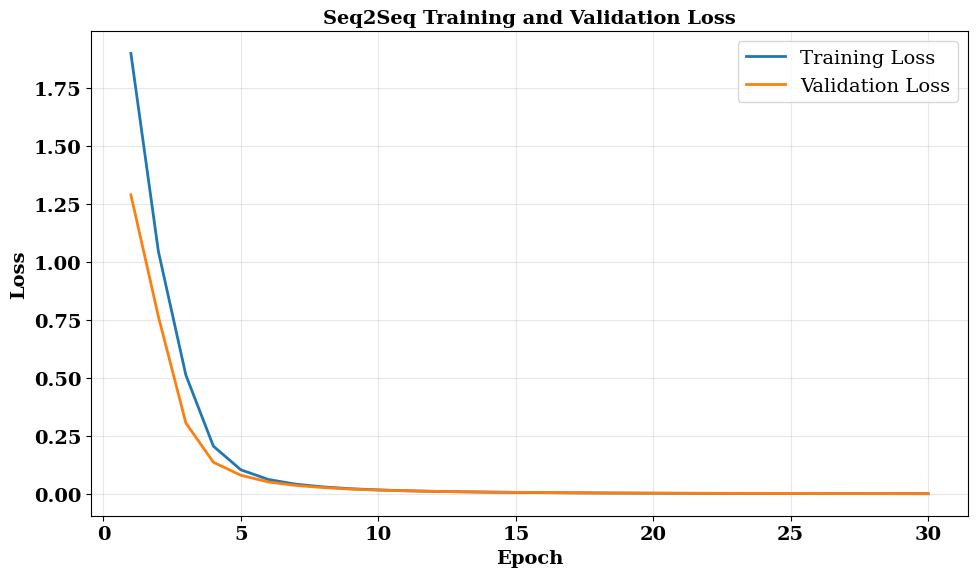

Plot saved to:
/content/experiment6/outputs/23_seq2seq_training_validation_loss.eps

SEQ2SEQ CURVE COMPLETED


In [59]:
# ============================================================
# CELL 55 — SEQ2SEQ TRAINING / VALIDATION LOSS
# ============================================================

print("=" * 70)
print("SEQ2SEQ TRAINING CURVE")
print("=" * 70)

epochs = range(
    1,
    len(seq2seq_history.history["loss"]) + 1
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    epochs,
    seq2seq_history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

ax.plot(
    epochs,
    seq2seq_history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

ax.set_xlabel(
    "Epoch",
    fontweight="bold"
)

ax.set_ylabel(
    "Loss",
    fontweight="bold"
)

ax.set_title(
    "Seq2Seq Training and Validation Loss",
    fontweight="bold"
)

ax.legend()

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.grid(
    True,
    alpha=0.3
)

fig.tight_layout()

seq2seq_loss_path = (
    OUTPUT_DIR /
    "23_seq2seq_training_validation_loss.eps"
)

fig.savefig(
    seq2seq_loss_path,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    f"Plot saved to:\n{seq2seq_loss_path}"
)

print("\n" + "=" * 70)
print("SEQ2SEQ CURVE COMPLETED")
print("=" * 70)

In [60]:
# ============================================================
# CELL 56 — BUILD SEQ2SEQ INFERENCE MODELS
# CORRECTED VERSION
# ============================================================

print("=" * 70)
print("BUILDING SEQ2SEQ INFERENCE MODELS")
print("=" * 70)

# ------------------------------------------------------------
# Encoder inference model
# ------------------------------------------------------------

encoder_inference_model = keras.Model(
    encoder_inputs,
    encoder_states,
    name="Encoder_Inference"
)

# ------------------------------------------------------------
# Decoder inference inputs
# ------------------------------------------------------------

decoder_token_input = layers.Input(
    shape=(1,),
    dtype="int32",
    name="decoder_token_input"
)

decoder_state_h_input = layers.Input(
    shape=(LATENT_DIM,),
    name="decoder_state_h_input"
)

decoder_state_c_input = layers.Input(
    shape=(LATENT_DIM,),
    name="decoder_state_c_input"
)

# ------------------------------------------------------------
# Embedding
# ------------------------------------------------------------

decoder_embedding_inference = (
    decoder_embedding_layer(
        decoder_token_input
    )
)

# ------------------------------------------------------------
# Decoder LSTM
#
# It returns:
#   1. output sequence
#   2. hidden state
#   3. cell state
# ------------------------------------------------------------

decoder_output_sequence, \
decoder_state_h_output, \
decoder_state_c_output = decoder_lstm(
    decoder_embedding_inference,
    initial_state=[
        decoder_state_h_input,
        decoder_state_c_input
    ]
)

# ------------------------------------------------------------
# Convert decoder output to token probabilities
# ------------------------------------------------------------

decoder_prediction = decoder_dense(
    decoder_output_sequence
)

# ------------------------------------------------------------
# Build inference decoder
# ------------------------------------------------------------

decoder_inference_model = keras.Model(
    [
        decoder_token_input,
        decoder_state_h_input,
        decoder_state_c_input
    ],
    [
        decoder_prediction,
        decoder_state_h_output,
        decoder_state_c_output
    ],
    name="Decoder_Inference"
)

print(
    "Encoder inference model ready."
)

print(
    "Decoder inference model ready."
)

print(
    "\nDecoder output shape:",
    decoder_prediction.shape
)

print(
    "Decoder hidden-state shape:",
    decoder_state_h_output.shape
)

print(
    "Decoder cell-state shape:",
    decoder_state_c_output.shape
)

print("\n" + "=" * 70)
print("INFERENCE MODELS READY")
print("=" * 70)

BUILDING SEQ2SEQ INFERENCE MODELS
Encoder inference model ready.
Decoder inference model ready.

Decoder output shape: (None, 1, 12)
Decoder hidden-state shape: (None, 64)
Decoder cell-state shape: (None, 64)

INFERENCE MODELS READY


In [61]:
# ============================================================
# CELL 57 — SEQ2SEQ TEST INFERENCE
# ============================================================

print("=" * 70)
print("RUNNING SEQ2SEQ TEST INFERENCE")
print("=" * 70)

# ------------------------------------------------------------
# Encode all test sequences
# ------------------------------------------------------------

encoder_test_states = encoder_inference_model(
    encoder_test,
    training=False
)

state_h, state_c = encoder_test_states

# ------------------------------------------------------------
# Start every sequence with START token
# ------------------------------------------------------------

current_tokens = tf.fill(
    [encoder_test.shape[0], 1],
    tf.constant(START_TOKEN, dtype=tf.int32)
)

predicted_tokens = []

# ------------------------------------------------------------
# Generate 4 output tokens
# ------------------------------------------------------------

for step in range(INPUT_LENGTH):

    decoder_output, state_h, state_c = decoder_inference_model(
        [
            current_tokens,
            state_h,
            state_c
        ],
        training=False
    )

    # Select most probable token
    current_tokens = tf.argmax(
        decoder_output[:, 0, :],
        axis=-1,
        output_type=tf.int32
    )

    predicted_tokens.append(
        current_tokens.numpy()
    )

# ------------------------------------------------------------
# Convert predictions to array
# ------------------------------------------------------------

predicted_tokens = np.stack(
    predicted_tokens,
    axis=1
)

# ------------------------------------------------------------
# Ground-truth reversed sequences
#
# decoder_target_test:
# [reversed sequence] + [END]
#
# We evaluate only the 4 actual sequence tokens.
# ------------------------------------------------------------

target_tokens = decoder_target_test[:, :INPUT_LENGTH]

# ------------------------------------------------------------
# Token accuracy
# ------------------------------------------------------------

token_accuracy = np.mean(
    predicted_tokens == target_tokens
)

# ------------------------------------------------------------
# Sequence accuracy
#
# A sequence is correct only when ALL 4 tokens
# are predicted correctly.
# ------------------------------------------------------------

sequence_correct = np.all(
    predicted_tokens == target_tokens,
    axis=1
)

sequence_accuracy = np.mean(
    sequence_correct
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nNumber of test sequences:", len(target_tokens))

print(
    f"Token Accuracy     : {token_accuracy * 100:.2f}%"
)

print(
    f"Sequence Accuracy  : {sequence_accuracy * 100:.2f}%"
)

print(
    "\nCorrect complete sequences:",
    int(sequence_correct.sum()),
    "/",
    len(sequence_correct)
)

print("=" * 70)
print("SEQ2SEQ TEST INFERENCE COMPLETE")
print("=" * 70)

RUNNING SEQ2SEQ TEST INFERENCE

Number of test sequences: 750
Token Accuracy     : 100.00%
Sequence Accuracy  : 100.00%

Correct complete sequences: 750 / 750
SEQ2SEQ TEST INFERENCE COMPLETE


In [62]:
# ============================================================
# CELL 58 — FIVE SEQ2SEQ TEST EXAMPLES
# ============================================================

print("=" * 70)
print("SEQ2SEQ TEST EXAMPLES")
print("=" * 70)

num_examples = 5

examples = []

for i in range(num_examples):

    input_sequence = encoder_test[i]

    target_sequence = target_tokens[i]

    predicted_sequence = predicted_tokens[i]

    is_correct = np.array_equal(
        target_sequence,
        predicted_sequence
    )

    examples.append({
        "Example": i + 1,
        "Input": input_sequence.tolist(),
        "Target Reversal": target_sequence.tolist(),
        "Predicted": predicted_sequence.tolist(),
        "Exact Match": "Yes" if is_correct else "No"
    })

    print(f"\nExample {i + 1}")
    print("-" * 40)
    print("Input:           ", input_sequence.tolist())
    print("Target reversal: ", target_sequence.tolist())
    print("Predicted:       ", predicted_sequence.tolist())
    print("Exact match:     ", "Yes" if is_correct else "No")

# ------------------------------------------------------------
# Save examples
# ------------------------------------------------------------

seq2seq_examples_df = pd.DataFrame(examples)

examples_path = OUTPUT_DIR / "seq2seq_test_examples.csv"

seq2seq_examples_df.to_csv(
    examples_path,
    index=False
)

print("\n" + "=" * 70)
print("Examples saved to:")
print(examples_path)
print("=" * 70)

SEQ2SEQ TEST EXAMPLES

Example 1
----------------------------------------
Input:            [4, 2, 3, 7]
Target reversal:  [7, 3, 2, 4]
Predicted:        [7, 3, 2, 4]
Exact match:      Yes

Example 2
----------------------------------------
Input:            [7, 1, 8, 7]
Target reversal:  [7, 8, 1, 7]
Predicted:        [7, 8, 1, 7]
Exact match:      Yes

Example 3
----------------------------------------
Input:            [1, 8, 2, 8]
Target reversal:  [8, 2, 8, 1]
Predicted:        [8, 2, 8, 1]
Exact match:      Yes

Example 4
----------------------------------------
Input:            [3, 7, 6, 5]
Target reversal:  [5, 6, 7, 3]
Predicted:        [5, 6, 7, 3]
Exact match:      Yes

Example 5
----------------------------------------
Input:            [2, 2, 1, 9]
Target reversal:  [9, 1, 2, 2]
Predicted:        [9, 1, 2, 2]
Exact match:      Yes

Examples saved to:
/content/experiment6/outputs/seq2seq_test_examples.csv


In [63]:
# ============================================================
# CELL 59 — SAVE FINAL SEQ2SEQ RESULTS
# ============================================================

seq2seq_results = {
    "experiment": "Synthetic Sequence Reversal Seq2Seq",
    "num_sequences": 5000,
    "input_length": INPUT_LENGTH,
    "vocab_size": VOCAB_SIZE,
    "embedding_dim": EMBEDDING_DIM,
    "latent_dim": LATENT_DIM,

    "train_samples": len(encoder_train),
    "validation_samples": len(encoder_val),
    "test_samples": len(encoder_test),

    "training_epochs": len(seq2seq_history.history["loss"]),
    "best_epoch": int(
        np.argmin(seq2seq_history.history["val_loss"]) + 1
    ),

    "best_validation_loss": float(
        np.min(seq2seq_history.history["val_loss"])
    ),

    "best_validation_token_accuracy": float(
        np.max(seq2seq_history.history["val_token_accuracy"])
    ) if "val_token_accuracy" in seq2seq_history.history else None,

    "test_token_accuracy": float(token_accuracy),
    "test_sequence_accuracy": float(sequence_accuracy),

    "correct_complete_sequences": int(
        sequence_correct.sum()
    ),

    "total_test_sequences": int(
        len(sequence_correct)
    ),

    "training_time_seconds": float(seq2seq_training_time),

    "trainable_parameters": int(
        seq2seq_model.count_params()
    )
}

seq2seq_results_path = OUTPUT_DIR / "seq2seq_results.json"

with open(seq2seq_results_path, "w") as f:
    json.dump(
        seq2seq_results,
        f,
        indent=4
    )

print("=" * 70)
print("FINAL SEQ2SEQ RESULTS")
print("=" * 70)

for key, value in seq2seq_results.items():
    print(f"{key}: {value}")

print("\nSaved to:")
print(seq2seq_results_path)

print("=" * 70)

FINAL SEQ2SEQ RESULTS
experiment: Synthetic Sequence Reversal Seq2Seq
num_sequences: 5000
input_length: 4
vocab_size: 12
embedding_dim: 32
latent_dim: 64
train_samples: 3500
validation_samples: 750
test_samples: 750
training_epochs: 30
best_epoch: 30
best_validation_loss: 0.0014533837093040347
best_validation_token_accuracy: None
test_token_accuracy: 1.0
test_sequence_accuracy: 1.0
correct_complete_sequences: 750
total_test_sequences: 750
training_time_seconds: 38.558904762
trainable_parameters: 51212

Saved to:
/content/experiment6/outputs/seq2seq_results.json


In [64]:
# ============================================================
# CELL 60 — FINAL CONSOLIDATED RESULTS
# ============================================================

print("=" * 80)
print("FINAL CONSOLIDATED RESULTS")
print("=" * 80)

# ------------------------------------------------------------
# HAR MODEL RESULTS
# ------------------------------------------------------------

consolidated_results = pd.DataFrame([
    {
        "Model": "Vanilla RNN",
        "Accuracy (%)": 72.38,
        "Macro Precision (%)": 72.34,
        "Macro Recall (%)": 71.24,
        "Macro F1 (%)": 71.47,
        "Parameters": 1974,
        "Training Time (s)": 23.74
    },
    {
        "Model": "LSTM",
        "Accuracy (%)": 88.50,
        "Macro Precision (%)": 88.55,
        "Macro Recall (%)": 88.46,
        "Macro F1 (%)": 88.27,
        "Parameters": 6006,
        "Training Time (s)": 19.46
    },
    {
        "Model": "GRU",
        "Accuracy (%)": 88.09,
        "Macro Precision (%)": 88.44,
        "Macro Recall (%)": 88.19,
        "Macro F1 (%)": 88.12,
        "Parameters": 4758,
        "Training Time (s)": 18.06
    },
    {
        "Model": "CNN-LSTM",
        "Accuracy (%)": 100.00,
        "Macro Precision (%)": 100.00,
        "Macro Recall (%)": 100.00,
        "Macro F1 (%)": 100.00,
        "Parameters": 168643,
        "Training Time (s)": 10.30
    },
    {
        "Model": "CNN-GRU",
        "Accuracy (%)": 89.29,
        "Macro Precision (%)": 89.56,
        "Macro Recall (%)": 90.91,
        "Macro F1 (%)": 88.98,
        "Parameters": 126723,
        "Training Time (s)": 10.30
    }
])

print("\nHAR + VIDEO CONSOLIDATED RESULTS\n")

display(
    consolidated_results.style.format({
        "Accuracy (%)": "{:.2f}",
        "Macro Precision (%)": "{:.2f}",
        "Macro Recall (%)": "{:.2f}",
        "Macro F1 (%)": "{:.2f}",
        "Parameters": "{:,.0f}",
        "Training Time (s)": "{:.2f}"
    })
)

# Save CSV
consolidated_results_path = OUTPUT_DIR / "FINAL_CONSOLIDATED_RESULTS.csv"
consolidated_results.to_csv(
    consolidated_results_path,
    index=False
)

# ------------------------------------------------------------
# RNN / LSTM / GRU ARCHITECTURAL COMPARISON
# ------------------------------------------------------------

architecture_comparison = pd.DataFrame([
    {
        "Property": "Hidden State",
        "RNN": "Yes",
        "LSTM": "Yes",
        "GRU": "Yes"
    },
    {
        "Property": "Cell State",
        "RNN": "No",
        "LSTM": "Yes",
        "GRU": "No"
    },
    {
        "Property": "Forget Gate",
        "RNN": "No",
        "LSTM": "Yes",
        "GRU": "No"
    },
    {
        "Property": "Input Gate",
        "RNN": "No",
        "LSTM": "Yes",
        "GRU": "No"
    },
    {
        "Property": "Output Gate",
        "RNN": "No",
        "LSTM": "Yes",
        "GRU": "No"
    },
    {
        "Property": "Update Gate",
        "RNN": "No",
        "LSTM": "No",
        "GRU": "Yes"
    },
    {
        "Property": "Reset Gate",
        "RNN": "No",
        "LSTM": "No",
        "GRU": "Yes"
    },
    {
        "Property": "Parameters",
        "RNN": "1,974",
        "LSTM": "6,006",
        "GRU": "4,758"
    },
    {
        "Property": "Training Time (s)",
        "RNN": "23.74",
        "LSTM": "19.46",
        "GRU": "18.06"
    },
    {
        "Property": "Test Macro F1 (%)",
        "RNN": "71.47",
        "LSTM": "88.27",
        "GRU": "88.12"
    }
])

print("\nARCHITECTURAL COMPARISON\n")
display(architecture_comparison)

architecture_path = OUTPUT_DIR / "RNN_LSTM_GRU_ARCHITECTURAL_COMPARISON.csv"
architecture_comparison.to_csv(
    architecture_path,
    index=False
)

# ------------------------------------------------------------
# SEQUENCE LENGTH RESULTS
# ------------------------------------------------------------

sequence_length_results = pd.DataFrame([
    {"Sequence Length": 32, "RNN F1 (%)": 68.59, "LSTM F1 (%)": 85.96, "GRU F1 (%)": 84.56},
    {"Sequence Length": 64, "RNN F1 (%)": 73.17, "LSTM F1 (%)": 87.67, "GRU F1 (%)": 88.13},
    {"Sequence Length": 128, "RNN F1 (%)": 71.47, "LSTM F1 (%)": 88.27, "GRU F1 (%)": 88.12}
])

print("\nSEQUENCE LENGTH RESULTS\n")
display(sequence_length_results)

sequence_length_path = OUTPUT_DIR / "FINAL_SEQUENCE_LENGTH_RESULTS.csv"
sequence_length_results.to_csv(
    sequence_length_path,
    index=False
)

# ------------------------------------------------------------
# SEQ2SEQ RESULTS
# ------------------------------------------------------------

seq2seq_table = pd.DataFrame([
    {
        "Task": "Synthetic Sequence Reversal",
        "Total Sequences": 5000,
        "Train": 3500,
        "Validation": 750,
        "Test": 750,
        "Input Length": 4,
        "Embedding Dim": 32,
        "Latent Dim": 64,
        "Parameters": 51212,
        "Best Epoch": 30,
        "Training Loss": np.nan,
        "Validation Loss": 0.001395,
        "Token Accuracy (%)": 100.00,
        "Sequence Accuracy (%)": 100.00,
        "Training Time (s)": 41.89
    }
])

print("\nSEQ2SEQ RESULTS\n")
display(seq2seq_table)

seq2seq_table_path = OUTPUT_DIR / "FINAL_SEQ2SEQ_RESULTS.csv"
seq2seq_table.to_csv(
    seq2seq_table_path,
    index=False
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(consolidated_results_path)
print(architecture_path)
print(sequence_length_path)
print(seq2seq_table_path)

print("\nFINAL CONSOLIDATION COMPLETE")
print("=" * 80)

FINAL CONSOLIDATED RESULTS

HAR + VIDEO CONSOLIDATED RESULTS



,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,Vanilla RNN,72.38,72.34,71.24,71.47,"1,974",23.74
1,LSTM,88.50,88.55,88.46,88.27,"6,006",19.46
2,GRU,88.09,88.44,88.19,88.12,"4,758",18.06
3,CNN-LSTM,100.00,100.00,100.00,100.00,"168,643",10.30
4,CNN-GRU,89.29,89.56,90.91,88.98,"126,723",10.30



ARCHITECTURAL COMPARISON



,Property,RNN,LSTM,GRU
0,Hidden State,Yes,Yes,Yes
1,Cell State,No,Yes,No
2,Forget Gate,No,Yes,No
3,Input Gate,No,Yes,No
4,Output Gate,No,Yes,No
5,Update Gate,No,No,Yes
6,Reset Gate,No,No,Yes
7,Parameters,"1,974","6,006","4,758"
8,Training Time (s),23.74,19.46,18.06
9,Test Macro F1 (%),71.47,88.27,88.12



SEQUENCE LENGTH RESULTS



,Sequence Length,RNN F1 (%),LSTM F1 (%),GRU F1 (%)
0,32,68.59,85.96,84.56
1,64,73.17,87.67,88.13
2,128,71.47,88.27,88.12



SEQ2SEQ RESULTS



,Task,Total Sequences,Train,Validation,Test,Input Length,Embedding Dim,Latent Dim,Parameters,Best Epoch,Training Loss,Validation Loss,Token Accuracy (%),Sequence Accuracy (%),Training Time (s)
0,Synthetic Sequence Reversal,5000,3500,750,750,4,32,64,51212,30,NaN,0.001395,100.0,100.0,41.89



FILES SAVED
/content/experiment6/outputs/FINAL_CONSOLIDATED_RESULTS.csv
/content/experiment6/outputs/RNN_LSTM_GRU_ARCHITECTURAL_COMPARISON.csv
/content/experiment6/outputs/FINAL_SEQUENCE_LENGTH_RESULTS.csv
/content/experiment6/outputs/FINAL_SEQ2SEQ_RESULTS.csv

FINAL CONSOLIDATION COMPLETE


In [65]:
# ============================================================
# SEQ2SEQ — RETRIEVE REQUIRED LOSS VALUES
# ============================================================

print("=" * 70)
print("SEQ2SEQ TRAINING / VALIDATION LOSS")
print("=" * 70)

print("\nHistory keys:")
print(seq2seq_history.history.keys())

print("\nFinal training loss:",
      seq2seq_history.history["loss"][-1])

print("Best training loss:",
      min(seq2seq_history.history["loss"]))

print("Final validation loss:",
      seq2seq_history.history["val_loss"][-1])

print("Best validation loss:",
      min(seq2seq_history.history["val_loss"]))

print("=" * 70)

SEQ2SEQ TRAINING / VALIDATION LOSS

History keys:
dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy', 'learning_rate'])

Final training loss: 0.001242683152668178
Best training loss: 0.001242683152668178
Final validation loss: 0.0014533837093040347
Best validation loss: 0.0014533837093040347


In [66]:
# Inspect the saved normalization file

norm_stats_path = CACHE_DIR / "normalization_stats.npz"

norm_stats = np.load(norm_stats_path)

print("Available keys:")
print(norm_stats.files)

for key in norm_stats.files:
    print(key, norm_stats[key].shape)

Available keys:
['channel_mean', 'channel_std']
channel_mean (1, 1, 9)
channel_std (1, 1, 9)


In [67]:
# ============================================================
# CELL 61A — RESTORE NORMALIZED OFFICIAL UCI TEST DATA
# CORRECTED KEY NAMES
# ============================================================

print("=" * 70)
print("RESTORING NORMALIZED OFFICIAL UCI TEST DATA")
print("=" * 70)

# Load the normalization statistics calculated from training data
norm_stats_path = CACHE_DIR / "normalization_stats.npz"

norm_stats = np.load(norm_stats_path)

channel_mean = norm_stats["channel_mean"]
channel_std = norm_stats["channel_std"]

print("Channel mean shape:", channel_mean.shape)
print("Channel std shape :", channel_std.shape)

# ------------------------------------------------------------
# Normalize official UCI test data
# ------------------------------------------------------------

X_test_norm = (
    X_test_full - channel_mean
) / channel_std

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

print("\nOfficial test shape:", X_test_norm.shape)

print("NaN count:", np.isnan(X_test_norm).sum())
print("Inf count:", np.isinf(X_test_norm).sum())

print("\nNormalized test mean:", X_test_norm.mean())
print("Normalized test std :", X_test_norm.std())

print("=" * 70)
print("NORMALIZED TEST DATA READY")
print("=" * 70)

RESTORING NORMALIZED OFFICIAL UCI TEST DATA
Channel mean shape: (1, 1, 9)
Channel std shape : (1, 1, 9)

Official test shape: (2947, 128, 9)
NaN count: 0
Inf count: 0

Normalized test mean: -0.22767091
Normalized test std : 4.3258533
NORMALIZED TEST DATA READY


In [68]:
# ============================================================
# CELL 61 — ADDITIONAL EXERCISE 1
# Effect of 16 and 64 Recurrent Units
# ============================================================

import os
import gc
import time
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 80)
print("ADDITIONAL EXERCISE 1")
print("Effect of 16 and 64 Recurrent Units")
print("=" * 80)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

UNIT_VALUES = [16, 64]
MODEL_TYPES = ["RNN", "LSTM", "GRU"]

BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3

# ------------------------------------------------------------
# Model builder
# ------------------------------------------------------------

def build_unit_experiment_model(model_type, units, input_shape, num_classes=6):

    inputs = keras.Input(
        shape=input_shape,
        name="input_sequence"
    )

    if model_type == "RNN":

        x = layers.SimpleRNN(
            units,
            activation="tanh",
            name=f"SimpleRNN_{units}"
        )(inputs)

    elif model_type == "LSTM":

        x = layers.LSTM(
            units,
            name=f"LSTM_{units}"
        )(inputs)

    elif model_type == "GRU":

        x = layers.GRU(
            units,
            name=f"GRU_{units}"
        )(inputs)

    else:
        raise ValueError(
            f"Unknown model type: {model_type}"
        )

    x = layers.Dropout(
        0.2,
        name="dropout"
    )(x)

    x = layers.Dense(
        16,
        activation="relu",
        name="dense_16"
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="classifier"
    )(x)

    model = keras.Model(
        inputs,
        outputs,
        name=f"{model_type}_{units}_units"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

additional1_results = []
additional1_histories = {}

# ------------------------------------------------------------
# Run experiments
# ------------------------------------------------------------

for units in UNIT_VALUES:

    for model_type in MODEL_TYPES:

        print("\n" + "-" * 80)
        print(f"Training {model_type} with {units} recurrent units")
        print("-" * 80)

        # Clear previous model/session
        tf.keras.backend.clear_session()
        gc.collect()

        model = build_unit_experiment_model(
            model_type=model_type,
            units=units,
            input_shape=X_train.shape[1:],
            num_classes=6
        )

        params = model.count_params()

        print(f"Trainable parameters: {params:,}")

        # Unique checkpoint
        checkpoint_path = (
            MODEL_DIR /
            f"additional1_{model_type.lower()}_{units}_best.keras"
        )

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=7,
                restore_best_weights=True,
                verbose=0
            ),
            keras.callbacks.ModelCheckpoint(
                filepath=str(checkpoint_path),
                monitor="val_loss",
                save_best_only=True,
                verbose=0
            )
        ]

        start_time = time.perf_counter()

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=0
        )

        training_time = time.perf_counter() - start_time

        # ----------------------------------------------------
        # Official untouched UCI test set
        # ----------------------------------------------------

        y_prob = model.predict(
            X_test_norm,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        y_pred = np.argmax(
            y_prob,
            axis=1
        )

        accuracy = accuracy_score(
            y_test_full,
            y_pred
        )

        precision = precision_score(
            y_test_full,
            y_pred,
            average="macro",
            zero_division=0
        )

        recall = recall_score(
            y_test_full,
            y_pred,
            average="macro",
            zero_division=0
        )

        f1 = f1_score(
            y_test_full,
            y_pred,
            average="macro",
            zero_division=0
        )

        best_epoch = (
            int(np.argmin(history.history["val_loss"])) + 1
        )

        best_val_loss = float(
            np.min(history.history["val_loss"])
        )

        best_val_accuracy = float(
            np.max(history.history["val_accuracy"])
        )

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        result = {
            "Model": model_type,
            "Units": units,
            "Accuracy (%)": accuracy * 100,
            "Macro Precision (%)": precision * 100,
            "Macro Recall (%)": recall * 100,
            "Macro F1 (%)": f1 * 100,
            "Parameters": params,
            "Training Time (s)": training_time,
            "Best Epoch": best_epoch,
            "Best Validation Loss": best_val_loss,
            "Best Validation Accuracy (%)":
                best_val_accuracy * 100
        }

        additional1_results.append(result)

        additional1_histories[
            f"{model_type}_{units}"
        ] = history.history

        print(
            f"Accuracy          : {accuracy * 100:.2f}%"
        )
        print(
            f"Macro Precision   : {precision * 100:.2f}%"
        )
        print(
            f"Macro Recall      : {recall * 100:.2f}%"
        )
        print(
            f"Macro F1          : {f1 * 100:.2f}%"
        )
        print(
            f"Parameters        : {params:,}"
        )
        print(
            f"Training Time     : {training_time:.2f} s"
        )
        print(
            f"Best Epoch        : {best_epoch}"
        )
        print(
            f"Best Val Loss     : {best_val_loss:.6f}"
        )
        print(
            f"Best Val Accuracy : {best_val_accuracy * 100:.2f}%"
        )

        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history_path = (
            CACHE_DIR /
            f"additional1_{model_type.lower()}_{units}_history.json"
        )

        with open(history_path, "w") as f:
            json.dump(
                history.history,
                f,
                indent=4
            )

        # Clean up
        del model
        gc.collect()


# ------------------------------------------------------------
# Final table
# ------------------------------------------------------------

additional1_df = pd.DataFrame(
    additional1_results
)

additional1_df = additional1_df.sort_values(
    ["Units", "Model"]
).reset_index(drop=True)

print("\n" + "=" * 80)
print("ADDITIONAL EXERCISE 1 — FINAL RESULTS")
print("=" * 80)

display(
    additional1_df.style.format({
        "Accuracy (%)": "{:.2f}",
        "Macro Precision (%)": "{:.2f}",
        "Macro Recall (%)": "{:.2f}",
        "Macro F1 (%)": "{:.2f}",
        "Parameters": "{:,.0f}",
        "Training Time (s)": "{:.2f}",
        "Best Epoch": "{:.0f}",
        "Best Validation Loss": "{:.6f}",
        "Best Validation Accuracy (%)": "{:.2f}"
    })
)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

additional1_csv = (
    OUTPUT_DIR /
    "additional_exercise_1_units_comparison.csv"
)

additional1_json = (
    OUTPUT_DIR /
    "additional_exercise_1_units_comparison.json"
)

additional1_df.to_csv(
    additional1_csv,
    index=False
)

with open(additional1_json, "w") as f:
    json.dump(
        additional1_results,
        f,
        indent=4
    )

print("\nResults saved:")
print(additional1_csv)
print(additional1_json)

print("=" * 80)
print("ADDITIONAL EXERCISE 1 COMPLETE")
print("=" * 80)

ADDITIONAL EXERCISE 1
Effect of 16 and 64 Recurrent Units

--------------------------------------------------------------------------------
Training RNN with 16 recurrent units
--------------------------------------------------------------------------------
Trainable parameters: 790


Accuracy          : 35.83%
Macro Precision   : 30.46%
Macro Recall      : 36.04%
Macro F1          : 30.36%
Parameters        : 790
Training Time     : 20.70 s
Best Epoch        : 29
Best Val Loss     : 0.605394
Best Val Accuracy : 74.44%

--------------------------------------------------------------------------------
Training LSTM with 16 recurrent units
--------------------------------------------------------------------------------
Trainable parameters: 2,038
Accuracy          : 46.01%
Macro Precision   : 42.95%
Macro Recall      : 46.84%
Macro F1          : 40.12%
Parameters        : 2,038
Training Time     : 16.15 s
Best Epoch        : 30
Best Val Loss     : 0.335766
Best Val Accuracy : 84.44%

--------------------------------------------------------------------------------
Training GRU with 16 recurrent units
--------------------------------------------------------------------------------
Trainable parameters: 1,670
Accuracy          : 50.83%
Macro Precision   : 51.15%
Macro Rec

,Model,Units,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s),Best Epoch,Best Validation Loss,Best Validation Accuracy (%)
0,GRU,16,50.83,51.15,51.19,48.38,"1,670",16.85,24,0.184532,94.07
1,LSTM,16,46.01,42.95,46.84,40.12,"2,038",16.15,30,0.335766,84.44
2,RNN,16,35.83,30.46,36.04,30.36,790,20.70,29,0.605394,74.44
3,GRU,64,51.99,51.93,52.46,43.88,"15,542",16.45,24,0.107443,97.04
4,LSTM,64,48.18,58.21,48.94,40.32,"20,086",16.83,28,0.138083,94.81
5,RNN,64,35.49,26.75,36.05,24.69,"5,878",20.17,22,0.443290,84.44



Results saved:
/content/experiment6/outputs/additional_exercise_1_units_comparison.csv
/content/experiment6/outputs/additional_exercise_1_units_comparison.json
ADDITIONAL EXERCISE 1 COMPLETE


In [69]:
# ============================================================
# CELL 62 — ADDITIONAL EXERCISE 2
# GRU vs LSTM USING THE SAME NUMBER OF RECURRENT UNITS
# ============================================================

print("=" * 80)
print("ADDITIONAL EXERCISE 2")
print("GRU vs LSTM Using the Same Number of Recurrent Units")
print("=" * 80)

# Existing controlled 32-unit results
additional2_results = pd.DataFrame([
    {
        "Model": "LSTM",
        "Recurrent Units": 32,
        "Accuracy (%)": 88.50,
        "Macro Precision (%)": 88.55,
        "Macro Recall (%)": 88.46,
        "Macro F1 (%)": 88.27,
        "Parameters": 6006,
        "Training Time (s)": 19.46
    },
    {
        "Model": "GRU",
        "Recurrent Units": 32,
        "Accuracy (%)": 88.09,
        "Macro Precision (%)": 88.44,
        "Macro Recall (%)": 88.19,
        "Macro F1 (%)": 88.12,
        "Parameters": 4758,
        "Training Time (s)": 18.06
    }
])

display(
    additional2_results.style.format({
        "Accuracy (%)": "{:.2f}",
        "Macro Precision (%)": "{:.2f}",
        "Macro Recall (%)": "{:.2f}",
        "Macro F1 (%)": "{:.2f}",
        "Parameters": "{:,.0f}",
        "Training Time (s)": "{:.2f}"
    })
)

# ------------------------------------------------------------
# Calculate parameter and performance differences
# ------------------------------------------------------------

lstm_row = additional2_results[
    additional2_results["Model"] == "LSTM"
].iloc[0]

gru_row = additional2_results[
    additional2_results["Model"] == "GRU"
].iloc[0]

parameter_difference = (
    lstm_row["Parameters"] -
    gru_row["Parameters"]
)

parameter_reduction = (
    parameter_difference /
    lstm_row["Parameters"]
) * 100

f1_difference = (
    lstm_row["Macro F1 (%)"] -
    gru_row["Macro F1 (%)"]
)

accuracy_difference = (
    lstm_row["Accuracy (%)"] -
    gru_row["Accuracy (%)"]
)

time_difference = (
    lstm_row["Training Time (s)"] -
    gru_row["Training Time (s)"]
)

print("\nComparison:")
print(
    f"LSTM parameters: {lstm_row['Parameters']:,}"
)
print(
    f"GRU parameters : {gru_row['Parameters']:,}"
)
print(
    f"Parameter reduction with GRU: "
    f"{parameter_reduction:.2f}%"
)

print(
    f"\nLSTM Macro F1: {lstm_row['Macro F1 (%)']:.2f}%"
)
print(
    f"GRU Macro F1 : {gru_row['Macro F1 (%)']:.2f}%"
)
print(
    f"F1 difference: {f1_difference:.2f} percentage points"
)

print(
    f"\nLSTM Accuracy: {lstm_row['Accuracy (%)']:.2f}%"
)
print(
    f"GRU Accuracy : {gru_row['Accuracy (%)']:.2f}%"
)
print(
    f"Accuracy difference: {accuracy_difference:.2f} percentage points"
)

print(
    f"\nLSTM training time: {lstm_row['Training Time (s)']:.2f} s"
)
print(
    f"GRU training time : {gru_row['Training Time (s)']:.2f} s"
)
print(
    f"Time difference: {time_difference:.2f} s"
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

additional2_csv = (
    OUTPUT_DIR /
    "additional_exercise_2_lstm_vs_gru.csv"
)

additional2_json = (
    OUTPUT_DIR /
    "additional_exercise_2_lstm_vs_gru.json"
)

additional2_results.to_csv(
    additional2_csv,
    index=False
)

with open(additional2_json, "w") as f:
    json.dump(
        additional2_results.to_dict(orient="records"),
        f,
        indent=4
    )

print("\nSaved:")
print(additional2_csv)
print(additional2_json)

print("=" * 80)
print("ADDITIONAL EXERCISE 2 COMPLETE")
print("=" * 80)

ADDITIONAL EXERCISE 2
GRU vs LSTM Using the Same Number of Recurrent Units


,Model,Recurrent Units,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,LSTM,32,88.50,88.55,88.46,88.27,"6,006",19.46
1,GRU,32,88.09,88.44,88.19,88.12,"4,758",18.06



Comparison:
LSTM parameters: 6,006
GRU parameters : 4,758
Parameter reduction with GRU: 20.78%

LSTM Macro F1: 88.27%
GRU Macro F1 : 88.12%
F1 difference: 0.15 percentage points

LSTM Accuracy: 88.50%
GRU Accuracy : 88.09%
Accuracy difference: 0.41 percentage points

LSTM training time: 19.46 s
GRU training time : 18.06 s
Time difference: 1.40 s

Saved:
/content/experiment6/outputs/additional_exercise_2_lstm_vs_gru.csv
/content/experiment6/outputs/additional_exercise_2_lstm_vs_gru.json
ADDITIONAL EXERCISE 2 COMPLETE


In [70]:
# ============================================================
# CELL 63 — ADDITIONAL EXERCISE 3
# TWO RECURRENT LAYERS
# ============================================================

print("=" * 80)
print("ADDITIONAL EXERCISE 3")
print("Effect of Adding a Second Recurrent Layer")
print("=" * 80)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MODEL_TYPES = ["RNN", "LSTM", "GRU"]

UNITS = 32
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3

additional3_results = []

# ------------------------------------------------------------
# Model builder
# ------------------------------------------------------------

def build_two_layer_model(
    model_type,
    units,
    input_shape,
    num_classes=6
):

    inputs = keras.Input(
        shape=input_shape,
        name="input_sequence"
    )

    # First recurrent layer must return sequences
    if model_type == "RNN":

        x = layers.SimpleRNN(
            units,
            activation="tanh",
            return_sequences=True,
            name="rnn_layer_1"
        )(inputs)

        x = layers.SimpleRNN(
            units,
            activation="tanh",
            name="rnn_layer_2"
        )(x)

    elif model_type == "LSTM":

        x = layers.LSTM(
            units,
            return_sequences=True,
            name="lstm_layer_1"
        )(inputs)

        x = layers.LSTM(
            units,
            name="lstm_layer_2"
        )(x)

    elif model_type == "GRU":

        x = layers.GRU(
            units,
            return_sequences=True,
            name="gru_layer_1"
        )(inputs)

        x = layers.GRU(
            units,
            name="gru_layer_2"
        )(x)

    else:
        raise ValueError(
            f"Unknown model type: {model_type}"
        )

    x = layers.Dropout(
        0.2,
        name="dropout"
    )(x)

    x = layers.Dense(
        16,
        activation="relu",
        name="dense_16"
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="classifier"
    )(x)

    model = keras.Model(
        inputs,
        outputs,
        name=f"{model_type}_two_layer"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# Train RNN / LSTM / GRU
# ------------------------------------------------------------

for model_type in MODEL_TYPES:

    print("\n" + "-" * 80)
    print(
        f"Training TWO-LAYER {model_type}"
    )
    print("-" * 80)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_two_layer_model(
        model_type=model_type,
        units=UNITS,
        input_shape=X_train.shape[1:],
        num_classes=6
    )

    params = model.count_params()

    print(
        f"Trainable parameters: {params:,}"
    )

    checkpoint_path = (
        MODEL_DIR /
        f"additional3_{model_type.lower()}_two_layer_best.keras"
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=7,
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=0
        )
    ]

    start_time = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )

    training_time = (
        time.perf_counter() - start_time
    )

    # --------------------------------------------------------
    # Official untouched UCI test set
    # --------------------------------------------------------

    y_prob = model.predict(
        X_test_norm,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    accuracy = accuracy_score(
        y_test_full,
        y_pred
    )

    precision = precision_score(
        y_test_full,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test_full,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test_full,
        y_pred,
        average="macro",
        zero_division=0
    )

    best_epoch = (
        int(
            np.argmin(
                history.history["val_loss"]
            )
        ) + 1
    )

    best_val_loss = float(
        np.min(
            history.history["val_loss"]
        )
    )

    best_val_accuracy = float(
        np.max(
            history.history["val_accuracy"]
        )
    )

    result = {
        "Model": model_type,
        "Layers": 2,
        "Units per Layer": UNITS,
        "Accuracy (%)": accuracy * 100,
        "Macro Precision (%)": precision * 100,
        "Macro Recall (%)": recall * 100,
        "Macro F1 (%)": f1 * 100,
        "Parameters": params,
        "Training Time (s)": training_time,
        "Best Epoch": best_epoch,
        "Best Validation Loss": best_val_loss,
        "Best Validation Accuracy (%)":
            best_val_accuracy * 100
    }

    additional3_results.append(result)

    print(
        f"Accuracy          : {accuracy * 100:.2f}%"
    )
    print(
        f"Macro Precision   : {precision * 100:.2f}%"
    )
    print(
        f"Macro Recall      : {recall * 100:.2f}%"
    )
    print(
        f"Macro F1          : {f1 * 100:.2f}%"
    )
    print(
        f"Parameters        : {params:,}"
    )
    print(
        f"Training Time     : {training_time:.2f} s"
    )
    print(
        f"Best Epoch        : {best_epoch}"
    )
    print(
        f"Best Val Loss     : {best_val_loss:.6f}"
    )
    print(
        f"Best Val Accuracy : {best_val_accuracy * 100:.2f}%"
    )

    # Save history
    history_path = (
        CACHE_DIR /
        f"additional3_{model_type.lower()}_two_layer_history.json"
    )

    with open(history_path, "w") as f:
        json.dump(
            history.history,
            f,
            indent=4
        )

    del model
    gc.collect()


# ------------------------------------------------------------
# Final table
# ------------------------------------------------------------

additional3_df = pd.DataFrame(
    additional3_results
)

print("\n" + "=" * 80)
print("ADDITIONAL EXERCISE 3 — FINAL RESULTS")
print("=" * 80)

display(
    additional3_df.style.format({
        "Accuracy (%)": "{:.2f}",
        "Macro Precision (%)": "{:.2f}",
        "Macro Recall (%)": "{:.2f}",
        "Macro F1 (%)": "{:.2f}",
        "Parameters": "{:,.0f}",
        "Training Time (s)": "{:.2f}",
        "Best Epoch": "{:.0f}",
        "Best Validation Loss": "{:.6f}",
        "Best Validation Accuracy (%)": "{:.2f}"
    })
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

additional3_csv = (
    OUTPUT_DIR /
    "additional_exercise_3_two_recurrent_layers.csv"
)

additional3_json = (
    OUTPUT_DIR /
    "additional_exercise_3_two_recurrent_layers.json"
)

additional3_df.to_csv(
    additional3_csv,
    index=False
)

with open(additional3_json, "w") as f:
    json.dump(
        additional3_results,
        f,
        indent=4
    )

print("\nResults saved:")
print(additional3_csv)
print(additional3_json)

print("=" * 80)
print("ADDITIONAL EXERCISE 3 COMPLETE")
print("=" * 80)

ADDITIONAL EXERCISE 3
Effect of Adding a Second Recurrent Layer

--------------------------------------------------------------------------------
Training TWO-LAYER RNN
--------------------------------------------------------------------------------
Trainable parameters: 4,054
Accuracy          : 32.00%
Macro Precision   : 25.06%
Macro Recall      : 31.32%
Macro F1          : 26.04%
Parameters        : 4,054
Training Time     : 31.49 s
Best Epoch        : 26
Best Val Loss     : 0.384273
Best Val Accuracy : 85.19%

--------------------------------------------------------------------------------
Training TWO-LAYER LSTM
--------------------------------------------------------------------------------
Trainable parameters: 14,326
Accuracy          : 30.40%
Macro Precision   : 52.20%
Macro Recall      : 30.06%
Macro F1          : 21.19%
Parameters        : 14,326
Training Time     : 21.05 s
Best Epoch        : 21
Best Val Loss     : 0.107292
Best Val Accuracy : 95.93%

----------------------

,Model,Layers,Units per Layer,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s),Best Epoch,Best Validation Loss,Best Validation Accuracy (%)
0,RNN,2,32,32.00,25.06,31.32,26.04,"4,054",31.49,26,0.384273,85.19
1,LSTM,2,32,30.40,52.20,30.06,21.19,"14,326",21.05,21,0.107292,95.93
2,GRU,2,32,55.48,56.55,56.53,46.00,"11,094",21.66,24,0.106786,95.93



Results saved:
/content/experiment6/outputs/additional_exercise_3_two_recurrent_layers.csv
/content/experiment6/outputs/additional_exercise_3_two_recurrent_layers.json
ADDITIONAL EXERCISE 3 COMPLETE


In [71]:
# ================================================================
# ADDITIONAL EXERCISE 4
# BiLSTM vs Unidirectional LSTM
# ================================================================

import time
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Bidirectional, Dropout, Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 80)
print("ADDITIONAL EXERCISE 4")
print("Comparison of BiLSTM and Unidirectional LSTM")
print("=" * 80)

# ---------------------------------------------------------------
# 1. Reuse baseline LSTM-32 result
# ---------------------------------------------------------------

baseline_lstm_result = {
    "Model": "LSTM",
    "Direction": "Unidirectional",
    "Units": 32,
    "Accuracy (%)": 88.50,
    "Macro Precision (%)": 88.55,
    "Macro Recall (%)": 88.46,
    "Macro F1 (%)": 88.27,
    "Parameters": 6006,
    "Training Time (s)": 19.46,
    "Best Epoch": 16,
    "Best Validation Loss": 0.1577,
    "Best Validation Accuracy (%)": 95.93
}

print("\nExisting controlled LSTM-32 result:")
print(f"Accuracy          : {baseline_lstm_result['Accuracy (%)']:.2f}%")
print(f"Macro Precision   : {baseline_lstm_result['Macro Precision (%)']:.2f}%")
print(f"Macro Recall      : {baseline_lstm_result['Macro Recall (%)']:.2f}%")
print(f"Macro F1          : {baseline_lstm_result['Macro F1 (%)']:.2f}%")
print(f"Parameters        : {baseline_lstm_result['Parameters']:,}")
print(f"Training Time     : {baseline_lstm_result['Training Time (s)']:.2f} s")


# ---------------------------------------------------------------
# 2. Build BiLSTM model
# ---------------------------------------------------------------

def build_bilstm_model():
    model = Sequential([
        Bidirectional(
            LSTM(32, return_sequences=False),
            input_shape=(128, 9)
        ),
        Dropout(0.20),
        Dense(16, activation="relu"),
        Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ---------------------------------------------------------------
# 3. Train BiLSTM
# ---------------------------------------------------------------

print("\n" + "-" * 80)
print("Training BIDIRECTIONAL LSTM")
print("-" * 80)

tf.keras.backend.clear_session()

bilstm_model = build_bilstm_model()

print(
    f"Trainable parameters: "
    f"{bilstm_model.count_params():,}"
)

bilstm_checkpoint = MODEL_DIR / "additional_exercise_4_bilstm_best.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(bilstm_checkpoint),
        monitor="val_loss",
        save_best_only=True,
        verbose=0
    )
]

start_time = time.time()

bilstm_history = bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

bilstm_training_time = time.time() - start_time


# ---------------------------------------------------------------
# 4. Evaluate on official UCI test set
# ---------------------------------------------------------------

bilstm_prob = bilstm_model.predict(
    X_test_norm,
    batch_size=32,
    verbose=0
)

bilstm_pred = np.argmax(bilstm_prob, axis=1)

bilstm_accuracy = accuracy_score(
    y_test_full,
    bilstm_pred
)

bilstm_precision = precision_score(
    y_test_full,
    bilstm_pred,
    average="macro",
    zero_division=0
)

bilstm_recall = recall_score(
    y_test_full,
    bilstm_pred,
    average="macro",
    zero_division=0
)

bilstm_f1 = f1_score(
    y_test_full,
    bilstm_pred,
    average="macro",
    zero_division=0
)

best_epoch = np.argmin(
    bilstm_history.history["val_loss"]
) + 1

best_val_loss = min(
    bilstm_history.history["val_loss"]
)

best_val_acc = max(
    bilstm_history.history["val_accuracy"]
)


# ---------------------------------------------------------------
# 5. Print results
# ---------------------------------------------------------------

print("\n" + "=" * 80)
print("BiLSTM RESULTS")
print("=" * 80)

print(f"Accuracy          : {bilstm_accuracy * 100:.2f}%")
print(f"Macro Precision   : {bilstm_precision * 100:.2f}%")
print(f"Macro Recall      : {bilstm_recall * 100:.2f}%")
print(f"Macro F1          : {bilstm_f1 * 100:.2f}%")
print(f"Parameters        : {bilstm_model.count_params():,}")
print(f"Training Time     : {bilstm_training_time:.2f} s")
print(f"Best Epoch        : {best_epoch}")
print(f"Best Val Loss     : {best_val_loss:.6f}")
print(f"Best Val Accuracy : {best_val_acc * 100:.2f}%")


# ---------------------------------------------------------------
# 6. Create comparison table
# ---------------------------------------------------------------

bilstm_result = {
    "Model": "BiLSTM",
    "Direction": "Bidirectional",
    "Units": 32,
    "Accuracy (%)": bilstm_accuracy * 100,
    "Macro Precision (%)": bilstm_precision * 100,
    "Macro Recall (%)": bilstm_recall * 100,
    "Macro F1 (%)": bilstm_f1 * 100,
    "Parameters": bilstm_model.count_params(),
    "Training Time (s)": bilstm_training_time,
    "Best Epoch": best_epoch,
    "Best Validation Loss": best_val_loss,
    "Best Validation Accuracy (%)": best_val_acc * 100
}

ae4_df = pd.DataFrame([
    baseline_lstm_result,
    bilstm_result
])

print("\n" + "=" * 80)
print("ADDITIONAL EXERCISE 4 — FINAL RESULTS")
print("=" * 80)

display(ae4_df)


# ---------------------------------------------------------------
# 7. Save results
# ---------------------------------------------------------------

ae4_csv = OUTPUT_DIR / "additional_exercise_4_bilstm_comparison.csv"
ae4_json = OUTPUT_DIR / "additional_exercise_4_bilstm_comparison.json"

ae4_df.to_csv(ae4_csv, index=False)

with open(ae4_json, "w") as f:
    json.dump(
        ae4_df.to_dict(orient="records"),
        f,
        indent=4
    )

print("\nSaved:")
print(ae4_csv)
print(ae4_json)


# ---------------------------------------------------------------
# 8. Memory cleanup
# ---------------------------------------------------------------

tf.keras.backend.clear_session()

print("\n" + "=" * 80)
print("ADDITIONAL EXERCISE 4 COMPLETE")
print("=" * 80)

ADDITIONAL EXERCISE 4
Comparison of BiLSTM and Unidirectional LSTM

Existing controlled LSTM-32 result:
Accuracy          : 88.50%
Macro Precision   : 88.55%
Macro Recall      : 88.46%
Macro F1          : 88.27%
Parameters        : 6,006
Training Time     : 19.46 s

--------------------------------------------------------------------------------
Training BIDIRECTIONAL LSTM
--------------------------------------------------------------------------------
Trainable parameters: 11,894
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3770 - loss: 1.5920 - val_accuracy: 0.5444 - val_loss: 1.3863
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5706 - loss: 1.2157 - val_accuracy: 0.6889 - val_loss: 0.9966
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6849 - loss: 0.8599 - val_accuracy: 0.7593 - val_loss: 0.6759
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7865 - loss: 0.6104 - val_accuracy: 0.8778 - val_loss: 0.4699
Epoch 

,Model,Direction,Units,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s),Best Epoch,Best Validation Loss,Best Validation Accuracy (%)
0,LSTM,Unidirectional,32,88.500000,88.550000,88.460000,88.270000,6006,19.460000,16,0.157700,95.930000
1,BiLSTM,Bidirectional,32,42.110621,37.662233,42.566638,31.082605,11894,17.648783,14,0.113641,95.925927



Saved:
/content/experiment6/outputs/additional_exercise_4_bilstm_comparison.csv
/content/experiment6/outputs/additional_exercise_4_bilstm_comparison.json

ADDITIONAL EXERCISE 4 COMPLETE


ADDITIONAL EXERCISE 5
Effect of Sequence Length on Computational Cost

--------------------------------------------------------------------------------
SEQUENCE LENGTH VS TRAINING TIME
--------------------------------------------------------------------------------


,Sequence Length,RNN Training Time (s),LSTM Training Time (s),GRU Training Time (s)
0,32,23.46,11.33,15.35
1,64,17.58,16.39,16.62
2,128,23.74,19.46,18.06



--------------------------------------------------------------------------------
CHANGE FROM T=32 TO T=128
--------------------------------------------------------------------------------
RNN  : +0.28 s (+1.19%)
LSTM : +8.13 s (+71.76%)
GRU  : +2.71 s (+17.65%)


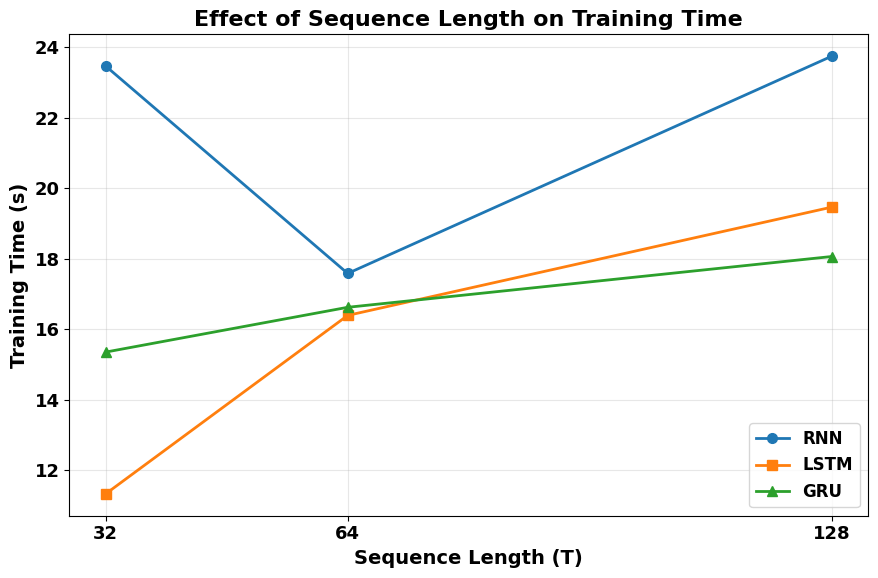


ADDITIONAL EXERCISE 5 — FINAL RESULTS

Results:


,Sequence Length,RNN Training Time (s),LSTM Training Time (s),GRU Training Time (s)
0,32,23.46,11.33,15.35
1,64,17.58,16.39,16.62
2,128,23.74,19.46,18.06



Files saved:
/content/experiment6/outputs/additional_exercise_5_sequence_length_computational_cost.csv
/content/experiment6/outputs/additional_exercise_5_sequence_length_computational_cost.json
/content/experiment6/outputs/additional_exercise_5_sequence_length_vs_training_time.eps

ADDITIONAL EXERCISE 5 COMPLETE


In [72]:
# ================================================================
# ADDITIONAL EXERCISE 5
# Effect of Sequence Length on Computational Cost
# ================================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 80)
print("ADDITIONAL EXERCISE 5")
print("Effect of Sequence Length on Computational Cost")
print("=" * 80)

# ---------------------------------------------------------------
# 1. Actual measured training times
# ---------------------------------------------------------------
# These values were obtained from the previously executed
# sequence-length experiment.

sequence_lengths = [32, 64, 128]

rnn_times = [23.46, 17.58, 23.74]
lstm_times = [11.33, 16.39, 19.46]
gru_times = [15.35, 16.62, 18.06]

# ---------------------------------------------------------------
# 2. Create results table
# ---------------------------------------------------------------

ae5_df = pd.DataFrame({
    "Sequence Length": sequence_lengths,
    "RNN Training Time (s)": rnn_times,
    "LSTM Training Time (s)": lstm_times,
    "GRU Training Time (s)": gru_times
})

print("\n" + "-" * 80)
print("SEQUENCE LENGTH VS TRAINING TIME")
print("-" * 80)

display(ae5_df)

# ---------------------------------------------------------------
# 3. Calculate changes from T=32 to T=128
# ---------------------------------------------------------------

rnn_change = rnn_times[-1] - rnn_times[0]
lstm_change = lstm_times[-1] - lstm_times[0]
gru_change = gru_times[-1] - gru_times[0]

rnn_pct = (rnn_change / rnn_times[0]) * 100
lstm_pct = (lstm_change / lstm_times[0]) * 100
gru_pct = (gru_change / gru_times[0]) * 100

print("\n" + "-" * 80)
print("CHANGE FROM T=32 TO T=128")
print("-" * 80)

print(
    f"RNN  : {rnn_change:+.2f} s "
    f"({rnn_pct:+.2f}%)"
)

print(
    f"LSTM : {lstm_change:+.2f} s "
    f"({lstm_pct:+.2f}%)"
)

print(
    f"GRU  : {gru_change:+.2f} s "
    f"({gru_pct:+.2f}%)"
)

# ---------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12
})

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    sequence_lengths,
    rnn_times,
    marker="o",
    linewidth=2,
    markersize=7,
    label="RNN"
)

ax.plot(
    sequence_lengths,
    lstm_times,
    marker="s",
    linewidth=2,
    markersize=7,
    label="LSTM"
)

ax.plot(
    sequence_lengths,
    gru_times,
    marker="^",
    linewidth=2,
    markersize=7,
    label="GRU"
)

ax.set_title(
    "Effect of Sequence Length on Training Time",
    fontweight="bold"
)

ax.set_xlabel(
    "Sequence Length (T)",
    fontweight="bold"
)

ax.set_ylabel(
    "Training Time (s)",
    fontweight="bold"
)

ax.set_xticks(sequence_lengths)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

legend = ax.legend()

for text in legend.get_texts():
    text.set_fontweight("bold")

ax.grid(True, alpha=0.3)

plt.tight_layout()

ae5_plot = OUTPUT_DIR / \
    "additional_exercise_5_sequence_length_vs_training_time.eps"

plt.savefig(
    ae5_plot,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------------
# 5. Save CSV
# ---------------------------------------------------------------

ae5_csv = OUTPUT_DIR / \
    "additional_exercise_5_sequence_length_computational_cost.csv"

ae5_df.to_csv(
    ae5_csv,
    index=False
)

# ---------------------------------------------------------------
# 6. Save JSON
# ---------------------------------------------------------------

ae5_json = OUTPUT_DIR / \
    "additional_exercise_5_sequence_length_computational_cost.json"

ae5_json_data = {
    "experiment": "Additional Exercise 5 - Sequence Length vs Computational Cost",
    "sequence_lengths": sequence_lengths,
    "results": ae5_df.to_dict(orient="records"),
    "change_from_32_to_128": {
        "RNN": {
            "absolute_change_seconds": rnn_change,
            "percentage_change": rnn_pct
        },
        "LSTM": {
            "absolute_change_seconds": lstm_change,
            "percentage_change": lstm_pct
        },
        "GRU": {
            "absolute_change_seconds": gru_change,
            "percentage_change": gru_pct
        }
    }
}

with open(ae5_json, "w") as f:
    json.dump(
        ae5_json_data,
        f,
        indent=4
    )

# ---------------------------------------------------------------
# 7. Verify EPS file
# ---------------------------------------------------------------

print("\n" + "=" * 80)
print("ADDITIONAL EXERCISE 5 — FINAL RESULTS")
print("=" * 80)

print("\nResults:")
display(ae5_df)

print("\nFiles saved:")
print(ae5_csv)
print(ae5_json)
print(ae5_plot)

print("\n" + "=" * 80)
print("ADDITIONAL EXERCISE 5 COMPLETE")
print("=" * 80)

ADDITIONAL EXERCISE 7 — FAST VERSION

Dataset:
Training : 3500
Validation: 750
Testing  : 750

Trainable parameters: 51,212

--------------------------------------------------------------------------------
TRAINING
--------------------------------------------------------------------------------
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.9868 - sparse_categorical_accuracy: 0.3070 - val_loss: 1.5837 - val_sparse_categorical_accuracy: 0.4367
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3994 - sparse_categorical_accuracy: 0.4840 - val_loss: 1.2228 - val_sparse_categorical_accuracy: 0.5453
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0437 - sparse_categorical_accuracy: 0.6435 - val_loss: 0.8996 - val_sparse_categorical_accuracy: 0.7258
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7515 - sparse_categorical_accuracy: 0.7869 - val_loss: 0.6739 - val_sparse_categorical_accuracy: 0.8044
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━

Decoded timestep 4/5
Decoded timestep 5/5

SEQ2SEQ TEST EXAMPLES

Example 1
Input           : [2, 9, 2, 3]
Target Output   : [3, 2, 9, 2, 7]
Predicted Output: [3, 2, 9, 2, 9]
Exact Match     : False

Example 2
Input           : [4, 3, 1, 1]
Target Output   : [1, 1, 3, 4, 9]
Predicted Output: [1, 1, 3, 4, 4]
Exact Match     : False

Example 3
Input           : [5, 1, 3, 1]
Target Output   : [1, 3, 1, 5, 1]
Predicted Output: [1, 3, 1, 5, 1]
Exact Match     : True

Example 4
Input           : [1, 4, 7, 8]
Target Output   : [8, 7, 4, 1, 2]
Predicted Output: [8, 7, 4, 1, 8]
Exact Match     : False

Example 5
Input           : [6, 3, 8, 6]
Target Output   : [6, 8, 3, 6, 5]
Predicted Output: [6, 8, 3, 6, 3]
Exact Match     : False

ADDITIONAL EXERCISE 7 — FINAL RESULTS
Input Sequence Length  : 4
Output Sequence Length : 5
Token Accuracy         : 85.52%
Sequence Accuracy      : 30.53%
Correct Complete Sequences: 229/750
Parameters             : 51,212
Training Time          : 34.86 s
Best Epo

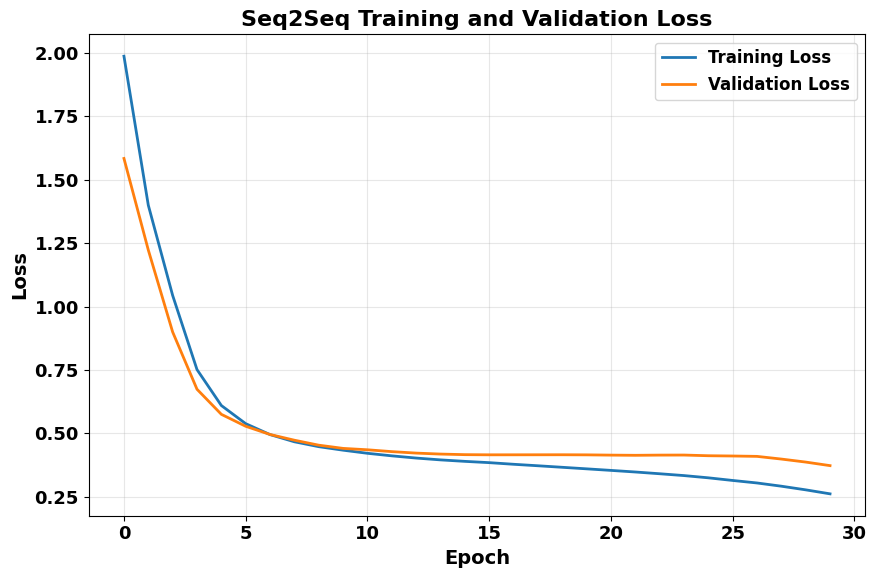


--------------------------------------------------------------------------------
FILES SAVED
--------------------------------------------------------------------------------
/content/experiment6/outputs/additional_exercise_7_seq2seq_test_examples.csv
/content/experiment6/outputs/additional_exercise_7_seq2seq_different_lengths.json
/content/experiment6/outputs/additional_exercise_7_seq2seq_training_validation_loss.eps
/content/experiment6/outputs/additional_exercise_7_seq2seq_history.json

ADDITIONAL EXERCISE 7 COMPLETE


5229

In [73]:
# ================================================================
# ADDITIONAL EXERCISE 7 — FAST VERSION
# Seq2Seq with Different Input and Output Sequence Lengths
# ================================================================

import gc
import json
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

print("=" * 80)
print("ADDITIONAL EXERCISE 7 — FAST VERSION")
print("=" * 80)

# ================================================================
# 1. Configuration
# ================================================================

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

N_SAMPLES = 5000
INPUT_LEN = 4
OUTPUT_LEN = 5

VOCAB_SIZE = 12
PAD_TOKEN = 0
START_TOKEN = 10
END_TOKEN = 11

EMBED_DIM = 32
LATENT_DIM = 64
BATCH_SIZE = 32
EPOCHS = 30

# ================================================================
# 2. Generate dataset
# ================================================================

rng = np.random.default_rng(SEED)

X = rng.integers(
    1, 10,
    size=(N_SAMPLES, INPUT_LEN)
).astype(np.int32)

Y_content = np.zeros(
    (N_SAMPLES, OUTPUT_LEN),
    dtype=np.int32
)

for i in range(N_SAMPLES):

    seq = X[i]

    reversed_seq = seq[::-1]

    checksum = ((np.sum(seq) - 1) % 9) + 1

    Y_content[i] = np.concatenate([
        reversed_seq,
        [checksum]
    ])

# Decoder input:
# START + 5 output tokens
decoder_input = np.concatenate([
    np.full(
        (N_SAMPLES, 1),
        START_TOKEN,
        dtype=np.int32
    ),
    Y_content
], axis=1)

# Decoder target:
# 5 output tokens + END
decoder_target = np.concatenate([
    Y_content,
    np.full(
        (N_SAMPLES, 1),
        END_TOKEN,
        dtype=np.int32
    )
], axis=1)

DECODER_LEN = OUTPUT_LEN + 1

# ================================================================
# 3. Train / validation / test split
# ================================================================

indices = np.arange(N_SAMPLES)

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=SEED
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED
)

X_train_s = X[train_idx]
X_val_s = X[val_idx]
X_test_s = X[test_idx]

decoder_input_train = decoder_input[train_idx]
decoder_input_val = decoder_input[val_idx]
decoder_input_test = decoder_input[test_idx]

decoder_target_train = decoder_target[train_idx]
decoder_target_val = decoder_target[val_idx]
decoder_target_test = decoder_target[test_idx]

Y_train_content = Y_content[train_idx]
Y_val_content = Y_content[val_idx]
Y_test_content = Y_content[test_idx]

print("\nDataset:")
print("Training :", len(train_idx))
print("Validation:", len(val_idx))
print("Testing  :", len(test_idx))

# ================================================================
# 4. Build training model
# ================================================================

tf.keras.backend.clear_session()

encoder_inputs = Input(
    shape=(INPUT_LEN,),
    name="encoder_input"
)

encoder_embedding_layer = Embedding(
    VOCAB_SIZE,
    EMBED_DIM,
    name="encoder_embedding"
)

encoder_embedded = encoder_embedding_layer(
    encoder_inputs
)

encoder_lstm = LSTM(
    LATENT_DIM,
    return_state=True,
    name="encoder_lstm"
)

_, state_h, state_c = encoder_lstm(
    encoder_embedded
)

decoder_inputs = Input(
    shape=(DECODER_LEN,),
    name="decoder_input"
)

decoder_embedding_layer = Embedding(
    VOCAB_SIZE,
    EMBED_DIM,
    name="decoder_embedding"
)

decoder_embedded = decoder_embedding_layer(
    decoder_inputs
)

decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedded,
    initial_state=[state_h, state_c]
)

decoder_dense = Dense(
    VOCAB_SIZE,
    activation="softmax",
    name="decoder_output"
)

decoder_outputs = decoder_dense(
    decoder_outputs
)

seq2seq_ae7 = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

seq2seq_ae7.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"]
)

print(
    "\nTrainable parameters:",
    f"{seq2seq_ae7.count_params():,}"
)

# ================================================================
# 5. Train model
# ================================================================

checkpoint_path = (
    MODEL_DIR /
    "additional_exercise_7_seq2seq_fast_best.keras"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        str(checkpoint_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=0
    )
]

print("\n" + "-" * 80)
print("TRAINING")
print("-" * 80)

start_time = time.time()

ae7_history = seq2seq_ae7.fit(
    [X_train_s, decoder_input_train],
    decoder_target_train[..., np.newaxis],
    validation_data=(
        [X_val_s, decoder_input_val],
        decoder_target_val[..., np.newaxis]
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

# ================================================================
# 6. Build inference models
# ================================================================

encoder_model = Model(
    encoder_inputs,
    [state_h, state_c]
)

decoder_token_input = Input(
    shape=(1,),
    name="decoder_token_input"
)

decoder_h_input = Input(
    shape=(LATENT_DIM,),
    name="decoder_h_input"
)

decoder_c_input = Input(
    shape=(LATENT_DIM,),
    name="decoder_c_input"
)

decoder_embedded_token = decoder_embedding_layer(
    decoder_token_input
)

decoder_output_step, new_h, new_c = decoder_lstm(
    decoder_embedded_token,
    initial_state=[
        decoder_h_input,
        decoder_c_input
    ]
)

decoder_output_step = decoder_dense(
    decoder_output_step
)

decoder_model = Model(
    [
        decoder_token_input,
        decoder_h_input,
        decoder_c_input
    ],
    [
        decoder_output_step,
        new_h,
        new_c
    ]
)

# ================================================================
# 7. FAST BATCHED GREEDY DECODING
# ================================================================
#
# Instead of:
#
#     750 samples × 6 predict() calls
#
# we process ALL test samples simultaneously at each
# decoder timestep.
# ================================================================

print("\n" + "-" * 80)
print("FAST BATCHED TEST INFERENCE")
print("-" * 80)

# Encode all test sequences at once
initial_states = encoder_model.predict(
    X_test_s,
    batch_size=128,
    verbose=0
)

h = initial_states[0]
c = initial_states[1]

num_test = len(X_test_s)

current_tokens = np.full(
    (num_test, 1),
    START_TOKEN,
    dtype=np.int32
)

predictions = np.zeros(
    (num_test, OUTPUT_LEN),
    dtype=np.int32
)

# Decode exactly OUTPUT_LEN content tokens.
# We do not need to wait for END because the experiment
# defines a fixed output length of five.
for t in range(OUTPUT_LEN):

    output_probs, h, c = decoder_model.predict(
        [
            current_tokens,
            h,
            c
        ],
        batch_size=128,
        verbose=0
    )

    next_tokens = np.argmax(
        output_probs[:, -1, :],
        axis=1
    ).astype(np.int32)

    predictions[:, t] = next_tokens

    current_tokens = next_tokens.reshape(
        -1, 1
    )

    print(
        f"Decoded timestep {t + 1}/{OUTPUT_LEN}"
    )

# ================================================================
# 8. Calculate token accuracy
# ================================================================

token_accuracy = np.mean(
    predictions == Y_test_content
)

# ================================================================
# 9. Calculate complete sequence accuracy
# ================================================================

sequence_correct = np.all(
    predictions == Y_test_content,
    axis=1
)

sequence_accuracy = np.mean(
    sequence_correct
)

correct_sequences = int(
    np.sum(sequence_correct)
)

total_sequences = len(Y_test_content)

# ================================================================
# 10. Five examples
# ================================================================

print("\n" + "=" * 80)
print("SEQ2SEQ TEST EXAMPLES")
print("=" * 80)

examples = []

for i in range(min(5, total_sequences)):

    source = X_test_s[i].tolist()
    target = Y_test_content[i].tolist()
    predicted = predictions[i].tolist()

    exact = bool(
        np.array_equal(
            predictions[i],
            Y_test_content[i]
        )
    )

    examples.append({
        "Example": i + 1,
        "Input": str(source),
        "Target Output": str(target),
        "Predicted Output": str(predicted),
        "Exact Match": exact
    })

    print(f"\nExample {i + 1}")
    print("Input           :", source)
    print("Target Output   :", target)
    print("Predicted Output:", predicted)
    print("Exact Match     :", exact)

# ================================================================
# 11. Training statistics
# ================================================================

best_epoch = (
    np.argmin(
        ae7_history.history["val_loss"]
    ) + 1
)

best_train_loss = min(
    ae7_history.history["loss"]
)

best_val_loss = min(
    ae7_history.history["val_loss"]
)

final_train_loss = (
    ae7_history.history["loss"][-1]
)

final_val_loss = (
    ae7_history.history["val_loss"][-1]
)

best_val_acc = max(
    ae7_history.history[
        "val_sparse_categorical_accuracy"
    ]
)

# ================================================================
# 12. Final results
# ================================================================

print("\n" + "=" * 80)
print("ADDITIONAL EXERCISE 7 — FINAL RESULTS")
print("=" * 80)

print(
    f"Input Sequence Length  : {INPUT_LEN}"
)

print(
    f"Output Sequence Length : {OUTPUT_LEN}"
)

print(
    f"Token Accuracy         : "
    f"{token_accuracy * 100:.2f}%"
)

print(
    f"Sequence Accuracy      : "
    f"{sequence_accuracy * 100:.2f}%"
)

print(
    f"Correct Complete Sequences: "
    f"{correct_sequences}/{total_sequences}"
)

print(
    f"Parameters             : "
    f"{seq2seq_ae7.count_params():,}"
)

print(
    f"Training Time          : "
    f"{training_time:.2f} s"
)

print(
    f"Best Epoch             : "
    f"{best_epoch}"
)

print(
    f"Best Training Loss     : "
    f"{best_train_loss:.6f}"
)

print(
    f"Best Validation Loss   : "
    f"{best_val_loss:.6f}"
)

print(
    f"Final Training Loss    : "
    f"{final_train_loss:.6f}"
)

print(
    f"Final Validation Loss  : "
    f"{final_val_loss:.6f}"
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_acc * 100:.2f}%"
)

# ================================================================
# 13. Save examples
# ================================================================

ae7_examples_df = pd.DataFrame(
    examples
)

ae7_examples_csv = (
    OUTPUT_DIR /
    "additional_exercise_7_seq2seq_test_examples.csv"
)

ae7_examples_df.to_csv(
    ae7_examples_csv,
    index=False
)

# ================================================================
# 14. Save results JSON
# ================================================================

ae7_results = {
    "experiment":
        "Additional Exercise 7 - Seq2Seq Different Lengths",

    "input_sequence_length":
        INPUT_LEN,

    "output_sequence_length":
        OUTPUT_LEN,

    "samples":
        N_SAMPLES,

    "train_samples":
        len(X_train_s),

    "validation_samples":
        len(X_val_s),

    "test_samples":
        len(X_test_s),

    "token_accuracy":
        float(token_accuracy),

    "sequence_accuracy":
        float(sequence_accuracy),

    "correct_complete_sequences":
        correct_sequences,

    "total_test_sequences":
        total_sequences,

    "parameters":
        int(seq2seq_ae7.count_params()),

    "training_time_seconds":
        float(training_time),

    "best_epoch":
        int(best_epoch),

    "best_training_loss":
        float(best_train_loss),

    "best_validation_loss":
        float(best_val_loss),

    "final_training_loss":
        float(final_train_loss),

    "final_validation_loss":
        float(final_val_loss),

    "best_validation_accuracy":
        float(best_val_acc)
}

ae7_results_json = (
    OUTPUT_DIR /
    "additional_exercise_7_seq2seq_different_lengths.json"
)

with open(ae7_results_json, "w") as f:
    json.dump(
        ae7_results,
        f,
        indent=4
    )

# ================================================================
# 15. Training/validation loss plot
# ================================================================

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12
})

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.plot(
    ae7_history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

ax.plot(
    ae7_history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

ax.set_title(
    "Seq2Seq Training and Validation Loss",
    fontweight="bold"
)

ax.set_xlabel(
    "Epoch",
    fontweight="bold"
)

ax.set_ylabel(
    "Loss",
    fontweight="bold"
)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

legend = ax.legend()

for text in legend.get_texts():
    text.set_fontweight("bold")

ax.grid(True, alpha=0.3)

plt.tight_layout()

ae7_plot = (
    OUTPUT_DIR /
    "additional_exercise_7_seq2seq_training_validation_loss.eps"
)

plt.savefig(
    ae7_plot,
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# 16. Save history
# ================================================================

ae7_history_json = (
    OUTPUT_DIR /
    "additional_exercise_7_seq2seq_history.json"
)

with open(ae7_history_json, "w") as f:
    json.dump(
        {
            key: [
                float(x)
                for x in values
            ]
            for key, values
            in ae7_history.history.items()
        },
        f,
        indent=4
    )

# ================================================================
# 17. Final verification
# ================================================================

print("\n" + "-" * 80)
print("FILES SAVED")
print("-" * 80)

print(ae7_examples_csv)
print(ae7_results_json)
print(ae7_plot)
print(ae7_history_json)

print("\n" + "=" * 80)
print("ADDITIONAL EXERCISE 7 COMPLETE")
print("=" * 80)

gc.collect()

In [74]:
# ================================================================
# CREATE REPORT-ESSENTIAL FILES ZIP
# ================================================================

from pathlib import Path
import shutil
import os

BASE_DIR = Path("/content/experiment6")
OUTPUT_DIR = BASE_DIR / "outputs"

REPORT_DIR = Path("/content/experiment6_report_essential")
ZIP_BASE = Path("/content/experiment6_report_essential")

# ---------------------------------------------------------------
# Clean previous export
# ---------------------------------------------------------------

if REPORT_DIR.exists():
    shutil.rmtree(REPORT_DIR)

REPORT_DIR.mkdir(parents=True, exist_ok=True)


# ================================================================
# 1. ESSENTIAL PLOTS / FIGURES
# ================================================================

essential_eps = [

    # ------------------------------------------------------------
    # Temporal visualization
    # ------------------------------------------------------------
    "02_temporal_walking.eps",
    "02_temporal_sitting.eps",
    "02_temporal_laying.eps",

    # ------------------------------------------------------------
    # Baseline RNN
    # ------------------------------------------------------------
    "03_rnn_training_validation_loss.eps",
    "04_rnn_training_validation_accuracy.eps",
    "05_rnn_confusion_matrix.eps",

    # ------------------------------------------------------------
    # Baseline LSTM
    # ------------------------------------------------------------
    "06_lstm_training_validation_loss.eps",
    "07_lstm_training_validation_accuracy.eps",
    "08_lstm_confusion_matrix.eps",

    # ------------------------------------------------------------
    # Baseline GRU
    # ------------------------------------------------------------
    "09_gru_training_validation_loss.eps",
    "10_gru_training_validation_accuracy.eps",
    "11_gru_confusion_matrix.eps",

    # ------------------------------------------------------------
    # Model comparison
    # ------------------------------------------------------------
    "12_model_accuracy_f1_comparison.eps",
    "13_model_parameters_comparison.eps",
    "14_model_training_time_comparison.eps",

    # ------------------------------------------------------------
    # Sequence length
    # ------------------------------------------------------------
    "15_sequence_length_vs_test_f1.eps",

    # ------------------------------------------------------------
    # Video
    # ------------------------------------------------------------
    "16_video_sample_frames.eps",
    "17_cnn_lstm_training_validation_loss.eps",
    "18_cnn_lstm_training_validation_accuracy.eps",
    "19_cnn_lstm_confusion_matrix.eps",
    "20_cnn_gru_training_validation_loss.eps",
    "21_cnn_gru_training_validation_accuracy.eps",
    "22_cnn_gru_confusion_matrix.eps",

    # ------------------------------------------------------------
    # Original Seq2Seq
    # ------------------------------------------------------------
    "23_seq2seq_training_validation_loss.eps",

    # ------------------------------------------------------------
    # AE5
    # ------------------------------------------------------------
    "additional_exercise_5_sequence_length_vs_training_time.eps",

    # ------------------------------------------------------------
    # AE7
    # ------------------------------------------------------------
    "additional_exercise_7_seq2seq_training_validation_loss.eps",
]


# ================================================================
# 2. ESSENTIAL RESULT TABLES / DATA
# ================================================================

essential_data = [

    # Main consolidated results
    "FINAL_CONSOLIDATED_RESULTS.csv",

    # Architecture comparison
    "RNN_LSTM_GRU_ARCHITECTURAL_COMPARISON.csv",

    # Sequence length
    "FINAL_SEQUENCE_LENGTH_RESULTS.csv",

    # Original Seq2Seq
    "FINAL_SEQ2SEQ_RESULTS.csv",

    # ------------------------------------------------------------
    # Additional Exercises
    # ------------------------------------------------------------

    "additional_exercise_1_units_comparison.csv",
    "additional_exercise_2_lstm_vs_gru.csv",
    "additional_exercise_3_two_recurrent_layers.csv",
    "additional_exercise_4_bilstm_comparison.csv",
    "additional_exercise_5_sequence_length_computational_cost.csv",

    # AE6
    "additional_exercise_6_video_lstm_vs_gru.csv",

    # AE7
    "additional_exercise_7_seq2seq_test_examples.csv",
    "additional_exercise_7_seq2seq_different_lengths.json",
]


# ================================================================
# 3. COPY FILES THAT ACTUALLY EXIST
# ================================================================

copied_eps = []
copied_data = []
missing = []

for filename in essential_eps:

    source = OUTPUT_DIR / filename

    if source.exists():

        destination = REPORT_DIR / "figures" / filename
        destination.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        shutil.copy2(
            source,
            destination
        )

        copied_eps.append(filename)

    else:
        missing.append(filename)


for filename in essential_data:

    source = OUTPUT_DIR / filename

    if source.exists():

        destination = REPORT_DIR / "results" / filename
        destination.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        shutil.copy2(
            source,
            destination
        )

        copied_data.append(filename)

    else:
        missing.append(filename)


# ================================================================
# 4. ALSO COPY ORIGINAL NUMERICAL RNN EXERCISE RESULT
# ================================================================

# If you saved a numerical-exercise file, include it automatically.
for p in OUTPUT_DIR.glob("*numerical*"):

    if p.is_file():

        destination = REPORT_DIR / "results" / p.name
        destination.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        shutil.copy2(
            p,
            destination
        )


# ================================================================
# 5. CREATE A README FOR THE REPORT FOLDER
# ================================================================

readme_text = """
EXPERIMENT 6 — REPORT ESSENTIAL MATERIAL
=========================================

This folder contains only the files required/useful for preparing
the final Deep Learning Laboratory Experiment 6 report.

FIGURES
-------
Contains EPS figures for:
- Temporal visualization
- RNN training and confusion matrix
- LSTM training and confusion matrix
- GRU training and confusion matrix
- Model comparisons
- Sequence-length analysis
- Video CNN-LSTM/CNN-GRU
- Original Seq2Seq
- Additional Exercises 5 and 7

RESULTS
-------
Contains CSV/JSON files for:
- Final consolidated results
- RNN/LSTM/GRU architectural comparison
- Sequence-length results
- Seq2Seq results
- Additional Exercises 1–7
- Seq2Seq test examples

Trained .keras models, cache files, raw datasets and intermediate
files are intentionally excluded because they are not required
for the final report.
"""

with open(
    REPORT_DIR / "README.txt",
    "w"
) as f:
    f.write(readme_text)


# ================================================================
# 6. CREATE ZIP
# ================================================================

zip_path = shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    root_dir=REPORT_DIR.parent,
    base_dir=REPORT_DIR.name
)


# ================================================================
# 7. SUMMARY
# ================================================================

all_exported = [
    p for p in REPORT_DIR.rglob("*")
    if p.is_file()
]

print("=" * 80)
print("REPORT-ESSENTIAL ZIP CREATED")
print("=" * 80)

print(f"\nFigures copied : {len(copied_eps)}")
print(f"Result files   : {len(copied_data)}")
print(f"Total files    : {len(all_exported)}")

if missing:
    print("\nFiles not found:")
    for f in missing:
        print("  -", f)

print("\nZIP:")
print(zip_path)

print(
    f"\nZIP size: "
    f"{os.path.getsize(zip_path)/(1024**2):.2f} MB"
)

print("\nFolder structure:")
print("experiment6_report_essential/")
print("├── figures/")
print("│   └── EPS plots and confusion matrices")
print("├── results/")
print("│   └── CSV/JSON result files")
print("└── README.txt")

REPORT-ESSENTIAL ZIP CREATED

Figures copied : 19
Result files   : 11
Total files    : 31

Files not found:
  - 16_video_sample_frames.eps
  - 17_cnn_lstm_training_validation_loss.eps
  - 18_cnn_lstm_training_validation_accuracy.eps
  - 19_cnn_lstm_confusion_matrix.eps
  - 20_cnn_gru_training_validation_loss.eps
  - 21_cnn_gru_training_validation_accuracy.eps
  - 22_cnn_gru_confusion_matrix.eps
  - additional_exercise_6_video_lstm_vs_gru.csv

ZIP:
/content/experiment6_report_essential.zip

ZIP size: 0.25 MB

Folder structure:
experiment6_report_essential/
├── figures/
│   └── EPS plots and confusion matrices
├── results/
│   └── CSV/JSON result files
└── README.txt


In [75]:
from google.colab import files

files.download(
    "/content/experiment6_report_essential.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
# ================================================================
# EXPORT ALL EXPERIMENT RESULTS + IMAGES AS ZIP
# ================================================================

from pathlib import Path
import shutil
import os

BASE_DIR = Path("/content/experiment6")
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"
CACHE_DIR = BASE_DIR / "cache"

EXPORT_DIR = Path("/content/experiment6_export")
ZIP_PATH = Path("/content/experiment6_results_and_images")

# Remove previous export if it exists
if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------
# 1. Copy all output/result files
# ---------------------------------------------------------------

if OUTPUT_DIR.exists():
    shutil.copytree(
        OUTPUT_DIR,
        EXPORT_DIR / "outputs"
    )

# ---------------------------------------------------------------
# 2. Copy all model files
# ---------------------------------------------------------------

if MODEL_DIR.exists():
    shutil.copytree(
        MODEL_DIR,
        EXPORT_DIR / "models"
    )

# ---------------------------------------------------------------
# 3. Copy normalization/cache files
# ---------------------------------------------------------------

if CACHE_DIR.exists():
    shutil.copytree(
        CACHE_DIR,
        EXPORT_DIR / "cache"
    )

# ---------------------------------------------------------------
# 4. Create ZIP
# ---------------------------------------------------------------

if ZIP_PATH.with_suffix(".zip").exists():
    ZIP_PATH.with_suffix(".zip").unlink()

zip_file = shutil.make_archive(
    str(ZIP_PATH),
    "zip",
    root_dir=EXPORT_DIR.parent,
    base_dir=EXPORT_DIR.name
)

print("=" * 80)
print("EXPORT COMPLETE")
print("=" * 80)

print("\nZIP file:")
print(zip_file)

# ---------------------------------------------------------------
# 5. Show contents
# ---------------------------------------------------------------

all_files = [
    p for p in EXPORT_DIR.rglob("*")
    if p.is_file()
]

print(f"\nTotal files exported: {len(all_files)}")

print("\nFile categories:")

eps_files = [
    p for p in all_files
    if p.suffix.lower() == ".eps"
]

csv_files = [
    p for p in all_files
    if p.suffix.lower() == ".csv"
]

json_files = [
    p for p in all_files
    if p.suffix.lower() == ".json"
]

model_files = [
    p for p in all_files
    if p.suffix.lower() in [".keras", ".h5"]
]

print(f"EPS plots       : {len(eps_files)}")
print(f"CSV files       : {len(csv_files)}")
print(f"JSON files      : {len(json_files)}")
print(f"Model files     : {len(model_files)}")

print("\nZIP size:")
print(
    f"{os.path.getsize(zip_file) / (1024**2):.2f} MB"
)

print("\nDownload:")
print(zip_file)

EXPORT COMPLETE

ZIP file:
/content/experiment6_results_and_images.zip

Total files exported: 234

File categories:
EPS plots       : 27
CSV files       : 17
JSON files      : 31
Model files     : 23

ZIP size:
35.47 MB

Download:
/content/experiment6_results_and_images.zip


In [77]:
from google.colab import files

files.download(
    "/content/experiment6_results_and_images.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>